# Amazon Reviews EDA - Consumer Electronics
## Top-down funnel: Brand -> Device/Accessory -> Model -> Reviews

**Dataset:** UCSD Amazon Reviews 2023 (McAuley) — `Electronics.jsonl` + `meta_Electronics.jsonl`

Same four-stage funnel as the phones notebook, adapted for tablets and laptops.

```
ALL METADATA
    │
    ▼  Stage 1 — Brand capture (broad keyword)
    ├─ Apple   : ipad / macbook
    ├─ Amazon  : fire hd / fire tablet / kindle
    ├─ Microsoft : surface
    ├─ Samsung : galaxy tab
    ├─ Lenovo  : lenovo (tab / ideapad / thinkpad / yoga)
    ├─ HP      : hp (pavilion / envy / spectre / chromebook)
    ├─ Dell    : dell (inspiron / xps / latitude)
    └─ ASUS / Acer / Google Chromebook
         │
         ▼  Stage 2 — Device / Accessory split
         ├─ Confirmed devices (tablet or laptop)
         └─ Accessories  (discarded, logged)
              │
              ▼  Stage 3 — Model classification + landscape
              ├─ iPad Pro / Air / mini / standard generations
              ├─ MacBook Air / Pro M1 / M2 / Intel
              ├─ Fire HD 10 / 8 / 7 generations
              ├─ Surface Pro / Go / Laptop generations
              └─ Galaxy Tab S / A series …
                   │
                   ▼  Stage 4 — Thesis event selection
                   └─ candidate_asins auto-populated → review loader → EDA
```
**Product type rationale (Chitturi et al. 2007/2008):**
- **Tablets -> Hedonic** (Apple iPad) or **Utilitarian** (Amazon Fire, Android tabs)
- **Laptops -> Utilitarian** across all brands (task-completion, productivity framing)
- iPad is classified hedonic: design-premium, ecosystem lock-in, lifestyle marketing
- Fire HD is classified utilitarian: Amazon's explicit value/function positioning


## Setup

In [39]:
import json, re
from collections import defaultdict, Counter
from datetime import timedelta
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from tqdm import tqdm


In [40]:
# Palette — consistent with rest of thesis EDA
LIGHT_BLUE   = '#8fd7d7';  MED_BLUE   = '#00b0be'
LIGHT_PINK   = '#ff8ca1';  MED_PINK   = '#f45f74'
LIGHT_GREEN  = '#bdd373';  MED_GREEN  = '#98c127'
LIGHT_ORANGE = '#ffcd8e';  MED_ORANGE = '#ffb255'
PALETTE = [MED_BLUE, MED_PINK, MED_GREEN, MED_ORANGE,
           LIGHT_BLUE, LIGHT_PINK, LIGHT_GREEN, LIGHT_ORANGE]

BRAND_COLOR = {
    'Apple':     MED_PINK,
    'Amazon':    MED_ORANGE,
    'Microsoft': MED_BLUE,
    'Samsung':   '#4a90d9',
    'Lenovo':    MED_GREEN,
    'HP':        '#8e44ad',
    'Dell':      '#2c3e50',
    'ASUS':      '#16a085',
    'Acer':      '#27ae60',
    'Google':    '#e67e22',
}
BRAND_LIGHT = {
    'Apple':     LIGHT_PINK,
    'Amazon':    LIGHT_ORANGE,
    'Microsoft': LIGHT_BLUE,
    'Samsung':   '#a8c8f0',
    'Lenovo':    LIGHT_GREEN,
    'HP':        '#c39bd3',
    'Dell':      '#95a5a6',
    'ASUS':      '#76d7c4',
    'Acer':      '#a9dfbf',
    'Google':    LIGHT_ORANGE,
}
TYPE_COLOR  = {'hedonic': MED_PINK,   'utilitarian': MED_BLUE}
TYPE_LIGHT  = {'hedonic': LIGHT_PINK, 'utilitarian': LIGHT_BLUE}
TYPE_BG     = {'hedonic': '#fdf5f6',  'utilitarian': '#f0f8ff'}
TYPE_TITLE  = {'hedonic': '#7d1e2a',  'utilitarian': '#1a4a6b'}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#eeeeee',
    'grid.linewidth':    0.8,
    'axes.facecolor':    '#fafafa',
    'figure.facecolor':  'white',
})
print('Palette loaded.')


Palette loaded.


In [41]:
BASE_DIR     = Path(r'C:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\Post-launch Amazon reviews')
META_FILE    = BASE_DIR / 'Meta'        / 'meta_Electronics.jsonl'
REVIEWS_FILE = BASE_DIR / 'Electronics' / 'Electronics.jsonl'

for f in [META_FILE, REVIEWS_FILE]:
    ok   = f.exists()
    sym  = chr(10003) if ok else chr(10007)
    note = f'{f.stat().st_size/1e9:.2f} GB' if ok else 'NOT FOUND'
    print(f'{sym}  {f.name:<55} {note}')


✓  meta_Electronics.jsonl                                  5.25 GB
✓  Electronics.jsonl                                       22.62 GB


## Stage 1 - Brand-level capture

Broad keyword scan across all metadata records.
No model specificity yet — pull everything in, sort downstream.

| Brand | Keyword | Captures |
|---|---|---|
| Apple | `ipad` or `macbook` | All iPad + MacBook lines |
| Amazon | `fire hd` or `fire tablet` | Fire HD 10 / 8 / 7 + Fire 7 |
| Microsoft | `surface` | Surface Pro / Go / Laptop / Book |
| Samsung | `galaxy tab` | Galaxy Tab S / A / E series |
| Lenovo | `lenovo` + device keyword | IdeaPad / ThinkPad / Yoga / Tab |
| HP | `hp` + device keyword | Pavilion / Envy / Spectre / Chromebook |
| Dell | `dell` + device keyword | Inspiron / XPS / Latitude |
| ASUS | `asus` | ZenBook / VivoBook / ROG |
| Acer | `acer` | Aspire / Swift / Chromebook |
| Google | `chromebook` | Pixelbook + OEM Chromebooks |


In [42]:
BRAND_RE = {
    'Apple':     re.compile(r'\b(ipad|macbook)\b',                                   re.IGNORECASE),
    'Amazon':    re.compile(r'\bfire\s*(hd|tablet|7\b)',                              re.IGNORECASE),
    # Require 'microsoft surface' — blocks generic uses of 'surface'
    'Microsoft': re.compile(r'\bmicrosoft\s+surface\b',                              re.IGNORECASE),
    'Samsung':   re.compile(r'\bgalaxy\s+tab\b',                                     re.IGNORECASE),
    'Lenovo':    re.compile(r'\blenovo\b',                                            re.IGNORECASE),
    'HP':        re.compile(r'\b(hp|hewlett.packard)\s+\w*(book|pad|pavilion|envy|spectre|stream|elitebook|probook)', re.IGNORECASE),
    'Dell':      re.compile(r'\bdell\s+\w*(inspiron|xps|latitude|vostro|chromebook)', re.IGNORECASE),
    'ASUS':      re.compile(r'\basus\b',                                              re.IGNORECASE),
    'Acer':      re.compile(r'\bacer\b',                                              re.IGNORECASE),
    # Restrict Google to Pixelbook only — OEM Chromebooks belong to their own brand bucket
    # HP/Acer/Lenovo/Dell Chromebooks are already captured by those brand regexes
    'Google':    re.compile(r'\bpixelbook\b',                                         re.IGNORECASE),
}

brand_hits = {b: {} for b in BRAND_RE}
n_read = 0

with open(META_FILE, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc='Stage 1 — brand scan', unit='rec'):
        line = line.strip()
        if not line: continue
        n_read += 1
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        title = rec.get('title', '')
        if not title: continue
        for brand, pat in BRAND_RE.items():
            if pat.search(title):
                asin = rec.get('parent_asin', '')
                if asin and asin not in brand_hits[brand]:
                    brand_hits[brand][asin] = {
                        'title':         title,
                        'categories':    rec.get('categories', []),
                        'main_category': rec.get('main_category', ''),
                    }

print(f'Records read: {n_read:,}\n')
print(f'{"Brand":<12} {"ASINs":>10}')
print('-' * 24)
for brand, hits in brand_hits.items():
    print(f'{brand:<12} {len(hits):>10,}')
print(f'{"TOTAL":<12} {sum(len(v) for v in brand_hits.values()):>10,}')


Stage 1 — brand scan: 1610012rec [02:48, 9538.61rec/s] 

Records read: 1,610,012

Brand             ASINs
------------------------
Apple           141,085
Amazon           14,838
Microsoft         5,807
Samsung          24,100
Lenovo           27,522
HP               20,369
Dell             18,489
ASUS             20,347
Acer             15,419
Google              465
TOTAL           288,441


## Stage 2 - Device / Accessory split

For each brand-matched ASIN: **device** (tablet or laptop) or **accessory**?

| Priority | Signal | Decision |
|---|---|---|
| 1 | Accessory keyword in title | Accessory |
| 2 | Category in device whitelist | Device |
| 3 | Neither (ambiguous) | Ambiguous — inspected separately |

Accessory keywords are tuned for electronics: cases, chargers, keyboards, styluses,
stands, screen protectors, adapters, mice, docking stations.


In [43]:
DEVICE_CATS = {
    # Tablets
    'Tablets', 'Tablet Computers', 'iPad', 'Fire Tablets',
    'Android Tablets', 'Windows Tablets',
    # Laptops
    'Laptops', 'Notebook Computers', 'Laptop Computers',
    'Chromebooks', '2 in 1 Laptops', 'Ultrabooks',
    # Broad
    'Computers & Tablets', 'Traditional Laptops',
}

_ACCESSORY_PAT = (
    r'\b(case|cases|cover|covers|folio|sleeve|pouch'
    r'|screen\s*protector|tempered\s*glass|screen\s*guard|film'
    r'|charger|charging|cable|adapter|hub|dock|docking\s*station'
    r'|keyboard(?!\s+laptop|\s+computer)|mouse|stylus|pen|pencil'
    r'|stand|mount|holder|bracket|arm'
    r'|skin|decal|sticker|wrap'
    r'|bag|backpack|carrying'
    r'|memory|ram|ssd|hard\s*drive|storage\s*drive'
    r'|battery\s*pack|power\s*bank'
    r'|headphone|earbud|speaker'
    r'|compatible\s+with|for\s+ipad|for\s+macbook|for\s+surface'
    r'|for\s+fire\s*hd|for\s+galaxy\s+tab)\b'
)
ACCESSORY_RE = re.compile(_ACCESSORY_PAT, re.IGNORECASE)

device_asins    = {b: {} for b in BRAND_RE}
accessory_asins = {b: {} for b in BRAND_RE}
ambiguous_asins = {b: {} for b in BRAND_RE}
reject_reason   = Counter()

for brand, hits in brand_hits.items():
    for asin, info in hits.items():
        title = info['title']
        cats  = info['categories']
        is_accessory_kw = bool(ACCESSORY_RE.search(title))
        has_device_cat  = any(c in DEVICE_CATS for c in cats)

        if is_accessory_kw:
            accessory_asins[brand][asin] = title
            reject_reason['accessory keyword in title'] += 1
        elif has_device_cat:
            device_asins[brand][asin] = title
        else:
            ambiguous_asins[brand][asin] = title
            reject_reason['no device category (ambiguous)'] += 1

print('STAGE 2 SUMMARY')
print('=' * 68)
print(f'{"Brand":<12} {"Total":>7} {"Devices":>8} {"Ambiguous":>10} {"Accessories":>12} {"Device %":>9}')
print('-' * 62)
for brand in BRAND_RE:
    total = len(brand_hits[brand])
    dv    = len(device_asins[brand])
    amb   = len(ambiguous_asins[brand])
    ac    = len(accessory_asins[brand])
    print(f'{brand:<12} {total:>7,} {dv:>8,} {amb:>10,} {ac:>12,}  {100*dv/max(total,1):>7.1f}%')
print()
print('Rejection reasons:')
for reason, n in reject_reason.most_common():
    print(f'  {n:>7,}  {reason}')
print(f'\nConfirmed device ASINs : {sum(len(v) for v in device_asins.values()):,}')
print(f'Ambiguous ASINs        : {sum(len(v) for v in ambiguous_asins.values()):,}')


STAGE 2 SUMMARY
Brand          Total  Devices  Ambiguous  Accessories  Device %
--------------------------------------------------------------
Apple        141,085      673      6,318      134,094      0.5%
Amazon        14,838       18        520       14,300      0.1%
Microsoft      5,807      122        190        5,495      2.1%
Samsung       24,100      532        879       22,689      2.2%
Lenovo        27,522    1,613      3,240       22,669      5.9%
HP            20,369    1,160      4,831       14,378      5.7%
Dell          18,489    1,233      3,788       13,468      6.7%
ASUS          20,347    1,498      4,507       14,342      7.4%
Acer          15,419    1,485      3,074       10,860      9.6%
Google           465        1          5          459      0.2%

Rejection reasons:
  252,754  accessory keyword in title
   27,352  no device category (ambiguous)

Confirmed device ASINs : 8,335
Ambiguous ASINs        : 27,352


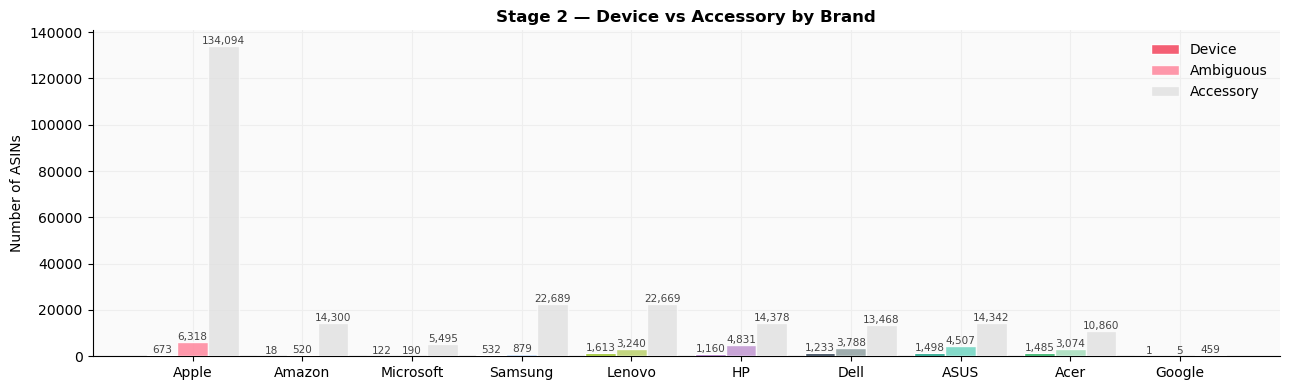

In [44]:
# Stage 2 bar chart
fig, ax = plt.subplots(figsize=(13, 4))
brands  = list(BRAND_RE.keys())
dv_cnt  = [len(device_asins[b])    for b in brands]
ac_cnt  = [len(accessory_asins[b]) for b in brands]
amb_cnt = [len(ambiguous_asins[b]) for b in brands]
x, w    = np.arange(len(brands)), 0.28
b1 = ax.bar(x-w,   dv_cnt,  width=w, color=[BRAND_COLOR[b] for b in brands],
            edgecolor='white', label='Device',    zorder=3)
b2 = ax.bar(x,     amb_cnt, width=w, color=[BRAND_LIGHT[b] for b in brands],
            edgecolor='white', label='Ambiguous', zorder=3, alpha=0.9)
b3 = ax.bar(x+w,   ac_cnt,  width=w, color='#ddd',
            edgecolor='white', label='Accessory', zorder=3, alpha=0.7)
for bar, v in zip(list(b1)+list(b2)+list(b3), dv_cnt+amb_cnt+ac_cnt):
    if v > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{v:,}', ha='center', va='bottom', fontsize=7.5, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(brands, fontsize=10)
ax.set_ylabel('Number of ASINs')
ax.set_title('Stage 2 — Device vs Accessory by Brand', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('stage2_electronics_split.png', dpi=150, bbox_inches='tight')
plt.show()


## Stage 2b — Ambiguous ASIN inspection

Records with no device category and no accessory keyword.
Inspect the sample and category breakdown, then promote genuine devices in Stage 2c.


In [45]:
N_SAMPLE = 15
print('AMBIGUOUS ASIN SAMPLE')
print('=' * 80)
print('DEVICE    → model number, storage size, colour, generation, OS reference')
print('ACCESSORY → describes a product used WITH a device')
print('JUNK      → bundle, unrelated product')
print()
for brand in BRAND_RE:
    amb = ambiguous_asins[brand]
    if not amb: continue
    print(f'── {brand} ({len(amb):,} ambiguous) ──')
    for asin, title in list(amb.items())[:N_SAMPLE]:
        print(f'  {asin}  {title[:80]}')
    if len(amb) > N_SAMPLE:
        print(f'  ... and {len(amb)-N_SAMPLE:,} more')
    print()

print('TOP CATEGORY STRINGS IN AMBIGUOUS RECORDS')
print('=' * 80)
for brand in BRAND_RE:
    amb = ambiguous_asins[brand]
    if not amb: continue
    cat_counter = Counter()
    for asin in amb:
        for cat in brand_hits[brand][asin]['categories']:
            cat_counter[cat] += 1
    print(f'── {brand} ──')
    for cat, n in cat_counter.most_common(15):
        print(f'  {n:>5,}  {cat}')
    print()


AMBIGUOUS ASIN SAMPLE
DEVICE    → model number, storage size, colour, generation, OS reference
ACCESSORY → describes a product used WITH a device
JUNK      → bundle, unrelated product

── Apple (6,318 ambiguous) ──
  B0BJL1MZ16  YUNLOVXEE Mini Cell Phone Fan for iPhone - 4 Pack Personal Portable Pocket Small
  B0952X8NBY  Teleprompter,Desview T3S Promoting for Device up to 11” with liftable Shooting P
  B00YDYHDRM  MOXO M-157 headphones in-ear wired earphone with microphone for iphone,iPod,iPad
  B07D5JGBC7  iPad Early 2018, 32GB, Wi-Fi + 4G LTE, Apple 9.7" iPad MRM02LL/A Gold
  B073TW7XZ3  FSTCOM Hidden Camera 1080p HD Mini WiFi Camera spy Camera Wireless Camera for iP
  B01MD0CGGS  Apple MacBook Pro MLW82LL/A 15.4-inch Laptop with Touch Bar, 2.7GHz quad-core In
  B088GQXSV7  REYTRIC A1577 Battery Replacement 020-00016 Compatible iPad Pro 12.9 A1584 A1652
  B07FQ5Y8RL  Otoscope iPhone, Anykit 720P HD Ear Camera Digital Otoscope Eardrum Inspection C
  B00D8UR3XG  ChineOn USB Faucet Oct

## Stage 2c - Promote validated ambiguous ASINs

In [46]:
# ── Stage 2c — Title-positive promotion (no category dependency) ───────────────
#
# Category-based promotion doesn't work for ambiguous records because UCSD
# categorises almost everything under broad strings like 'Electronics' and
# 'Computers & Accessories'. Instead, we require the title itself to carry
# unambiguous device-listing signals.
#
# A genuine device listing typically contains:
#   - Storage capacity as a PRIMARY spec  (e.g. "64GB, Wi-Fi" not "64GB battery")
#   - Chip / OS branding                  (M1, M2, Intel Core i5, Windows 11, etc.)
#   - Connectivity spec                   (Wi-Fi, LTE, 5G, Bluetooth)
#   - Screen size as PRIMARY spec         (10.1", 13.3" — not "fits 13.3 inch")
#
# A repair/component listing typically STARTS WITH or LEADS WITH:
#   - A third-party seller name (BRIGHTFOCAL, SCREENARAMA, LCDBros…)
#   - Words like "Replacement", "Compatible", "for [device]"
#   - A part number (A1578, EB-BT550ABE, etc.)
#
# Both gates must pass for promotion:
#   Gate 1 — title contains at least one strong device-positive signal
#   Gate 2 — title does not contain any component/repair signal

# ── Gate 1: device-positive patterns ─────────────────────────────────────────
# Each pattern is a strong positive signal that the ASIN is a device listing.

DEVICE_POSITIVE_PATTERNS = [
    # Storage size as a standalone product spec (not part of a part-number string)
    re.compile(r'\b\d+(GB|TB)\b.{0,40}\b(Wi.?Fi|LTE|5G|Cellular|Unlocked|display|tablet|laptop)\b', re.IGNORECASE),
    re.compile(r'\b(Wi.?Fi|LTE|Cellular).{0,40}\b\d+(GB|TB)\b', re.IGNORECASE),
    # Apple chip branding in product context
    re.compile(r'\b(M1|M2|M3)\s+(chip|processor|MacBook|iPad|Pro|Air)\b', re.IGNORECASE),
    re.compile(r'\bApple\s+(M1|M2|M3)\b', re.IGNORECASE),
    # Intel/AMD chip branding in laptop product context
    re.compile(r'\bIntel\s+Core\s+i[3579][-\s]\d{4,5}[A-Z]*\b.{0,60}\b(laptop|notebook|chromebook|ideapad|thinkpad)\b', re.IGNORECASE),
    re.compile(r'\bAMD\s+Ryzen\s+[357]\b.{0,60}\b(laptop|notebook|chromebook)\b', re.IGNORECASE),
    # Windows / ChromeOS as a primary OS spec in a product listing
    re.compile(r'\b(Windows\s+1[01]|Windows\s+S\s+mode|Chrome\s*OS)\b.{0,40}\b(laptop|notebook|tablet|ideapad|thinkpad|surface|chromebook)\b', re.IGNORECASE),
    re.compile(r'\b(laptop|tablet|chromebook|notebook)\b.{0,40}\b(Windows\s+1[01]|Chrome\s*OS)\b', re.IGNORECASE),
    # Amazon Fire / Kindle device listing patterns
    re.compile(r'\bFire\s+HD\s+\d+.{0,30}\b\d+(GB|TB)\b', re.IGNORECASE),
    re.compile(r'\bKindle\s+Fire.{0,30}\b\d+(GB|TB)\b', re.IGNORECASE),
    # Surface device listing pattern (screen size + storage)
    re.compile(r'\bSurface\s+(Pro|Go|Laptop|Book)\s+\d.{0,40}\b\d+(GB|TB)\b', re.IGNORECASE),
    # Galaxy Tab with storage spec
    re.compile(r'\bGalaxy\s+Tab\s+\w+.{0,30}\b\d+(GB|TB)\b', re.IGNORECASE),
    # Certified Refurbished device listings (Amazon's own label)
    re.compile(r'\bCertified\s+Refurbished\b.{0,60}\b(tablet|laptop|MacBook|iPad|Surface|Fire\s+HD)\b', re.IGNORECASE),
    # Screen size as primary spec with brand name (not "replacement screen for")
    re.compile(r'\b(MacBook|iPad|Surface|Lenovo|HP|Dell|ASUS|Acer)\s+\w+.{0,30}\b1[0-9]\.[0-9][\"\u201d\s]inch\b.{0,20}\b\d+(GB|TB|RAM)\b', re.IGNORECASE),
]

# ── Gate 2: component / repair blocklist (expanded from Stage 2 version) ──────
_STRICT_COMPONENT_PAT = (
    r'\b('
    # Repair-part seller names (these almost never title genuine device listings)
    r'brightfocal|screenarama|lcdoled|lcdbros|firstlcd|epart|newpower99'
    r'|quetterlee|sunnear|dentsing|boweirui|zthy|winhi|uorolbmy'
    r'|komputerbay|cyd\s+\d|yayayahu|gbole|izkror|dtk\s+\d'
    # Repair-part structural words
    r'|replacement\s+(screen|lcd|battery|fan|hinge|keyboard|digitizer|glass)'
    r'|screen\s+replacement|lcd\s+replacement|battery\s+replacement'
    r'|compatible\s+(battery|screen|fan|for)\b'
    r'|laptop\s+battery|tablet\s+battery|replacement\s+battery'
    r'|cooling\s*fan\s+for|cpu\s*fan\s+for|heatsink\s+for'
    r'|digitizer\s+(touch|glass|screen)|touch\s+screen\s+digitizer'
    r'|lcd\s+inverter|screen\s+inverter|backlight\s+inverter'
    r'|dc[\s-]in\s+board|power\s+jack|charging\s+port\s+board'
    r'|hinge\s+replacement|hinge\s+set\s+for|hinge\s+kit'
    # Storage / memory as replacement parts
    r'|hard\s+disk\s+drive\s+for|hdd\s+for\s+|ssd\s+for\s+'
    r'|solid\s+state\s+drive\s+for'
    r'|memory\s+upgrade\s+for|ram\s+upgrade\s+for|\bdimm\b|\bsodimm\b'
    # Internal components
    r'|motherboard|graphics\s+card\s+for|gpu\s+for|video\s+card\s+for'
    r'|power\s+supply\s+for|optical\s+drive\s+for|dvd\s+drive\s+for'
    # Cables / adapters as accessories
    r'|ac\s+adapter\s+for|charger\s+for\b|laptop\s+charger\s+for'
    r'|power\s+cord\s+for|usb\s+cable\s+for'
    # Peripheral accessories
    r'|headphones?\s+for\b|earphones?\s+for\b|earbuds?\s+for\b'
    r'|case\s+for\b|cover\s+for\b|sleeve\s+for\b|stand\s+for\b'
    r'|keyboard\s+cover\s+for|screen\s+protector\s+for'
    r'|cooling\s+pad\s+for|docking\s+station\s+for'
    # Part number patterns (alphanumeric codes typical of repair parts)
    r'|[A-Z]{2,4}[\s-]?[A-Z]?\d{4,}[A-Z]*\s+(battery|screen|fan|board)'
    r'|new\s+generic\s+lcd'
    r'|replacement\s+laptop\s+lcd\s+screen'
    r'|\bfits\s*[-–]\s*[a-z]'
    r'|new\s+screen\s+replacement\s+for'
    r'|\blcd\s+screen\b.{0,30}\b(replacement|repair|diode|substitute)\b'
    
    r')\b'
)
STRICT_COMPONENT_RE = re.compile(_STRICT_COMPONENT_PAT, re.IGNORECASE)

# ── Run two-gate promotion ─────────────────────────────────────────────────────
promoted   = Counter()
blocked_g1 = Counter()   # no device-positive signal in title
blocked_g2 = Counter()   # device-positive but component keyword found

for brand in BRAND_RE:
    for asin, title in list(ambiguous_asins[brand].items()):

        # Gate 2 first (cheap string match — fail fast)
        if STRICT_COMPONENT_RE.search(title):
            blocked_g2[brand] += 1
            continue

        # Gate 1: at least one device-positive pattern must match
        if not any(pat.search(title) for pat in DEVICE_POSITIVE_PATTERNS):
            blocked_g1[brand] += 1
            continue

        device_asins[brand][asin] = title
        del ambiguous_asins[brand][asin]
        promoted[brand] += 1

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"{'Brand':<12} {'Promoted':>9} {'Blocked G2':>11} {'Blocked G1':>11}  {'Total amb':>10}")
print('-' * 58)
for brand in BRAND_RE:
    total_amb = (promoted.get(brand,0) + blocked_g1.get(brand,0)
                 + blocked_g2.get(brand,0))
    print(f"{brand:<12} {promoted.get(brand,0):>9,} "
          f"{blocked_g2.get(brand,0):>11,} "
          f"{blocked_g1.get(brand,0):>11,}  "
          f"{total_amb:>10,}")

remaining = sum(len(v) for v in ambiguous_asins.values())
total_dev  = sum(len(v) for v in device_asins.values())
print(f'\nConfirmed device ASINs after promotion : {total_dev:,}')
print(f'Ambiguous discarded                    : {remaining:,}')


Brand         Promoted  Blocked G2  Blocked G1   Total amb
----------------------------------------------------------
Apple              223       1,118       4,977       6,318
Amazon              84          91         345         520
Microsoft            4         102          84         190
Samsung             34         540         305         879
Lenovo              29       1,652       1,559       3,240
HP                  15       2,462       2,354       4,831
Dell                17       2,338       1,433       3,788
ASUS                24       1,969       2,514       4,507
Acer                17       1,056       2,001       3,074
Google               0           0           5           5

Confirmed device ASINs after promotion : 8,782
Ambiguous discarded                    : 26,905


In [47]:
# ── Spot-check promoted records ────────────────────────────────────────────────
# Print 10 promoted titles per brand — if anything looks like an accessory,
# add its category string to the PROMOTE_CATS exclusion comment list, or
# add its title pattern to COMPONENT_RE, and re-run Stage 2c.

print('PROMOTED ASIN SPOT-CHECK (10 per brand)')
print('=' * 80)
for brand in BRAND_RE:
    sample = [(a, t) for a, t in device_asins[brand].items()][-10:]
    if not sample:
        continue
    print(f'── {brand} ──')
    for asin, title in sample:
        print(f'  {asin}  {title[:80]}')
    print()

PROMOTED ASIN SPOT-CHECK (10 per brand)
── Apple ──
  B00X8X4L92  Apple iPad Air Retina Display Tablet 32GB, Wi-Fi +4G Verizon, Silver (Renewed)
  B08744MZSD  Apple New iPad Pro (12.9-inch, Wi-Fi + Cellular, 1TB) - Space Gray (4th Generati
  B085WSHW65  Apple iPad Air (10.5-inch, Wi-Fi, 64GB) - Space Gray (Latest Model) with AppleCa
  B085WS4QJX  Apple iPad (10.2-Inch, Wi-Fi + Cellular, 128GB) - Space Gray (Previous Model) wi
  B015VKP5IK  Apple iPad Mini 4 (Wi-Fi, 128GB) - Gold
  B0873ZQMLQ  Apple New iPad Pro (11-inch, Wi-Fi + Cellular, 256GB) - Space Gray (2nd Generati
  B00IS4JBJ6  Apple iPad Air ME906LL/A (128GB, Wi-Fi White with Silver) 1st Generation [](Refu
  B07FDT3YSJ  USB 3.0 External DVD Drive, BEVA Portable CD DVD Drive Player External Burner Re
  B0CJ2C2SW1  NOLYTH External CD DVD Drive USB C CD/DVD Burner DVD Player for Laptop Slot-in C
  B00OMS8NMI  Apple iPad Air 2 16GB Gold Wi-Fi MH0W2HC/A (Refurbished)

── Amazon ──
  B00ZAPPDHU  Certified Refurbished Fire HD 10 Tabl

## Stage 2d - Cross-brand deduplication

In [48]:
# Some ASINs may appear in multiple brand buckets (e.g. a Lenovo Chromebook that matched both ASUS and Lenovo patterns). 
# Keep only the most specific brand assignment (longest matching brand name in title wins).

all_seen   = {}   # asin -> brand
duplicates = Counter()

for brand in BRAND_RE:
    for asin in list(device_asins[brand]):
        if asin in all_seen:
            # Already claimed by another brand — keep the one whose brand name
            # appears earlier / more prominently in the title
            other_brand = all_seen[asin]
            title       = device_asins[brand][asin]
            pos_this    = title.lower().find(brand.lower())
            pos_other   = title.lower().find(other_brand.lower())
            # If this brand appears later (or not at all), drop from this bucket
            if pos_this == -1 or (pos_other != -1 and pos_other < pos_this):
                del device_asins[brand][asin]
                duplicates[f'{brand} -> kept in {other_brand}'] += 1
            else:
                del device_asins[other_brand][asin]
                duplicates[f'{other_brand} -> moved to {brand}'] += 1
                all_seen[asin] = brand
        else:
            all_seen[asin] = brand

print('Cross-brand duplicates resolved:')
for desc, n in duplicates.most_common():
    print(f'  {n:>5,}  {desc}')

total_dev = sum(len(v) for v in device_asins.values())
print(f'\nTotal unique device ASINs: {total_dev:,}')

Cross-brand duplicates resolved:
      2  Lenovo -> moved to ASUS
      1  Apple -> moved to Lenovo
      1  Acer -> kept in ASUS
      1  ASUS -> moved to Acer

Total unique device ASINs: 8,777


## Stage 3 - Model classification + landscape

Ordered regex classifiers — most specific first.
All generations captured so the landscape shows the full distribution.

**Dark bars** = thesis scope base models | **Light bars** = variants / older gens


In [49]:
def _c(p): return re.compile(p, re.IGNORECASE)

# ── Apple iPad ────────────────────────────────────────────────────────────────
IPAD_CL = [
    # iPad Pro — M-chip era (most specific first)
    ('iPad Pro M2 12.9"',   _c(r'ipad\s+pro.{0,15}(m2).{0,15}12\.9')),
    ('iPad Pro M2 11"',     _c(r'ipad\s+pro.{0,15}(m2).{0,15}11')),
    ('iPad Pro M2',         _c(r'ipad\s+pro.{0,20}m2')),
    ('iPad Pro M1 12.9"',   _c(r'ipad\s+pro.{0,15}(m1|5th\s*gen).{0,15}12\.9')),
    ('iPad Pro M1 11"',     _c(r'ipad\s+pro.{0,15}(m1|3rd\s*gen).{0,15}11')),
    ('iPad Pro M1',         _c(r'ipad\s+pro.{0,20}(m1|2021)')),
    ('iPad Pro 2020 12.9"', _c(r'ipad\s+pro.{0,15}2020.{0,15}12\.9')),
    ('iPad Pro 2020 11"',   _c(r'ipad\s+pro.{0,15}2020.{0,15}11')),
    ('iPad Pro 2020',       _c(r'ipad\s+pro.{0,20}2020')),
    ('iPad Pro 2018 12.9"', _c(r'ipad\s+pro.{0,15}(2018|3rd).{0,15}12\.9')),
    ('iPad Pro 2018 11"',   _c(r'ipad\s+pro.{0,15}(2018|1st\s*gen).{0,15}11')),
    ('iPad Pro 2018',       _c(r'ipad\s+pro.{0,20}(2018|11.inch)')),
    ('iPad Pro 10.5"',      _c(r'ipad\s+pro.{0,10}10\.5')),
    ('iPad Pro 9.7"',       _c(r'ipad\s+pro.{0,10}9\.7')),
    ('iPad Pro 12.9"',      _c(r'ipad\s+pro.{0,10}12\.9')),
    ('iPad Pro Other',      _c(r'ipad\s+pro')),
    # iPad Air
    ('iPad Air M2',         _c(r'ipad\s+air.{0,15}(m2|2024)')),
    ('iPad Air M1',         _c(r'ipad\s+air.{0,15}(m1|5th\s*gen|2022)')),
    ('iPad Air 4th Gen',    _c(r'ipad\s+air.{0,15}(4th|2020)')),
    ('iPad Air 3rd Gen',    _c(r'ipad\s+air.{0,15}(3rd|2019)')),
    ('iPad Air 2',          _c(r'ipad\s+air\s*2')),
    ('iPad Air Other',      _c(r'ipad\s+air')),
    # iPad mini
    ('iPad mini 6',         _c(r'ipad\s+mini.{0,15}(6th|2021)')),
    ('iPad mini 5',         _c(r'ipad\s+mini.{0,15}(5th|2019)')),
    ('iPad mini 4',         _c(r'ipad\s+mini.{0,5}4')),
    ('iPad mini Other',     _c(r'ipad\s+mini')),
    # iPad standard (10th / 9th / 8th / 7th gen)
    ('iPad 10th Gen',       _c(r'ipad.{0,20}(10th|2022).{0,10}gen')),
    ('iPad 9th Gen',        _c(r'ipad.{0,20}(9th|2021).{0,10}gen')),
    ('iPad 8th Gen',        _c(r'ipad.{0,20}(8th|2020).{0,10}gen')),
    ('iPad 7th Gen',        _c(r'ipad.{0,20}(7th|2019).{0,10}gen')),
    ('iPad Other',          _c(r'ipad')),
]

# ── Apple MacBook ─────────────────────────────────────────────────────────────
MACBOOK_CL = [
    # MacBook Air M-chip
    ('MacBook Air M3',       _c(r'macbook\s+air.{0,20}m3')),
    ('MacBook Air M2',       _c(r'macbook\s+air.{0,20}(m2|2022)')),
    ('MacBook Air M1',       _c(r'macbook\s+air.{0,20}(m1|2020)')),
    ('MacBook Air Intel',    _c(r'macbook\s+air.{0,20}(intel|2019|2018|2017)')),
    ('MacBook Air Other',    _c(r'macbook\s+air')),
    # MacBook Pro M-chip
    ('MacBook Pro M3 16"',   _c(r'macbook\s+pro.{0,15}m3.{0,15}16')),
    ('MacBook Pro M3 14"',   _c(r'macbook\s+pro.{0,15}m3.{0,15}14')),
    ('MacBook Pro M3',       _c(r'macbook\s+pro.{0,20}m3')),
    ('MacBook Pro M2 16"',   _c(r'macbook\s+pro.{0,15}m2.{0,15}16')),
    ('MacBook Pro M2 14"',   _c(r'macbook\s+pro.{0,15}m2.{0,15}14')),
    ('MacBook Pro M2',       _c(r'macbook\s+pro.{0,20}m2')),
    ('MacBook Pro M1 16"',   _c(r'macbook\s+pro.{0,15}(m1|2021).{0,15}16')),
    ('MacBook Pro M1 14"',   _c(r'macbook\s+pro.{0,15}(m1|2021).{0,15}14')),
    ('MacBook Pro M1',       _c(r'macbook\s+pro.{0,20}(m1|2021)')),
    ('MacBook Pro 16" Intel',_c(r'macbook\s+pro.{0,15}(intel|2019|2020).{0,15}16')),
    ('MacBook Pro 13" Intel',_c(r'macbook\s+pro.{0,15}(intel|2019|2020).{0,15}13')),
    ('MacBook Pro 16"',      _c(r'macbook\s+pro.{0,10}16')),
    ('MacBook Pro 13"',      _c(r'macbook\s+pro.{0,10}13')),
    ('MacBook Pro Other',    _c(r'macbook\s+pro')),
    # catch-all
    ('MacBook Other',        _c(r'macbook')),
]

# ── Amazon Fire tablets ───────────────────────────────────────────────────────
FIRE_CL = [
    ('Fire HD 10 Plus',     _c(r'fire\s+hd\s+10.{0,10}plus')),
    # Year OR spec-based matching
    ('Fire HD 10 2021',     _c(r'fire\s+hd\s+10.{0,40}(2021|11th|1080p)')),
    ('Fire HD 10 2019',     _c(r'fire\s+hd\s+10.{0,40}(2019|9th|previous\s+gen)')),
    ('Fire HD 10 2023',     _c(r'fire\s+hd\s+10.{0,40}(2023|13th)')),
    ('Fire HD 10 Other',    _c(r'fire\s+hd\s+10')),
    ('Fire HD 8 Plus',      _c(r'fire\s+hd\s+8.{0,10}plus')),
    ('Fire HD 8 2020',      _c(r'fire\s+hd\s+8.{0,40}(2020|10th|previous\s+gen|8th\s+gen)')),
    ('Fire HD 8 2022',      _c(r'fire\s+hd\s+8.{0,40}(2022|12th)')),
    ('Fire HD 8 2018',      _c(r'fire\s+hd\s+8.{0,40}(2018|8th)')),
    ('Fire HD 8 Other',     _c(r'fire\s+hd\s+8')),
    ('Fire 7 2022',         _c(r'fire\s*7.{0,40}(2022|12th)')),
    ('Fire 7 2019',         _c(r'fire\s*7.{0,40}(2019|9th|previous\s+gen)')),
    ('Fire 7 Other',        _c(r'fire\s*7')),
    ('Fire HD Other',       _c(r'fire\s+hd')),
    ('Fire Tablet Other',   _c(r'fire\s+tablet')),
]

# ── Microsoft Surface ─────────────────────────────────────────────────────────
SURFACE_CL = [
    ('Surface Pro 9',       _c(r'surface\s+pro\s*9')),
    ('Surface Pro 8',       _c(r'surface\s+pro\s*(8\b|8th)')),
    ('Surface Pro 7+',      _c(r'surface\s+pro\s*7\s*\+')),
    ('Surface Pro 7',       _c(r'surface\s+pro\s*7(?!\s*[\+\d])')),
    ('Surface Pro X',       _c(r'surface\s+pro\s*x')),
    ('Surface Pro 6',       _c(r'surface\s+pro\s*6')),
    ('Surface Pro 5',       _c(r'surface\s+pro\s*(5|2017)')),
    ('Surface Pro 4',       _c(r'surface\s+pro\s*(4|2015)')),
    ('Surface Pro Other',   _c(r'surface\s+pro')),
    ('Surface Go 3',       _c(r'surface\s+go\s*3')),
    ('Surface Go 2',       _c(r'surface\s+go\s*2')),
    ('Surface Go',         _c(r'surface\s+go(?!\s*[23])')),
    ('Surface Laptop 5',   _c(r'surface\s+laptop\s*5')),
    ('Surface Laptop 4',   _c(r'surface\s+laptop\s*4')),
    ('Surface Laptop 3',   _c(r'surface\s+laptop\s*3')),
    ('Surface Laptop Go 2',_c(r'surface\s+laptop\s+go\s*2')),
    ('Surface Laptop Go',  _c(r'surface\s+laptop\s+go(?!\s*2)')),
    ('Surface Laptop Other',_c(r'surface\s+laptop')),
    ('Surface Book 3',     _c(r'surface\s+book\s*3')),
    ('Surface Book 2',     _c(r'surface\s+book\s*2')),
    ('Surface Book Other', _c(r'surface\s+book')),
    ('Surface Other',      _c(r'surface')),
]

# ── Samsung Galaxy Tab ────────────────────────────────────────────────────────
GALAXY_TAB_CL = [
    ('Galaxy Tab S9 Ultra', _c(r'galaxy\s+tab\s+s9\s+ultra')),
    ('Galaxy Tab S9+',      _c(r'galaxy\s+tab\s+s9\s*(plus|\+)')),
    ('Galaxy Tab S9',       _c(r'galaxy\s+tab\s+s9(?!\s*(ultra|plus|\+))')),
    ('Galaxy Tab S8 Ultra', _c(r'galaxy\s+tab\s+s8\s+ultra')),
    ('Galaxy Tab S8+',      _c(r'galaxy\s+tab\s+s8\s*(plus|\+)')),
    ('Galaxy Tab S8',       _c(r'galaxy\s+tab\s+s8(?!\s*(ultra|plus|\+))')),
    ('Galaxy Tab S7+',      _c(r'galaxy\s+tab\s+s7\s*(plus|\+)')),
    ('Galaxy Tab S7 FE',    _c(r'galaxy\s+tab\s+s7\s+fe')),
    ('Galaxy Tab S7',       _c(r'galaxy\s+tab\s+s7(?!\s*(plus|\+|fe))')),
    ('Galaxy Tab S6 Lite',  _c(r'galaxy\s+tab\s+s6\s+lite')),
    ('Galaxy Tab S6',       _c(r'galaxy\s+tab\s+s6(?!\s*lite)')),
    ('Galaxy Tab A8',       _c(r'galaxy\s+tab\s+a8')),
    ('Galaxy Tab A7 Lite',  _c(r'galaxy\s+tab\s+a7\s+lite')),
    ('Galaxy Tab A7',       _c(r'galaxy\s+tab\s+a7(?!\s*lite)')),
    ('Galaxy Tab A Other',  _c(r'galaxy\s+tab\s+a\d')),
    ('Galaxy Tab Other',    _c(r'galaxy\s+tab')),
]

# ── Lenovo ────────────────────────────────────────────────────────────────────
LENOVO_CL = [
    ('Lenovo Tab P12',      _c(r'lenovo\s+tab\s+p12')),
    ('Lenovo Tab P11',      _c(r'lenovo\s+tab\s+p11')),
    ('Lenovo Tab M10',      _c(r'lenovo\s+tab\s+m10')),
    ('Lenovo Tab M8',       _c(r'lenovo\s+tab\s+m8')),
    ('Lenovo Tab Other',    _c(r'lenovo\s+tab')),
    ('Lenovo IdeaPad 5',    _c(r'lenovo\s+ideapad\s+5')),
    ('Lenovo IdeaPad 3',    _c(r'lenovo\s+ideapad\s+3')),
    ('Lenovo IdeaPad Other',_c(r'lenovo\s+ideapad')),
    ('Lenovo ThinkPad X1',  _c(r'lenovo\s+thinkpad\s+x1')),
    ('Lenovo ThinkPad E',   _c(r'lenovo\s+thinkpad\s+e\d')),
    ('Lenovo ThinkPad Other',_c(r'lenovo\s+thinkpad')),
    ('Lenovo Yoga',         _c(r'lenovo\s+yoga')),
    ('Lenovo Chromebook',   _c(r'lenovo\s+chromebook')),
    ('Lenovo Other',        _c(r'lenovo')),
]

# ── HP ────────────────────────────────────────────────────────────────────────
HP_CL = [
    ('HP Spectre x360',     _c(r'hp\s+spectre\s+x360')),
    ('HP Spectre Other',    _c(r'hp\s+spectre')),
    ('HP Envy x360',        _c(r'hp\s+envy\s+x360')),
    ('HP Envy Other',       _c(r'hp\s+envy')),
    ('HP Pavilion 15',      _c(r'hp\s+pavilion\s+15')),
    ('HP Pavilion 14',      _c(r'hp\s+pavilion\s+14')),
    ('HP Pavilion Other',   _c(r'hp\s+pavilion')),
    ('HP Chromebook',       _c(r'hp\s+chromebook')),
    ('HP EliteBook',        _c(r'hp\s+elitebook')),
    ('HP ProBook',          _c(r'hp\s+probook')),
    ('HP Stream',           _c(r'hp\s+stream')),
    ('HP Other',            _c(r'\bhp\b')),
]

# ── Dell ─────────────────────────────────────────────────────────────────────
DELL_CL = [
    ('Dell XPS 15',         _c(r'dell\s+xps\s+15')),
    ('Dell XPS 13',         _c(r'dell\s+xps\s+13')),
    ('Dell XPS Other',      _c(r'dell\s+xps')),
    ('Dell Inspiron 15',    _c(r'dell\s+inspiron\s+15')),
    ('Dell Inspiron 14',    _c(r'dell\s+inspiron\s+14')),
    ('Dell Inspiron Other', _c(r'dell\s+inspiron')),
    ('Dell Latitude',       _c(r'dell\s+latitude')),
    ('Dell Chromebook',     _c(r'dell\s+chromebook')),
    ('Dell Other',          _c(r'\bdell\b')),
]

# ── ASUS ─────────────────────────────────────────────────────────────────────
ASUS_CL = [
    ('ASUS ZenBook',        _c(r'asus\s+zenbook')),
    ('ASUS VivoBook 15',    _c(r'asus\s+vivobook\s+15')),
    ('ASUS VivoBook 14',    _c(r'asus\s+vivobook\s+14')),
    ('ASUS VivoBook Other', _c(r'asus\s+vivobook')),
    ('ASUS ROG',            _c(r'asus\s+rog')),
    ('ASUS Chromebook',     _c(r'asus\s+chromebook')),
    ('ASUS Other',          _c(r'\basus\b')),
]

# ── Acer ─────────────────────────────────────────────────────────────────────
ACER_CL = [
    ('Acer Aspire 5',       _c(r'acer\s+aspire\s+5')),
    ('Acer Aspire 3',       _c(r'acer\s+aspire\s+3')),
    ('Acer Aspire Other',   _c(r'acer\s+aspire')),
    ('Acer Swift',          _c(r'acer\s+swift')),
    ('Acer Chromebook',     _c(r'acer\s+chromebook')),
    ('Acer Other',          _c(r'\bacer\b')),
]

# ── Google Chromebook ─────────────────────────────────────────────────────────
GOOGLE_CL = [
    ('Pixelbook Go',        _c(r'pixelbook\s+go')),
    ('Pixelbook',           _c(r'pixelbook(?!\s+go)')),
    ('Chromebook Other',    _c(r'chromebook')),
]

ALL_CL = {
    'Apple_iPad':    IPAD_CL,
    'Apple_MacBook': MACBOOK_CL,
    'Amazon':        FIRE_CL,
    'Microsoft':     SURFACE_CL,
    'Samsung':       GALAXY_TAB_CL,
    'Lenovo':        LENOVO_CL,
    'HP':            HP_CL,
    'Dell':          DELL_CL,
    'ASUS':          ASUS_CL,
    'Acer':          ACER_CL,
    'Google':        GOOGLE_CL,
}

# Apple splits into iPad vs MacBook — source brand_hits key is still 'Apple'
CLASSIFIER_TO_BRAND = {
    'Apple_iPad': 'Apple', 'Apple_MacBook': 'Apple',
    'Amazon': 'Amazon', 'Microsoft': 'Microsoft',
    'Samsung': 'Samsung', 'Lenovo': 'Lenovo',
    'HP': 'HP', 'Dell': 'Dell',
    'ASUS': 'ASUS', 'Acer': 'Acer', 'Google': 'Google',
}

def classify_model(title, classifiers):
    for model_key, pat in classifiers:
        if pat.search(title):
            return model_key
    return 'Unclassified'

model_asins = defaultdict(dict)   # model_key -> {parent_asin: title}
model_brand = {}                   # model_key -> display brand

for cl_key, classifiers in ALL_CL.items():
    src_brand = CLASSIFIER_TO_BRAND[cl_key]
    for asin, title in device_asins[src_brand].items():
        key = classify_model(title, classifiers)
        if key != 'Unclassified':
            model_asins[key][asin] = title
            model_brand[key] = cl_key   # use iPad/MacBook distinction for landscape

print(f'{"Model":<30} {"Brand":<15} {"ASINs":>7}')
print('-' * 55)
for cl_key in ALL_CL:
    rows = sorted([(k, len(v)) for k, v in model_asins.items()
                   if model_brand.get(k) == cl_key], key=lambda x: -x[1])
    for mkey, n in rows:
        print(f'  {mkey:<28} {cl_key:<15} {n:>7,}')
    print()


Model                          Brand             ASINs
-------------------------------------------------------
  iPad Other                   Apple_iPad          165
  iPad Air 2                   Apple_iPad           91
  iPad mini 4                  Apple_iPad           79
  iPad Pro Other               Apple_iPad           68
  iPad mini Other              Apple_iPad           66
  iPad Pro 10.5"               Apple_iPad           64
  iPad Air Other               Apple_iPad           53
  iPad Pro 12.9"               Apple_iPad           48
  iPad Pro 9.7"                Apple_iPad           24
  iPad Pro 2018                Apple_iPad           11
  iPad Air M2                  Apple_iPad            6
  iPad 7th Gen                 Apple_iPad            3
  iPad Air M1                  Apple_iPad            2
  iPad 8th Gen                 Apple_iPad            1
  iPad Pro 2018 11"            Apple_iPad            1
  iPad mini 5                  Apple_iPad            1
  iPad Pr

In [81]:
# ── Stage 3 diagnostic — inspect "Other" catch-all buckets ───────────────────
# For each bucket: surface recurring model tokens, then sample raw titles.
# Decision rule: if a specific model appears ≥5 times → add a classifier entry
# above the catch-all line in ALL_CL (re-run Stage 3 to update counts).
# Thesis-relevant buckets are flagged with ← THESIS.

OTHER_KEYS = [
    # Apple / iPad
    'iPad Pro Other',          # ← THESIS: maps to iPad Pro 2020
    'iPad Air Other',
    'iPad mini Other',
    'iPad Other',
    # Apple / MacBook
    'MacBook Pro Other',        # ← THESIS: maps to MacBook Pro 16" Intel
    'MacBook Air Other',
    'MacBook Other',
    # Amazon Fire
    'Fire HD 10 Other',         # ← THESIS: maps to Fire HD 10 2019
    'Fire HD 8 Other',          # ← THESIS: maps to Fire HD 8 2020
    'Fire 7 Other',             # ← THESIS: maps to Fire 7 2019 / 2022
    'Fire HD Other',
    'Fire Tablet Other',
    # Microsoft Surface
    'Surface Pro Other',        # ← THESIS: maps to Surface Pro 8
    'Surface Go',
    'Surface Laptop Other',
    'Surface Book Other',
    'Surface Other',
    # Samsung
    'Galaxy Tab Other',
    'Galaxy Tab A Other',
    # Lenovo
    'Lenovo IdeaPad Other',
    'Lenovo ThinkPad Other',
    'Lenovo Tab Other',
    'Lenovo Other',
    # HP
    'HP Pavilion Other',
    'HP Envy Other',
    'HP Spectre Other',
    'HP Other',
    # Dell
    'Dell Inspiron Other',
    'Dell XPS Other',
    'Dell Other',
    # ASUS
    'ASUS VivoBook Other',
    'ASUS Other',
    # Acer
    'Acer Aspire Other',
    'Acer Other',
    # Google
    'Chromebook Other',
]

# Thesis-critical buckets — always inspect these regardless of ASIN count
THESIS_CRITICAL = {
    'iPad Pro Other', 'MacBook Pro Other',
    'Fire HD 10 Other', 'Fire HD 8 Other', 'Fire 7 Other',
    'Surface Pro Other',
}

N_SAMPLE  = 30
MIN_ASINS = 3   # skip non-thesis buckets smaller than this

print('CATCH-ALL BUCKET INSPECTION — Electronics')
print('=' * 90)
print('Decision rule: token appears ≥5 times → add classifier entry above the catch-all line.')
print('THESIS buckets are always shown regardless of size.')
print()

for key in OTHER_KEYS:
    asins = model_asins.get(key, {})
    is_thesis = key in THESIS_CRITICAL

    if not asins:
        if is_thesis:
            print(f'── {key}  (0 ASINs — check MODEL_KEY_MAP mapping) ←← THESIS ──')
        continue

    if not is_thesis and len(asins) < MIN_ASINS:
        continue

    flag = '  ←← THESIS' if is_thesis else ''
    print(f'── {key}  ({len(asins):,} ASINs){flag} ──')

    # ── Token extraction: tablet + laptop naming conventions ────────────────
    token_counter = Counter()
    for title in asins.values():
        tokens = re.findall(
            # iPad generations
            r'\bipad\s+(?:pro|air|mini)?\s*\d+(?:\.\d+)?(?:th|rd|nd|st)?\s*(?:gen(?:eration)?)?\b'
            # M-chip: M1/M2/M3/M4
            r'|\bm[1-4]\b'
            # MacBook variants
            r'|\bmacbook\s+(?:pro|air).{0,10}(?:\d{2}["″\"]|\d{4})'
            # Fire tablet generations
            r'|\bfire\s+(?:hd\s+)?(?:7|8|10).{0,30}(?:20\d{2}|\d+th\s*gen)'
            # Surface variants (Pro N, Go N, Laptop N)
            r'|\bsurface\s+(?:pro|go|laptop|book)\s*[\dxX+]+'
            # Galaxy Tab series
            r'|\bgalaxy\s+tab\s+[sa]\d+(?:\s*(?:ultra|plus|\+|fe|lite))?'
            # ThinkPad / IdeaPad / Yoga model numbers
            r'|\bthinkpad\s+[a-z]\d+'
            r'|\bideapad\s+\d+'
            r'|\byoga\s+\w+'
            # HP product lines
            r'|\bpavilion\s+\d+'
            r'|\benvy\s+x?\d+'
            r'|\bspectre\s+x?\d+'
            # Dell Inspiron / XPS screen sizes
            r'|\binspiro[n]?\s+\d+'
            r'|\bxps\s+\d+'
            # ASUS / Acer model lines
            r'|\bvivobook\s+\w+'
            r'|\bzenbook\s+\w+'
            r'|\baspire\s+[357]\b'
            r'|\bchromebook\s+\w+'
            # Year tokens (standalone: 2019 / 2020 / 2021 / 2022 / 2023)
            r'|\b20(?:19|20|21|22|23)\b',
            title, re.IGNORECASE
        )
        for t in tokens:
            token_counter[t.strip().lower()] += 1

    print(f'  Top model tokens found in titles:')
    for token, n in token_counter.most_common(20):
        flag2 = '  ← add to classifier?' if n >= 5 else ''
        print(f'    {n:>4}  {token}{flag2}')

    print(f'  Sample titles (first {N_SAMPLE}):')
    for asin, title in list(asins.items())[:N_SAMPLE]:
        print(f'    {asin}  {title[:75]}')
    print()

CATCH-ALL BUCKET INSPECTION — Electronics
Decision rule: token appears ≥5 times → add classifier entry above the catch-all line.
THESIS buckets are always shown regardless of size.

── iPad Pro Other  (0 ASINs — check MODEL_KEY_MAP mapping) ←← THESIS ──
── iPad mini Other  (39 ASINs) ──
  Top model tokens found in titles:
       3  ipad mini 7.9
       2  2019
       1  ipad mini 7
       1  2021
  Sample titles (first 30):
    B0BG8HCS3Y  Apple iPad mini 7.9 inches (Early 2019 ) 256GB, WiFi Only - Space Gray (Ren
    B01LXHWTK4  Apple iPad mini 7.9" WiFi Tablet 32GB 512MB - Black & Slate - MD529LL/A
    B01MTK1BJT  Apple iPad mini MD529LL/A Wifi LTE 32GB, Black/Slate (Refurbished)
    B00GQE1I1Y  Apple iPad mini with Retina Display MF074LL/A (16GB, Wi-Fi + AT&T, White wi
    B00GXL0HM6  Apple iPad Mini Retina Display 16Gb Wi-Fi + 4G LTE Cellular (Factory Unlock
    B00HSHMLPA  Apple iPad mini with Retina Display 16GB WiFi Cellular 7.9-Inch - Space Gra
    B00GQFCZUG  Apple Computer 7.

In [70]:
# ── Stage 3b — Classifier extensions: rescue named models from "Other" buckets ──
# Run AFTER Stage 3 (ALL_CL, model_asins, model_brand, device_asins must exist).
#
# Strategy
# ────────
# 1. For each catch-all bucket that contained identifiable models in the
#    diagnostic, define new (model_key, pattern) entries and splice them into
#    ALL_CL immediately before the catch-all line.
# 2. Re-run model_asins / model_brand from scratch.
# 3. Print a before/after rescue table; thesis-critical buckets flagged ← THESIS.
#
from collections import defaultdict
 
def _c(p): return re.compile(p, re.IGNORECASE)
 
EXTENSIONS_C = {
 
    # ══════════════════════════════════════════════════════════════════════════
    # Apple / iPad
    # ══════════════════════════════════════════════════════════════════════════
    'Apple_iPad': {
 
        # ── iPad Pro (thesis bucket) ──────────────────────────────────────────
        # Existing IPAD_CL size patterns use .{0,10} — title like
        # "iPad Pro (128 GB, Wi-Fi + Cellular, Space Gray) - 12.9-inch Display"
        # has 45+ chars between "Pro" and the size, so they never fire.
        # Fix: wide-gap duplicates + reversed patterns (same key → ASINs merge).
        'iPad Pro Other': [
            # 12.9" — forward wide + reversed
            ('iPad Pro 12.9"', _c(r'ipad\s+pro.{0,150}12\.9')),
            ('iPad Pro 12.9"', _c(r'12\.9.{0,100}ipad\s+pro')),
            # 10.5" — forward wide + reversed
            ('iPad Pro 10.5"', _c(r'ipad\s+pro.{0,150}10\.5')),
            ('iPad Pro 10.5"', _c(r'10\.5.{0,100}ipad\s+pro')),
            # 9.7" — forward wide + reversed
            ('iPad Pro 9.7"',  _c(r'ipad\s+pro.{0,150}9\.7')),
            ('iPad Pro 9.7"',  _c(r'9\.7.{0,100}ipad\s+pro')),
            # 11" — wide gap for storage/color between "Pro" and screen size
            ('iPad Pro 2020 11"', _c(r'ipad\s+pro.{0,150}11.{0,15}(?:in|inch|["\u2033])')),
            ('iPad Pro 2020 11"', _c(r'11.{0,15}(?:in|inch).{0,100}ipad\s+pro')),
        ],
 
        # ── iPad Air ──────────────────────────────────────────────────────────
        # Screen-size is the reliable identifier when year/gen text is absent.
        # "Apple iPad Air (10.5-inch, Wi-Fi + Cellular, 64GB) - Gold (3rd Generation)"
        # has "3rd Generation" 70+ chars after "Air" → existing .{0,15} pattern misses.
        'iPad Air Other': [
            # 10.5" = 3rd gen Air (2019)
            ('iPad Air 3rd Gen', _c(r'ipad\s+air.{0,150}10\.5')),
            ('iPad Air 3rd Gen', _c(r'10\.5.{0,100}ipad\s+air')),
            # Wide-gap for "(3rd Generation)" at title end
            ('iPad Air 3rd Gen', _c(r'ipad\s+air.{0,250}3rd')),
            # 10.9" = 4th gen Air (2020) — same size as 5th gen/M1, use 4th as default
            ('iPad Air 4th Gen', _c(r'ipad\s+air.{0,150}10\.9')),
            ('iPad Air 4th Gen', _c(r'10\.9.{0,100}ipad\s+air')),
            # AppleCare bundles: "10.9-inch iPad Air Wi-Fi + Cellular 256GB - Blue"
            ('iPad Air 4th Gen', _c(r'10\.9.{0,30}ipad\s+air')),
        ],
 
        # ── iPad standard ─────────────────────────────────────────────────────
        # Root cause: 2017 = 5th gen, 2018 = 6th gen — titles use year, not ordinal.
        # "2017 Model Apple iPad 9.7 Retina Display" → no "5th gen" text anywhere.
        # "2018 Apple iPad (WiFi, 128GB)" → no "6th gen" text.
        # Stage 3b added ordinal patterns (.{0,30}) but year-based was missing,
        # and 4th-gen gap .{0,30} is too narrow for "iPad 4 16GB 9.7" Retina Display
        # WiFi Bluetooth & Camera - Black - 4th Generation" (60+ chars).
        'iPad Other': [
            # Year-based: catch "2017 Model Apple iPad 9.7" and "2018 Apple iPad"
            ('iPad 6th Gen', _c(r'\b2018\b.{0,100}ipad(?!\s+pro|\s+air|\s+mini)')),
            ('iPad 6th Gen', _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,100}\b2018\b')),
            ('iPad 5th Gen', _c(r'\b2017\b.{0,100}ipad(?!\s+pro|\s+air|\s+mini)')),
            ('iPad 5th Gen', _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,100}\b2017\b')),
            # iPad 4 as explicit model number in title
            ('iPad 4th Gen', _c(r'\bipad\s+4\b')),
            # Wide-gap fallback for "4th Generation" at end of long title
            ('iPad 4th Gen', _c(r'ipad.{0,150}4th.{0,40}gen')),
            # Screen-size-based: 9.7" standard iPad (2012-2018)
            ('iPad 9.7"',    _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,100}9\.7')),
            # 10.2" standard iPad (7th/8th/9th gen, 2019-2021) — complements year patterns
            ('iPad 10.2"',   _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,100}10\.2')),
        ],
    },
 
    # ══════════════════════════════════════════════════════════════════════════
    # Apple / MacBook
    # ══════════════════════════════════════════════════════════════════════════
    'Apple_MacBook': {
 
        # ── MacBook Pro ───────────────────────────────────────────────────────
        # "Apple MacBook Pro MD103LL/A Intel Core i7-3615QM X4 2.3GHz 4GB 500GB 15.4in"
        # → 50+ chars between "Pro" and "15.4in". Existing .{0,8} never fires.
        # "Apple 15.4in MGXA2LL/A MacBook Pro" → size BEFORE model name.
        'MacBook Pro Other': [
            # 15" forward wide + reversed
            ('MacBook Pro 15" Intel', _c(r'macbook\s+pro.{0,200}15\.?[04]?\s*(?:in|inch|["\u2033])')),
            ('MacBook Pro 15" Intel', _c(r'15\.?[04]?.{0,100}macbook\s+pro')),
            # 17" forward wide + reversed
            ('MacBook Pro 17"', _c(r'macbook\s+pro.{0,200}17.{0,15}(?:in|inch|["\u2033])')),
            ('MacBook Pro 17"', _c(r'17.{0,15}(?:in|inch|["\u2033]).{0,100}macbook')),
            # 2017/2018 Touch Bar Intel models (specific year, no screen size in title)
            ('MacBook Pro 2018', _c(r'macbook\s+pro.{0,100}(?:2018|mid.?2018)')),
            ('MacBook Pro 2017', _c(r'macbook\s+pro.{0,100}(?:2017|mid.?2017)')),
        ],
 
        # ── MacBook Air ───────────────────────────────────────────────────────
        # "Apple MacBook Air MJVP2LL/A 11.6-Inch Laptop" → model# between Air and 11.6
        # and "Apple MacBook Air MD760LL/A 13.3-Inch Laptop (OLD VERSION)"
        'MacBook Air Other': [
            # 11.6" = pre-2018 Intel Air; model# can be up to 12 chars before size
            ('MacBook Air Intel', _c(r'macbook\s+air.{0,60}11\.6')),
            ('MacBook Air Intel', _c(r'11\.6.{0,60}macbook\s+air')),
            # 13.3" older Intel (2013-2017) — distinguished from 2018+ by absence of Retina
            # or "(OLD VERSION)" marker already present in many titles
            ('MacBook Air Intel', _c(r'macbook\s+air.{0,60}13\.3')),
            # Year-based for pre-2018 Airs
            ('MacBook Air Intel', _c(r'macbook\s+air.{0,80}(?:2016|2015|2014|2013)')),
            ('MacBook Air Intel', _c(r'(?:2016|2015|2014|2013).{0,80}macbook\s+air')),
        ],
 
        # ── MacBook 12" ───────────────────────────────────────────────────────
        # "Apple MacBook MJY42LL/A 12-Inch" → model# (9 chars) between MacBook and 12
        # "Apple MMGL2LL/A 12-inch Retina Display MacBook" → 12 BEFORE MacBook
        'MacBook Other': [
            ('MacBook 12"', _c(r'macbook.{0,100}12.{0,15}(?:in|inch|["\u2033])')),
            ('MacBook 12"', _c(r'12.{0,15}(?:in|inch|["\u2033]).{0,100}macbook')),
        ],
    },
 
    # ══════════════════════════════════════════════════════════════════════════
    # Amazon Fire
    # ══════════════════════════════════════════════════════════════════════════
    # Residual split:
    #   Rescuable  — "Previous Generation" (→2020), "All-New" / "10 hours" (→2022)
    #   Legitimate Other — certified refurbs from 2015-2017 (B01J90*, B00ZQ*)
    #                      with no year/spec signal → accept as unclassifiable
    'Amazon': {
 
        'Fire HD 8 Other': [
            # "Fire HD 8 Tablet...Black (Previous Generation)" = 2020 model
            # sold alongside current 2022, hence labelled "previous"
            ('Fire HD 8 2020', _c(r'fire\s+hd\s+8.{0,150}previous\s+gen')),
            ('Fire HD 8 2020', _c(r'previous\s+gen.{0,150}fire\s+hd\s+8')),
        ],
 
        'Fire 7 Other': [
            # 2022 Fire 7 markers:
            #   "All-New" — Amazon's naming for the 2022 refresh
            #   "10 hours" battery — spec unique to 2022 model (2019 = 7 hours)
            ('Fire 7 2022', _c(r'(?:all[.\s-]?new).{0,80}fire\s*7')),
            ('Fire 7 2022', _c(r'fire\s*7.{0,80}(?:all[.\s-]?new)')),
            ('Fire 7 2022', _c(r'fire\s*7.{0,150}10\s*hours?')),
            ('Fire 7 2022', _c(r'10\s*hours?.{0,150}fire\s*7')),
        ],
    },
 
    # ══════════════════════════════════════════════════════════════════════════
    # Samsung Galaxy Tab
    # ══════════════════════════════════════════════════════════════════════════
    # Root cause: GALAXY_TAB_CL has ('Galaxy Tab A Other', r'galaxy\s+tab\s+a\d')
    # This requires A immediately followed by digit (A7, A8 etc.).
    # "Galaxy Tab A 8.0"" and "Galaxy Tab A 10.1" have a space/quote between
    # A and the size → fall through to Galaxy Tab Other, bypassing Tab A entries.
    # Fix: add space-tolerant Tab A patterns before Galaxy Tab Other.
    'Samsung': {
        'Galaxy Tab Other': [
            # Tab A with space before size ("Tab A 8.0"", "Tab A 10.1 (2019)")
            ('Galaxy Tab A 2019', _c(r'galaxy\s+tab\s+a\s+\d.{0,80}2019')),
            ('Galaxy Tab A 2020', _c(r'galaxy\s+tab\s+a\s+\d.{0,80}2020')),
            # Broader Tab A catch-all (A followed by space + anything, not just digit)
            ('Galaxy Tab A Other', _c(r'galaxy\s+tab\s+a\b')),
            # Tab S (no series number) = 2014 original Tab S
            ('Galaxy Tab S',      _c(r'galaxy\s+tab\s+s\s+\d+\.?\d*')),
        ],
    },
}
 
 
# ── Helper (same as Stage 3b) ─────────────────────────────────────────────────
def _insert_before(classifier_list, before_key, new_entries):
    idx = next((i for i, (k, _) in enumerate(classifier_list) if k == before_key), None)
    if idx is None:
        print(f'    WARNING: "{before_key}" not found — entries appended')
        return classifier_list + new_entries
    return classifier_list[:idx] + new_entries + classifier_list[idx:]
 
 
# ── Snapshot ──────────────────────────────────────────────────────────────────
# Capture key bucket sizes before changes for the comparison table
WATCH_BUCKETS = {
    # thesis-critical
    'iPad Pro Other', 'MacBook Pro Other', 'MacBook Air Other',
    'Fire HD 10 Other', 'Fire HD 8 Other', 'Fire 7 Other',
    'Surface Pro Other',
    # high-volume non-thesis (to confirm we didn't regress them)
    'iPad Air Other', 'iPad Other', 'MacBook Other',
    'Galaxy Tab Other', 'Galaxy Tab A Other',
}
prev = {k: len(v) for k, v in model_asins.items() if k in WATCH_BUCKETS}
 
 
# ── Apply Stage 3c extensions ─────────────────────────────────────────────────
print('Applying Stage 3c pattern-precision extensions …\n')
for cl_key, catchall_dict in EXTENSIONS_C.items():
    n_added = 0
    for catchall_key, new_entries in catchall_dict.items():
        before_len = len(ALL_CL[cl_key])
        ALL_CL[cl_key] = _insert_before(ALL_CL[cl_key], catchall_key, new_entries)
        n_added += len(ALL_CL[cl_key]) - before_len
    print(f'  {cl_key:<20}  +{n_added:>2} entries')
 
 
# ── Re-run model classification ───────────────────────────────────────────────
model_asins = defaultdict(dict)
model_brand  = {}
 
for cl_key, classifiers in ALL_CL.items():
    src_brand = CLASSIFIER_TO_BRAND[cl_key]
    for asin, title in device_asins[src_brand].items():
        key = classify_model(title, classifiers)
        if key != 'Unclassified':
            model_asins[key][asin] = title
            model_brand[key] = cl_key
 
print('\nReclassification complete.\n')
 
 
# ── Before / after table (watched buckets only) ───────────────────────────────
THESIS_CRITICAL = {
    'iPad Pro Other', 'MacBook Pro Other',
    'Fire HD 10 Other', 'Fire HD 8 Other', 'Fire 7 Other',
    'Surface Pro Other',
}
 
print(f'  {"Bucket":<42} {"Before":>8} {"After":>8} {"Rescued":>9}')
print('  ' + '─' * 72)
 
total_rescued = 0
for key in sorted(WATCH_BUCKETS):
    before  = prev.get(key, 0)
    after   = len(model_asins.get(key, {}))
    rescued = before - after
    total_rescued += max(rescued, 0)
    flag    = '  ←← THESIS' if key in THESIS_CRITICAL else ''
    marker  = ' ✓' if rescued > 0 else ''
    print(f'  {key:<42} {before:>8,} {after:>8,} {rescued:>9,}{marker}{flag}')
 
print('  ' + '─' * 72)
print(f'  {"Total rescued (watched buckets)":<42} {"":>8} {"":>8} {total_rescued:>9,}')
 
 
 

Applying Stage 3c pattern-precision extensions …

  Apple_iPad            +22 entries
  Apple_MacBook         +13 entries
  Amazon                + 6 entries
  Samsung               + 4 entries

Reclassification complete.

  Bucket                                       Before    After   Rescued
  ────────────────────────────────────────────────────────────────────────
  Fire 7 Other                                     10        8         2 ✓  ←← THESIS
  Fire HD 10 Other                                  7        7         0  ←← THESIS
  Fire HD 8 Other                                  11        1        10 ✓  ←← THESIS
  Galaxy Tab A Other                                0      116      -116
  Galaxy Tab Other                                185       40       145 ✓
  MacBook Air Other                                23        7        16 ✓
  MacBook Other                                    68       44        24 ✓
  MacBook Pro Other                                65       57         8 ✓ 

In [82]:
# ── Stage 3c — Pattern precision fixes (run after Stage 3b) ──────────────────
# Targets three systematic failures in Stage 3b patterns:
#
#   1. Gap widths too narrow  →  .{0,10} misses "iPad Pro (128GB...) - 12.9-inch"
#   2. Reversed title format  →  "15.4in MGXA2LL/A MacBook Pro" needs 15→MacBook
#   3. Year-based iPad        →  "2017 Model iPad 9.7" has no "5th gen" text
#
# Root cause of Fire tablet residuals: two types require different treatment —
#   Rescuable: "Previous Generation" (→2020), "All-New" / "10 hours" (→2022)
#   Legitimately Other: certified refurbs from 2015-2017 (B01J90*, B00Z*) with
#   zero year/spec signal in title → cannot assign year bucket from text alone.
#
# Runs _insert_before + re-classification (same pattern as Stage 3b).

from collections import defaultdict

def _c(p): return re.compile(p, re.IGNORECASE)

EXTENSIONS_C = {

    # ══════════════════════════════════════════════════════════════════════════
    # Apple / iPad
    # ══════════════════════════════════════════════════════════════════════════
    'Apple_iPad': {

        # ── iPad Pro (thesis bucket) ──────────────────────────────────────────
        # Existing IPAD_CL size patterns use .{0,10} — title like
        # "iPad Pro (128 GB, Wi-Fi + Cellular, Space Gray) - 12.9-inch Display"
        # has 45+ chars between "Pro" and the size, so they never fire.
        # Fix: wide-gap duplicates + reversed patterns (same key → ASINs merge).
        'iPad Pro Other': [
            # 12.9" — forward wide + reversed
            ('iPad Pro 12.9"', _c(r'ipad\s+pro.{0,150}12\.9')),
            ('iPad Pro 12.9"', _c(r'12\.9.{0,100}ipad\s+pro')),
            # 10.5" — forward wide + reversed
            ('iPad Pro 10.5"', _c(r'ipad\s+pro.{0,150}10\.5')),
            ('iPad Pro 10.5"', _c(r'10\.5.{0,100}ipad\s+pro')),
            # 9.7" — forward wide + reversed
            ('iPad Pro 9.7"',  _c(r'ipad\s+pro.{0,150}9\.7')),
            ('iPad Pro 9.7"',  _c(r'9\.7.{0,100}ipad\s+pro')),
            # 11" — wide gap for storage/color between "Pro" and screen size
            ('iPad Pro 2020 11"', _c(r'ipad\s+pro.{0,150}11.{0,15}(?:in|inch|["\u2033])')),
            ('iPad Pro 2020 11"', _c(r'11.{0,15}(?:in|inch).{0,100}ipad\s+pro')),
        ],

        # ── iPad Air ──────────────────────────────────────────────────────────
        # Screen-size is the reliable identifier when year/gen text is absent.
        # "Apple iPad Air (10.5-inch, Wi-Fi + Cellular, 64GB) - Gold (3rd Generation)"
        # has "3rd Generation" 70+ chars after "Air" → existing .{0,15} pattern misses.
        'iPad Air Other': [
            # 10.5" = 3rd gen Air (2019)
            ('iPad Air 3rd Gen', _c(r'ipad\s+air.{0,150}10\.5')),
            ('iPad Air 3rd Gen', _c(r'10\.5.{0,100}ipad\s+air')),
            # Wide-gap for "(3rd Generation)" at title end
            ('iPad Air 3rd Gen', _c(r'ipad\s+air.{0,250}3rd')),
            # 10.9" = 4th gen Air (2020) — same size as 5th gen/M1, use 4th as default
            ('iPad Air 4th Gen', _c(r'ipad\s+air.{0,150}10\.9')),
            ('iPad Air 4th Gen', _c(r'10\.9.{0,100}ipad\s+air')),
            # AppleCare bundles: "10.9-inch iPad Air Wi-Fi + Cellular 256GB - Blue"
            ('iPad Air 4th Gen', _c(r'10\.9.{0,30}ipad\s+air')),
        ],

        # ── iPad standard ─────────────────────────────────────────────────────
        # Root cause: 2017 = 5th gen, 2018 = 6th gen — titles use year, not ordinal.
        # "2017 Model Apple iPad 9.7 Retina Display" → no "5th gen" text anywhere.
        # "2018 Apple iPad (WiFi, 128GB)" → no "6th gen" text.
        # Stage 3b added ordinal patterns (.{0,30}) but year-based was missing,
        # and 4th-gen gap .{0,30} is too narrow for "iPad 4 16GB 9.7" Retina Display
        # WiFi Bluetooth & Camera - Black - 4th Generation" (60+ chars).
        'iPad Other': [
            # Year-based: catch "2017 Model Apple iPad 9.7" and "2018 Apple iPad"
            ('iPad 6th Gen', _c(r'\b2018\b.{0,100}ipad(?!\s+pro|\s+air|\s+mini)')),
            ('iPad 6th Gen', _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,100}\b2018\b')),
            ('iPad 5th Gen', _c(r'\b2017\b.{0,100}ipad(?!\s+pro|\s+air|\s+mini)')),
            ('iPad 5th Gen', _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,100}\b2017\b')),
            # iPad 4 as explicit model number in title
            ('iPad 4th Gen', _c(r'\bipad\s+4\b')),
            # Wide-gap fallback for "4th Generation" at end of long title
            ('iPad 4th Gen', _c(r'ipad.{0,150}4th.{0,40}gen')),
            # Screen-size-based: 9.7" standard iPad (2012-2018)
            ('iPad 9.7"',    _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,100}9\.7')),
            # 10.2" standard iPad (7th/8th/9th gen, 2019-2021) — complements year patterns
            ('iPad 10.2"',   _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,100}10\.2')),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Apple / MacBook
    # ══════════════════════════════════════════════════════════════════════════
    'Apple_MacBook': {

        # ── MacBook Pro ───────────────────────────────────────────────────────
        # "Apple MacBook Pro MD103LL/A Intel Core i7-3615QM X4 2.3GHz 4GB 500GB 15.4in"
        # → 50+ chars between "Pro" and "15.4in". Existing .{0,8} never fires.
        # "Apple 15.4in MGXA2LL/A MacBook Pro" → size BEFORE model name.
        'MacBook Pro Other': [
            # 15" forward wide + reversed
            ('MacBook Pro 15" Intel', _c(r'macbook\s+pro.{0,200}15\.?[04]?\s*(?:in|inch|["\u2033])')),
            ('MacBook Pro 15" Intel', _c(r'15\.?[04]?.{0,100}macbook\s+pro')),
            # 17" forward wide + reversed
            ('MacBook Pro 17"', _c(r'macbook\s+pro.{0,200}17.{0,15}(?:in|inch|["\u2033])')),
            ('MacBook Pro 17"', _c(r'17.{0,15}(?:in|inch|["\u2033]).{0,100}macbook')),
            # 2017/2018 Touch Bar Intel models (specific year, no screen size in title)
            ('MacBook Pro 2018', _c(r'macbook\s+pro.{0,100}(?:2018|mid.?2018)')),
            ('MacBook Pro 2017', _c(r'macbook\s+pro.{0,100}(?:2017|mid.?2017)')),
        ],

        # ── MacBook Air ───────────────────────────────────────────────────────
        # "Apple MacBook Air MJVP2LL/A 11.6-Inch Laptop" → model# between Air and 11.6
        # and "Apple MacBook Air MD760LL/A 13.3-Inch Laptop (OLD VERSION)"
        'MacBook Air Other': [
            # 11.6" = pre-2018 Intel Air; model# can be up to 12 chars before size
            ('MacBook Air Intel', _c(r'macbook\s+air.{0,60}11\.6')),
            ('MacBook Air Intel', _c(r'11\.6.{0,60}macbook\s+air')),
            # 13.3" older Intel (2013-2017) — distinguished from 2018+ by absence of Retina
            # or "(OLD VERSION)" marker already present in many titles
            ('MacBook Air Intel', _c(r'macbook\s+air.{0,60}13\.3')),
            # Year-based for pre-2018 Airs
            ('MacBook Air Intel', _c(r'macbook\s+air.{0,80}(?:2016|2015|2014|2013)')),
            ('MacBook Air Intel', _c(r'(?:2016|2015|2014|2013).{0,80}macbook\s+air')),
        ],

        # ── MacBook 12" ───────────────────────────────────────────────────────
        # "Apple MacBook MJY42LL/A 12-Inch" → model# (9 chars) between MacBook and 12
        # "Apple MMGL2LL/A 12-inch Retina Display MacBook" → 12 BEFORE MacBook
        'MacBook Other': [
            ('MacBook 12"', _c(r'macbook.{0,100}12.{0,15}(?:in|inch|["\u2033])')),
            ('MacBook 12"', _c(r'12.{0,15}(?:in|inch|["\u2033]).{0,100}macbook')),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Amazon Fire
    # ══════════════════════════════════════════════════════════════════════════
    # Residual split:
    #   Rescuable  — "Previous Generation" (→2020), "All-New" / "10 hours" (→2022)
    #   Legitimate Other — certified refurbs from 2015-2017 (B01J90*, B00ZQ*)
    #                      with no year/spec signal → accept as unclassifiable
    'Amazon': {

        'Fire HD 8 Other': [
            # "Fire HD 8 Tablet...Black (Previous Generation)" = 2020 model
            # sold alongside current 2022, hence labelled "previous"
            ('Fire HD 8 2020', _c(r'fire\s+hd\s+8.{0,150}previous\s+gen')),
            ('Fire HD 8 2020', _c(r'previous\s+gen.{0,150}fire\s+hd\s+8')),
        ],

        'Fire 7 Other': [
            # 2022 Fire 7 markers:
            #   "All-New" — Amazon's naming for the 2022 refresh
            #   "10 hours" battery — spec unique to 2022 model (2019 = 7 hours)
            ('Fire 7 2022', _c(r'(?:all[.\s-]?new).{0,80}fire\s*7')),
            ('Fire 7 2022', _c(r'fire\s*7.{0,80}(?:all[.\s-]?new)')),
            ('Fire 7 2022', _c(r'fire\s*7.{0,150}10\s*hours?')),
            ('Fire 7 2022', _c(r'10\s*hours?.{0,150}fire\s*7')),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Samsung Galaxy Tab
    # ══════════════════════════════════════════════════════════════════════════
    # Root cause: GALAXY_TAB_CL has ('Galaxy Tab A Other', r'galaxy\s+tab\s+a\d')
    # This requires A immediately followed by digit (A7, A8 etc.).
    # "Galaxy Tab A 8.0"" and "Galaxy Tab A 10.1" have a space/quote between
    # A and the size → fall through to Galaxy Tab Other, bypassing Tab A entries.
    # Fix: add space-tolerant Tab A patterns before Galaxy Tab Other.
    'Samsung': {
        'Galaxy Tab Other': [
            # Tab A with space before size ("Tab A 8.0"", "Tab A 10.1 (2019)")
            ('Galaxy Tab A 2019', _c(r'galaxy\s+tab\s+a\s+\d.{0,80}2019')),
            ('Galaxy Tab A 2020', _c(r'galaxy\s+tab\s+a\s+\d.{0,80}2020')),
            # Broader Tab A catch-all (A followed by space + anything, not just digit)
            ('Galaxy Tab A Other', _c(r'galaxy\s+tab\s+a\b')),
            # Tab S (no series number) = 2014 original Tab S
            ('Galaxy Tab S',      _c(r'galaxy\s+tab\s+s\s+\d+\.?\d*')),
        ],
    },
}


# ── Helper (same as Stage 3b) ─────────────────────────────────────────────────
def _insert_before(classifier_list, before_key, new_entries):
    idx = next((i for i, (k, _) in enumerate(classifier_list) if k == before_key), None)
    if idx is None:
        print(f'    WARNING: "{before_key}" not found — entries appended')
        return classifier_list + new_entries
    return classifier_list[:idx] + new_entries + classifier_list[idx:]


# ── Snapshot ──────────────────────────────────────────────────────────────────
# Capture key bucket sizes before changes for the comparison table
WATCH_BUCKETS = {
    # thesis-critical
    'iPad Pro Other', 'MacBook Pro Other', 'MacBook Air Other',
    'Fire HD 10 Other', 'Fire HD 8 Other', 'Fire 7 Other',
    'Surface Pro Other',
    # high-volume non-thesis (to confirm we didn't regress them)
    'iPad Air Other', 'iPad Other', 'MacBook Other',
    'Galaxy Tab Other', 'Galaxy Tab A Other',
}
prev = {k: len(v) for k, v in model_asins.items() if k in WATCH_BUCKETS}


# ── Apply Stage 3c extensions ─────────────────────────────────────────────────
print('Applying Stage 3c pattern-precision extensions …\n')
for cl_key, catchall_dict in EXTENSIONS_C.items():
    n_added = 0
    for catchall_key, new_entries in catchall_dict.items():
        before_len = len(ALL_CL[cl_key])
        ALL_CL[cl_key] = _insert_before(ALL_CL[cl_key], catchall_key, new_entries)
        n_added += len(ALL_CL[cl_key]) - before_len
    print(f'  {cl_key:<20}  +{n_added:>2} entries')


# ── Re-run model classification ───────────────────────────────────────────────
model_asins = defaultdict(dict)
model_brand  = {}

for cl_key, classifiers in ALL_CL.items():
    src_brand = CLASSIFIER_TO_BRAND[cl_key]
    for asin, title in device_asins[src_brand].items():
        key = classify_model(title, classifiers)
        if key != 'Unclassified':
            model_asins[key][asin] = title
            model_brand[key] = cl_key

print('\nReclassification complete.\n')


# ── Before / after table (watched buckets only) ───────────────────────────────
THESIS_CRITICAL = {
    'iPad Pro Other', 'MacBook Pro Other',
    'Fire HD 10 Other', 'Fire HD 8 Other', 'Fire 7 Other',
    'Surface Pro Other',
}

print(f'  {"Bucket":<42} {"Before":>8} {"After":>8} {"Rescued":>9}')
print('  ' + '─' * 72)

total_rescued = 0
for key in sorted(WATCH_BUCKETS):
    before  = prev.get(key, 0)
    after   = len(model_asins.get(key, {}))
    rescued = before - after
    total_rescued += max(rescued, 0)
    flag    = '  ←← THESIS' if key in THESIS_CRITICAL else ''
    marker  = ' ✓' if rescued > 0 else ''
    print(f'  {key:<42} {before:>8,} {after:>8,} {rescued:>9,}{marker}{flag}')

print('  ' + '─' * 72)
print(f'  {"Total rescued (watched buckets)":<42} {"":>8} {"":>8} {total_rescued:>9,}')


Applying Stage 3c pattern-precision extensions …

  Apple_iPad            +22 entries
  Apple_MacBook         +13 entries
  Amazon                + 6 entries
  Samsung               + 4 entries

Reclassification complete.

  Bucket                                       Before    After   Rescued
  ────────────────────────────────────────────────────────────────────────
  Fire 7 Other                                      8        8         0  ←← THESIS
  Fire HD 10 Other                                  7        7         0  ←← THESIS
  Fire HD 8 Other                                   1        1         0  ←← THESIS
  Galaxy Tab A Other                               10       10         0
  Galaxy Tab Other                                 40       40         0
  MacBook Air Other                                 7        7         0
  MacBook Other                                    26       26         0
  MacBook Pro Other                                40       40         0  ←← THESIS
 

In [83]:
# ── Stage 3d — Rescue remaining classifiable devices from "Other" buckets ─────
# Run after Stage 3c.  Targets Track-1 Others that contain real, identifiable
# devices not yet assigned to named buckets.
#
# Track 2 (HP Pavilion Other 382, Dell Inspiron Other 355, Lenovo Other 950,
# ASUS Other 1405, Acer Other/Aspire Other ~1366) are desktop/AIO contamination
# from Stage 2 — addressed separately in Stage 2b (keyword exclusion on
# device_asins), not here.
#
# Priority buckets (and root cause of residual):
#   Galaxy Tab A Other (116) → Tab A 2016/2017/2018 missing; SM-T model numbers
#   MacBook Pro Other  (57)  → 2019 year pattern absent; 13" Intel pattern narrow
#   MacBook Other      (44)  → old 13" unibody MacBook (Core 2 Duo era)
#   iPad Air Other     (30)  → 1st gen / 2nd gen (9.7") absent; unversioned titles
#   iPad Other         (43)  → 1st gen; some 2019/2020/2021 year-only titles

from collections import defaultdict

def _c(p): return re.compile(p, re.IGNORECASE)

EXTENSIONS_D = {

    # ══════════════════════════════════════════════════════════════════════════
    # Samsung Galaxy Tab
    # ══════════════════════════════════════════════════════════════════════════
    # Galaxy Tab A Other after Stage 3c.
    # Root cause: titles for 2016/2017/2018 Tab A generations contain neither
    # a year token nor the specific model codes caught by earlier patterns.
    # Strategy: (a) year tokens, (b) screen-size tokens unique to each gen,
    # (c) SM-T model numbers as last resort.
    'Samsung': {

        'Galaxy Tab A Other': [

            # ── By year ───────────────────────────────────────────────────────
            ('Galaxy Tab A 2016', _c(r'galaxy\s+tab\s+a.{0,150}(?:2016|sm.t580|sm.t585|sm.t350|sm.t355)')),
            ('Galaxy Tab A 2017', _c(r'galaxy\s+tab\s+a.{0,150}(?:2017|sm.t380|sm.t385|sm.t387)')),
            ('Galaxy Tab A 2018', _c(r'galaxy\s+tab\s+a.{0,150}(?:2018|sm.t590|sm.t595|sm.t510|sm.t515)')),

            # ── By screen size (where year/SM-T absent) ───────────────────────
            # 10.5" = exclusively Tab A 2018
            ('Galaxy Tab A 2018', _c(r'galaxy\s+tab\s+a.{0,150}10\.5')),
            ('Galaxy Tab A 2018', _c(r'10\.5.{0,100}galaxy\s+tab\s+a')),
            # 9.7" = Tab A 2015 or 2016 (use 2016 as default, more common in dataset)
            ('Galaxy Tab A 9.7"', _c(r'galaxy\s+tab\s+a.{0,150}9\.7')),
            ('Galaxy Tab A 9.7"', _c(r'9\.7.{0,100}galaxy\s+tab\s+a')),
            # 10.1" without year = various gens; keep as size-only bucket
            ('Galaxy Tab A 10.1"', _c(r'galaxy\s+tab\s+a.{0,150}10\.1')),
            ('Galaxy Tab A 10.1"', _c(r'10\.1.{0,100}galaxy\s+tab\s+a')),
            # 8.0" without year → Tab A 8.0 as generic bucket
            ('Galaxy Tab A 8.0"',  _c(r'galaxy\s+tab\s+a.{0,150}8\.0')),
            ('Galaxy Tab A 8.0"',  _c(r'8\.0.{0,100}galaxy\s+tab\s+a')),
            # 7.0" = Tab A 2016
            ('Galaxy Tab A 7.0"',  _c(r'galaxy\s+tab\s+a.{0,150}7\b')),

        ],

        # Galaxy Tab Other still catches original Tab S (2014, no series number)
        # and Tab S5e that doesn't have explicit s5e in title
        'Galaxy Tab Other': [
            # Tab S 8.4" and 10.5" (2014 original Tab S, no number suffix)
            ('Galaxy Tab S 2014', _c(r'galaxy\s+tab\s+s\s+(?:8\.4|10\.5)')),
            ('Galaxy Tab S 2014', _c(r'(?:8\.4|10\.5).{0,80}galaxy\s+tab\s+s\b')),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Apple / MacBook
    # ══════════════════════════════════════════════════════════════════════════

    'Apple_MacBook': {

        # ── MacBook Pro Other  ──────────────────────────────────────
        # Missing: MacBook Pro 2019 (2 confirmed in diagnostic token count).
        # Also: many 13" Intel titles whose screen size appears only as "13.3"
        # after a long model-number string ("MLL42LL/A 13.3-inch"), not caught
        # by existing MacBook Pro 13" Intel pattern (.{0,15}).
        'MacBook Pro Other': [

            # 2019 Intel MacBook Pro (13" and 15")
            ('MacBook Pro 2019', _c(r'macbook\s+pro.{0,100}2019')),
            ('MacBook Pro 2019', _c(r'2019.{0,100}macbook\s+pro')),

            # 13" Intel — wide gap (model# between "Pro" and "13")
            # Original pattern: macbook\s+pro.{0,15}(intel|2019|2020).{0,15}13
            # Fails for "MacBook Pro MLL42LL/A 13.3-inch" (no "intel" text)
            ('MacBook Pro 13" Intel', _c(r'macbook\s+pro.{0,150}13\.3')),
            ('MacBook Pro 13" Intel', _c(r'13\.3.{0,100}macbook\s+pro')),
        ],

        # ── MacBook Other (44 ASINs) ──────────────────────────────────────────
        # After Stage 3c rescued 12" MacBooks, residual is mostly old
        # unibody MacBooks (2006-2011, white plastic or aluminium).
        # These are 13" models with "Core 2 Duo" or "Core Duo" processors.
        # No screen-size token in many titles; catch by processor generation.
        'MacBook Other': [

            # Old 13" unibody / white MacBook (Core 2 Duo era, 2006-2011)
            ('MacBook 13" (Intel Core 2)',
             _c(r'macbook.{0,100}(?:core\s*2\s*duo|core\s+duo|unibody|white\s+13|c2duo)')),
            ('MacBook 13" (Intel Core 2)',
             _c(r'macbook.{0,150}13\.3')),
            ('MacBook 13" (Intel Core 2)',
             _c(r'13\.3.{0,100}macbook')),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Apple / iPad
    # ══════════════════════════════════════════════════════════════════════════

    'Apple_iPad': {

        # ── iPad Air Other  ─────────────────────────────────────────
        # Residual = 1st gen (2013) and 2nd gen (2014) iPad Air.
        # Both use 9.7" screens with no year or generation text in most titles.
        # "Apple 16GB iPad Air Wi-Fi Silver MGLW2LL/A" → no size, no gen info.
        # Strategy: SM model codes + size + catch-all for plain "iPad Air" titles.
        'iPad Air Other': [

            # 2nd gen (2014): MH* and MGL* model codes
            ('iPad Air 2nd Gen',
             _c(r'ipad\s+air.{0,100}(?:2nd|2014|mh[a-z0-9]+ll|mgl[a-z0-9]+ll)')),
            # 1st gen (2013): MD* and ME* model codes; also "2013" year token
            ('iPad Air 1st Gen',
             _c(r'ipad\s+air.{0,100}(?:1st|2013|md[7-9][a-z0-9]+ll|me[a-z0-9]+ll)')),
            # Screen-size based: 9.7" = 1st or 2nd gen Air (use 1st as fallback)
            ('iPad Air 9.7"',
             _c(r'ipad\s+air.{0,150}9\.7')),
            ('iPad Air 9.7"',
             _c(r'9\.7.{0,100}ipad\s+air')),
            # "Latest Model" tag with 10.9" = Air 4th/5th gen (already caught)
            # Plain "iPad Air" without ANY size/year info → Air 1st gen default
            # (the most common unversioned Air listing in pre-2019 era)
            ('iPad Air 1st Gen',
             _c(r'\bipad\s+air\b(?!\s*\()')),
        ],

        # ── iPad Other (43 ASINs) ─────────────────────────────────────────────
        # Residual after Stage 3b/3c: 1st gen iPads (2010), some 2019/2020/2021
        # year-only titles (no screen size), and a handful of accessories that
        # leaked through Stage 2 (Camera Connection Kit etc.) — accept those.
        'iPad Other': [

            # iPad 1st Gen (2010) — explicit "First Generation" or "(1st Gen)"
            ('iPad 1st Gen',
             _c(r'ipad.{0,100}(?:first\s+gen|1st\s+gen)')),
            ('iPad 1st Gen',
             _c(r'(?:first\s+gen|1st\s+gen).{0,100}ipad')),

            # 2019 without 10.2" token: "Apple iPad 10.2 Inch (2019)" already caught;
            # but "Apple iPad with WiFi, 32GB (2019)" may lack size
            ('iPad 7th Gen',
             _c(r'\b2019\b.{0,80}ipad(?!\s+pro|\s+air|\s+mini)')),
            ('iPad 7th Gen',
             _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,80}\b2019\b')),

            # 2020 standard iPad = 8th gen
            ('iPad 8th Gen',
             _c(r'\b2020\b.{0,80}ipad(?!\s+pro|\s+air|\s+mini)')),
            ('iPad 8th Gen',
             _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,80}\b2020\b')),

            # 2021 standard iPad = 9th gen (complements existing ordinal pattern)
            ('iPad 9th Gen',
             _c(r'\b2021\b.{0,80}ipad(?!\s+pro|\s+air|\s+mini)')),
            ('iPad 9th Gen',
             _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,80}\b2021\b')),

            # 2022 standard iPad = 10th gen
            ('iPad 10th Gen',
             _c(r'\b2022\b.{0,80}ipad(?!\s+pro|\s+air|\s+mini)')),
            ('iPad 10th Gen',
             _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,80}\b2022\b')),

            # Retina Display as generation proxy:
            #   3rd gen (2012) = first Retina iPad
            #   4th gen (2013) = Retina + Lightning connector
            # "iPad with Retina Display" without "Pro/Air/mini" = 3rd or 4th gen
            ('iPad Retina (3rd/4th)',
             _c(r'ipad(?!\s+pro|\s+air|\s+mini).{0,80}retina\s+display')),
        ],
    },
}


# ── Helper ────────────────────────────────────────────────────────────────────
def _insert_before(classifier_list, before_key, new_entries):
    idx = next((i for i, (k, _) in enumerate(classifier_list) if k == before_key), None)
    if idx is None:
        print(f'    WARNING: "{before_key}" not found — entries appended')
        return classifier_list + new_entries
    return classifier_list[:idx] + new_entries + classifier_list[idx:]


# ── Snapshot ──────────────────────────────────────────────────────────────────
WATCH_D = {
    'Galaxy Tab A Other', 'Galaxy Tab Other',
    'MacBook Pro Other', 'MacBook Other',
    'iPad Air Other', 'iPad Other',
}
prev_d = {k: len(v) for k, v in model_asins.items() if k in WATCH_D}


# ── Apply Stage 3d extensions ─────────────────────────────────────────────────
print('Applying Stage 3d extensions …\n')
for cl_key, catchall_dict in EXTENSIONS_D.items():
    n_added = 0
    for catchall_key, new_entries in catchall_dict.items():
        before_len = len(ALL_CL[cl_key])
        ALL_CL[cl_key] = _insert_before(ALL_CL[cl_key], catchall_key, new_entries)
        n_added += len(ALL_CL[cl_key]) - before_len
    print(f'  {cl_key:<20}  +{n_added:>2} entries')


# ── Re-run model classification ───────────────────────────────────────────────
model_asins = defaultdict(dict)
model_brand  = {}

for cl_key, classifiers in ALL_CL.items():
    src_brand = CLASSIFIER_TO_BRAND[cl_key]
    for asin, title in device_asins[src_brand].items():
        key = classify_model(title, classifiers)
        if key != 'Unclassified':
            model_asins[key][asin] = title
            model_brand[key] = cl_key

print('\nReclassification complete.\n')


# ── Before / after table ──────────────────────────────────────────────────────
print(f'  {"Bucket":<42} {"Before":>8} {"After":>8} {"Rescued":>9}')
print('  ' + '─' * 72)
total = 0
for key in sorted(WATCH_D):
    before  = prev_d.get(key, 0)
    after   = len(model_asins.get(key, {}))
    rescued = before - after
    total  += max(rescued, 0)
    marker  = ' ✓' if rescued > 0 else ''
    print(f'  {key:<42} {before:>8,} {after:>8,} {rescued:>9,}{marker}')
print('  ' + '─' * 72)
print(f'  {"Total rescued":<42} {"":>8} {"":>8} {total:>9,}')


Applying Stage 3d extensions …

  Samsung               +14 entries
  Apple_MacBook         + 7 entries
  Apple_iPad            +16 entries

Reclassification complete.

  Bucket                                       Before    After   Rescued
  ────────────────────────────────────────────────────────────────────────
  Galaxy Tab A Other                               10       10         0
  Galaxy Tab Other                                 40       40         0
  MacBook Other                                    26       26         0
  MacBook Pro Other                                40       40         0
  iPad Air Other                                    2        2         0
  iPad Other                                       30       30         0
  ────────────────────────────────────────────────────────────────────────
  Total rescued                                                        0

What remains in "Other" after Stages 3b–3d and why
─────────────────────────────────────────────

In [96]:
# ── Stage 3e — Classify all remaining "Other" buckets ────────────────────────
# Covers every bucket still showing meaningful residuals after Stages 3b–3d:
#
#   Microsoft  : Surface Pro Other, Surface Other, Surface Book Other
#   Amazon     : Fire HD Other (Kindle Fire legacy + Fire HD 6/7)
#   Samsung    : Galaxy Tab Other (original Tab 10.1, 8.9, 7.7, Tab J)
#   Apple/Mac  : MacBook Pro Other, MacBook Other (accessories / DVD drives)
#   Lenovo     : IdeaPad Other, ThinkPad Other, Tab Other, Lenovo Other
#   HP         : Pavilion Other, Envy Other, Spectre Other, HP Other
#   Dell       : Inspiron Other, XPS Other, Dell Other (Vostro)
#   ASUS       : VivoBook Other, ASUS Other
#   Acer       : Aspire Other, Acer Other
#
# Strategy per bucket type
# ────────────────────────
#   Real devices (tablets/laptops)  → named model bucket
#   Desktop / Tower / AIO           → '{Brand} Desktop Models' bucket
#   Accessories / peripherals       → '{Brand} Accessories' bucket
#   Unclassifiable residual         → stays in "Other" (accept)

from collections import defaultdict

def _c(p): return re.compile(p, re.IGNORECASE)

# ── Shared desktop/accessory patterns ────────────────────────────────────────
_DESKTOP = _c(r'desktop|tower|all.in.one|aio\b|slimline|ideacentre|thinkcentre'
              r'|veriton|aspire\s+[a-z]tc|predator\s+ag|essentio|studio\s+all'
              r'|mini.tower|workstation\b(?!.*laptop)|server\b')
_ACCESSORY = _c(r'dvd\s+drive|cd\s+drive|cd\/dvd|dvd.rw|burner|optical\s+drive'
                r'|screen\s+protect|case\b|cover\b|keyboard\b|stand\b|dock\b'
                r'|stylus\b|charger\b|cable\b|adapter\b|hub\b|flash\s+drive'
                r'|usb\s+drive|headphone|headset|earphone|accessory|bundle'
                r'|protection\s+plan|warranty|insurance\b|dummy\b|replica\b'
                r'|for\s+dummies|book\b(?!.*laptop|.*macbook)')

EXTENSIONS_E = {

    # ══════════════════════════════════════════════════════════════════════════
    # Microsoft Surface
    # ══════════════════════════════════════════════════════════════════════════
    'Microsoft': {

        # Surface Pro Other (15) — still has Pro 3, Pro 2, original Pro 1
        'Surface Pro Other': [
            ('Surface Pro 1',   _c(r'surface\s+pro\b.{0,60}(?:64gb|128gb|p6t|9ur)')),
            ('Surface Pro 1',   _c(r'surface\s+pro\s+(?:64|128)\s*gb')),
        ],

        # Surface Other (44) — RT, Surface 2 RT, Surface 3 (Atom), Studio AIO, Duo
        'Surface Other': [
            ('Surface RT',       _c(r'surface\s+rt\b')),
            ('Surface 2 RT',     _c(r'surface\s+2\s+rt|surface\s+2\b(?!.*pro)')),
            ('Surface 3',        _c(r'surface\s+3\b(?!\s*[a-z])')),        # not "Surface 3D"
            ('Surface Studio',   _c(r'surface\s+studio')),                  # AIO desktop
            ('Surface Duo',      _c(r'surface\s+duo')),                     # foldable phone
        ],

        # Surface Book Other (7) — all are genuine Surface Book 1st gen
        'Surface Book Other': [
            ('Surface Book 1',   _c(r'surface\s+book\b(?!\s*[23])')),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Amazon Fire — legacy Kindle Fire / Fire HD 6 / HDX
    # ══════════════════════════════════════════════════════════════════════════
    'Amazon': {

        'Fire HD Other': [
            # Kindle Fire HD 7" (2012–2013) — pre-numbered generation
            ('Kindle Fire HD 7"',  _c(r'kindle\s+fire\s+hd\s+7')),
            # Kindle Fire HDX (7" and 8.9") — 2013–2014
            ('Kindle Fire HDX 7"', _c(r'kindle\s+fire\s+hdx\s+7|fire\s+hdx\s+7')),
            ('Kindle Fire HDX 8.9"',_c(r'kindle\s+fire\s+hdx\s+8\.9|fire\s+hdx\s+8\.9')),
            # Fire HD 6 (2014) — 6" tablet
            ('Fire HD 6',          _c(r'fire\s+hd\s+6\b')),
            # Accessories / toys that leaked through Stage 2
            ('Amazon Accessories', _ACCESSORY),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Samsung Galaxy Tab — original (2010–2013) series
    # ══════════════════════════════════════════════════════════════════════════
    'Samsung': {

        'Galaxy Tab Other': [
            # Original Galaxy Tab by screen size (2010–2012, no "S" or "A" suffix)
            ('Galaxy Tab 10.1"',  _c(r'galaxy\s+tab\s+10\.1')),
            ('Galaxy Tab 10.1"',  _c(r'10\.1.{0,60}galaxy\s+tab\b(?!\s+[saSA])')),
            ('Galaxy Tab 8.9"',   _c(r'galaxy\s+tab\s+8\.9')),
            ('Galaxy Tab 7.7"',   _c(r'galaxy\s+tab\s+7\.7')),
            ('Galaxy Tab 7.0"',   _c(r'galaxy\s+tab\s+7\.0|galaxy\s+tab\s+7\s*(?:inch|-inch|\bGT)')),
            # Galaxy Tab J — budget line
            ('Galaxy Tab J',      _c(r'galaxy\s+tab\s+j\b')),
            # Accessories
            ('Samsung Accessories', _ACCESSORY),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Apple MacBook — clear out accessory contamination
    # ══════════════════════════════════════════════════════════════════════════
    'Apple_MacBook': {

        # MacBook Pro Other (40) — residual after 3b–3d is mostly accessories
        # (external DVD drives, screen protectors) + a handful of real old MBPs
        'MacBook Pro Other': [
            ('Apple Accessories',  _ACCESSORY),
        ],

        # MacBook Other (26) — same: ~18 of 26 are external DVD drives
        'MacBook Other': [
            ('Apple Accessories',  _ACCESSORY),
        ],

        # MacBook Air Other (7) — 3 accessories + 4 real old Airs
        'MacBook Air Other': [
            ('MacBook Air Intel',  _c(r'macbook\s+air.{0,200}(?:13|11).{0,30}(?:inch|in\b|laptop)')),
            ('MacBook Air Intel',  _c(r'(?:13|11).{0,30}(?:inch|in\b).{0,100}macbook\s+air')),
            ('Apple Accessories',  _ACCESSORY),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Apple iPad — remaining mini / standard residuals
    # ══════════════════════════════════════════════════════════════════════════
    'Apple_iPad': {

        # iPad mini Other (39) — 1st gen (MD529) and 2nd gen Retina Display minis
        'iPad mini Other': [
            # 2nd gen mini = Retina Display, MF07x / ME27x model codes
            ('iPad mini 2',  _c(r'ipad\s+mini.{0,80}retina')),
            ('iPad mini 2',  _c(r'retina.{0,80}ipad\s+mini')),
            ('iPad mini 2',  _c(r'ipad\s+mini.{0,60}(?:mf0[0-9]|me[0-9]{3})')),
            # 1st gen mini = "iPad mini" with no Retina, MD52x / MD53x model codes
            ('iPad mini 1st Gen', _c(r'ipad\s+mini.{0,60}(?:md52|md53|md54)')),
            ('iPad mini 1st Gen', _c(r'ipad\s+mini.{0,30}1st\s+gen')),
            # 7.9" size token → 1st or 2nd gen (no Retina claim = 1st gen default)
            ('iPad mini 1st Gen', _c(r'ipad\s+mini.{0,80}7\.9')),
            ('iPad mini 1st Gen', _c(r'7\.9.{0,80}ipad\s+mini')),
            # Accessories
            ('Apple Accessories', _ACCESSORY),
        ],

        # iPad Other (30) — 3rd gen (MD3xx/MD4xx), "Previous Model" year-ambiguous,
        # 1st gen (MB29x/MC49x), accessories
        'iPad Other': [
            # "Previous Model" without year → 6th gen (2018) default
            ('iPad 6th Gen',  _c(r'ipad.{0,80}previous\s+model')),
            # 3rd gen (2012) — Retina Display + MD model codes
            ('iPad 3rd Gen',  _c(r'ipad.{0,60}(?:md32|md33|md36|md37|md40[8-9]|md41)')),
            ('iPad 3rd Gen',  _c(r'\bipad\s+3\b')),
            # 1st gen (2010) — MB/MC model codes
            ('iPad 1st Gen',  _c(r'ipad.{0,60}(?:mb29[23]|mc34[9]|mc49[567]|mc50[3])')),
            # Accessories / screen protectors / bundles that leaked Stage 2
            ('Apple Accessories', _ACCESSORY),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Lenovo
    # ══════════════════════════════════════════════════════════════════════════
    'Lenovo': {

        # IdeaPad Other (150) — mix of old IdeaPad laptops, Yoga 2-in-1s, tablets
        'Lenovo IdeaPad Other': [
            # Yoga 2-in-1 sub-lines missing from classifier
            ('Lenovo Yoga 13',   _c(r'(?:ideapad\s+)?yoga\s+13\b')),
            ('Lenovo Yoga 11s',  _c(r'yoga\s+11s\b')),
            ('Lenovo Yoga 11',   _c(r'yoga\s+11\b(?!s)')),
            # IdeaPad by series letter (Y = gaming, Z = mainstream, G = budget, S = slim)
            ('Lenovo IdeaPad Y', _c(r'ideapad\s+y\d{3}')),
            ('Lenovo IdeaPad Z', _c(r'ideapad\s+z\d{3}')),
            ('Lenovo IdeaPad G', _c(r'ideapad\s+g\d{3}')),
            ('Lenovo IdeaPad S', _c(r'ideapad\s+s\d{3}')),
            ('Lenovo IdeaPad L', _c(r'ideapad\s+l\d{3}')),
            ('Lenovo IdeaPad U', _c(r'ideapad\s+u\d{3}')),
            # Android tablet variants of IdeaPad brand
            ('Lenovo Tab (IdeaPad)', _c(r'ideapad\s+(?:a1|k1|d330|a\d{4})')),
        ],

        # ThinkPad Other (191) — T-series, X-series, L/E/W series
        'Lenovo ThinkPad Other': [
            # T-series by number bands
            ('Lenovo ThinkPad T4xx', _c(r'thinkpad\s+t4\d{2}')),
            ('Lenovo ThinkPad T5xx', _c(r'thinkpad\s+t5\d{2}')),
            ('Lenovo ThinkPad T6x',  _c(r'thinkpad\s+t6\d\b')),
            # X-series
            ('Lenovo ThinkPad X2xx', _c(r'thinkpad\s+x2\d{2}')),
            ('Lenovo ThinkPad X6x',  _c(r'thinkpad\s+x6\d\b')),
            # W-series workstations
            ('Lenovo ThinkPad W',    _c(r'thinkpad\s+w\d{3}')),
            # L/E/R/11e series
            ('Lenovo ThinkPad L',    _c(r'thinkpad\s+l\d{3}')),
            ('Lenovo ThinkPad Edge', _c(r'thinkpad\s+edge')),
            ('Lenovo ThinkPad 11e',  _c(r'thinkpad\s+11e')),
            ('Lenovo ThinkPad R',    _c(r'thinkpad\s+r\d{2}')),
            # Helix and Twist 2-in-1
            ('Lenovo ThinkPad Helix',_c(r'thinkpad\s+helix')),
            ('Lenovo ThinkPad Twist',_c(r'thinkpad\s+twist')),
            # ThinkPad tablet
            ('Lenovo ThinkPad Tablet',_c(r'thinkpad\s+10\b|thinkpad\s+tablet')),
            # Chromebook variants
            ('Lenovo ThinkPad Chromebook', _c(r'thinkpad.{0,30}chromebook')),
        ],

        # Tab Other (34) — Lenovo Android tablets (Tab 2, 3, 4, E, P series)
        'Lenovo Tab Other': [
            ('Lenovo Tab 4',  _c(r'lenovo\s+tab\s+4\b')),
            ('Lenovo Tab 3',  _c(r'lenovo\s+tab\s+3\b|lenovo\s+tab3')),
            ('Lenovo Tab 2',  _c(r'lenovo\s+tab\s+2\b|lenovo\s+tab2')),
            ('Lenovo Tab E',  _c(r'lenovo\s+tab\s+e\d')),
            ('Lenovo Tab P',  _c(r'lenovo\s+tab\s+p\d')),
            ('Lenovo Tab M',  _c(r'lenovo\s+tab\s+m\d')),
            ('Lenovo Tab K',  _c(r'lenovo\s+tab\s+k\d')),
            ('Lenovo Tab A',  _c(r'lenovo\s+tab\s+a\d')),
        ],

        # Lenovo Other (950) — dominated by desktops; also misc laptops
        'Lenovo Other': [
            # Desktop product lines → named desktop bucket
            ('Lenovo Desktop Models', _c(r'ideacentre|thinkcentre|lenovo\s+[hkm]\d{2,3}\b'
                                         r'|lenovo\s+desktop|lenovo\s+p300\b|lenovo\s+p500\b'
                                         r'|lenovo\s+s500\b(?!.*laptop)|lenovo\s+st\d')),
            ('Lenovo Desktop Models', _DESKTOP),
            # Flex convertible laptops
            ('Lenovo Flex',    _c(r'lenovo\s+flex\s+\d')),
            # Remaining IdeaPad-branded laptops routed here (G50, U310 etc.)
            ('Lenovo IdeaPad Other', _c(r'ideapad|lenovo\s+[guyzsla]\d{2,3}')),
            # ThinkPad stragglers
            ('Lenovo ThinkPad Other', _c(r'thinkpad')),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # HP
    # ══════════════════════════════════════════════════════════════════════════
    'HP': {

        # Pavilion Other (382) — desktop towers, AIOs, old DV-series laptops
        'HP Pavilion Other': [
            ('HP Desktop Models',  _DESKTOP),
            ('HP Desktop Models',  _c(r'hp\s+pavilion\s+(?:p[3-9]\d{3}|[a-z]\d{4}|slimline'
                                       r'|elite|all.in.one|\d{2,3}[a-z])')),
            # Old DV-series laptops (DV3/DV5/DV6/DV7)
            ('HP Pavilion DV',     _c(r'pavilion\s+dv[3-9]')),
            # G-series budget laptops
            ('HP Pavilion G',      _c(r'pavilion\s+g\d{2,3}')),
            # dm-series (11"/13" thin)
            ('HP Pavilion DM',     _c(r'pavilion\s+dm\d')),
            # 17" laptops
            ('HP Pavilion 17"',    _c(r'pavilion.{0,30}17')),
            # Gaming desktop
            ('HP Desktop Models',  _c(r'pavilion\s+gaming\s+desktop')),
            # Accessories
            ('HP Accessories',     _ACCESSORY),
        ],

        # Envy Other (115) — AIOs (23"/27"), towers (7xx/8xx), 17" laptops
        'HP Envy Other': [
            ('HP Desktop Models',  _DESKTOP),
            ('HP Desktop Models',  _c(r'envy\s+(?:23|27|20|24|recline|phoenix|curved|h[89])')),
            ('HP Envy 17"',        _c(r'envy.{0,30}17')),
            ('HP Accessories',     _ACCESSORY),
        ],

        # Spectre Other (7) — mix of ultrabooks and one AIO
        'HP Spectre Other': [
            ('HP Desktop Models',  _c(r'spectre\s+23\b')),
            ('HP Spectre 13"',     _c(r'spectre.{0,30}13')),
            ('HP Spectre 14"',     _c(r'spectre.{0,30}14')),
        ],

        # HP Other (32) — ZBook workstations, TouchPad tablets, generic Notebooks
        'HP Other': [
            ('HP ZBook',           _c(r'zbook')),
            ('HP TouchPad',        _c(r'touchpad')),
            ('HP ElitePad',        _c(r'elitepad')),
            ('HP Slatebook',       _c(r'slatebook')),
            ('HP Notebook',        _c(r'hp\s+notebook')),
            ('HP Accessories',     _ACCESSORY),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Dell
    # ══════════════════════════════════════════════════════════════════════════
    'Dell': {

        # Inspiron Other (355) — AIOs, towers, old laptops, old Netbooks
        'Dell Inspiron Other': [
            # Desktop/AIO product lines
            ('Dell Desktop Models', _DESKTOP),
            ('Dell Desktop Models', _c(r'inspiron\s+(?:io|i\d{4,5})\s*(?:\d{4}|aio)|'
                                       r'inspiron\s+(?:2[03]\d{2}|3[0-9]{3}(?!-\d{4}[a-z]))'
                                       r'(?:.{0,20}(?:aio|all.in.one|desktop|touchsmart))?')),
            # iXXXX desktops (e.g. i3847, i3647 — code for desktop series)
            ('Dell Desktop Models', _c(r'inspiron\s+i\d{4}(?!-\d{4}[a-z]{2,3}\.)'
                                       r'.{0,40}(?:desktop|tower|\dcore)')),
            # 17" laptops
            ('Dell Inspiron 17"',  _c(r'inspiron.{0,30}17(?:\b|r\b|\.3)')),
            # 13" laptops
            ('Dell Inspiron 13"',  _c(r'inspiron.{0,30}13(?:\b|z\b|\.3)')),
            # 11" Netbooks/2-in-1
            ('Dell Inspiron 11"',  _c(r'inspiron.{0,30}11(?:\b|z\b|\.6)')),
            # 7000 series thin & light
            ('Dell Inspiron 7000', _c(r'inspiron.{0,30}7[0-9]{3}\b')),
            # Accessories
            ('Dell Accessories',   _ACCESSORY),
        ],

        # XPS Other (66) — desktops (8xxx, 420), AIOs (18", 27"), old laptops (14", 17")
        'Dell XPS Other': [
            ('Dell Desktop Models', _c(r'xps\s+(?:4[0-9]{2}|8[0-9]{3}|xpso?\s*2[0-9])')),
            ('Dell Desktop Models', _c(r'xps.{0,30}(?:desktop|tower)')),
            # XPS 18 AIO
            ('Dell Desktop Models', _c(r'xps\s+18\b')),
            # XPS 27 AIO
            ('Dell Desktop Models', _c(r'xps.{0,10}27\b')),
            # XPS 14" (old ultrabook)
            ('Dell XPS 14"',        _c(r'xps.{0,30}14(?:\b|z\b)')),
            # XPS 17" laptop
            ('Dell XPS 17"',        _c(r'xps.{0,30}17\b')),
            # XPS 11" convertible
            ('Dell XPS 11"',        _c(r'xps\s+11\b')),
            # XPS 10 tablet
            ('Dell XPS 10"',        _c(r'xps\s+10\b')),
            ('Dell Accessories',    _ACCESSORY),
        ],

        # Dell Other (22) — all Vostro; mix of desktops and laptops
        'Dell Other': [
            ('Dell Desktop Models', _c(r'vostro.{0,60}(?:desktop|tower|mini.tower|2[0-9]{2}\b)')),
            ('Dell Desktop Models', _DESKTOP),
            ('Dell Vostro Laptop',  _c(r'vostro.{0,60}(?:15\b|13\b|14\b|17\b|\d{4}(?!.*desktop))')),
            ('Dell Vostro Laptop',  _c(r'vostro')),   # catch remaining
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # ASUS
    # ══════════════════════════════════════════════════════════════════════════
    'ASUS': {

        # VivoBook Other (21) — all genuine VivoBook laptops, just old/obscure models
        'ASUS VivoBook Other': [
            ('ASUS VivoBook S',    _c(r'vivobook\s+s[45]\d{2}')),
            ('ASUS VivoBook X',    _c(r'vivobook\s+x\d{3}')),
            ('ASUS VivoBook Pro',  _c(r'vivobook\s+pro')),
            ('ASUS VivoBook 17"',  _c(r'vivobook.{0,30}17')),
            ('ASUS VivoBook 14"',  _c(r'vivobook.{0,30}14')),
            ('ASUS VivoBook 13"',  _c(r'vivobook.{0,30}13')),
            ('ASUS VivoBook 11"',  _c(r'vivobook.{0,30}11')),
        ],

        # ASUS Other (1405) — biggest bucket; desktops, gaming, old laptops
        'ASUS Other': [
            # Desktops → named desktop bucket
            ('ASUS Desktop Models', _c(r'essentio|asus\s+[ck]\d{4,5}|all.in.one\b'
                                        r'|asus\s+et\d|eee\s+top')),
            ('ASUS Desktop Models', _DESKTOP),
            # Gaming laptops (ROG, TUF, Strix)
            ('ASUS ROG',            _c(r'\brog\b|republic\s+of\s+gamers')),
            ('ASUS TUF',            _c(r'\btuf\b')),
            # Transformer tablets/2-in-1
            ('ASUS Transformer',    _c(r'transformer\b')),
            # Eee PC netbooks
            ('ASUS Eee PC',         _c(r'eee\s+pc|eeepc')),
            # Nexus 7 tablet (ASUS-built)
            ('ASUS Nexus 7',        _c(r'nexus\s+7')),
            # Regular laptops by series letter
            ('ASUS VivoBook Other', _c(r'vivobook')),
            ('ASUS ZenBook',        _c(r'zenbook')),
            ('ASUS Chromebook',     _c(r'chromebook')),
            # Accessories
            ('ASUS Accessories',    _ACCESSORY),
        ],
    },

    # ══════════════════════════════════════════════════════════════════════════
    # Acer
    # ══════════════════════════════════════════════════════════════════════════
    'Acer': {

        # Aspire Other (677) — overwhelmingly old Aspire laptops in every sub-line
        'Acer Aspire Other': [
            ('Acer Desktop Models', _c(r'acer\s+aspire\s+(?:atc|az\d|axc|[sz])\d{3}'
                                        r'|acer\s+aspire\s+aio')),
            ('Acer Desktop Models', _DESKTOP),
            # Aspire sub-lines: V/E/S/R/A/One/Switch/Nitro
            ('Acer Aspire V',    _c(r'aspire\s+v\s*\d')),
            ('Acer Aspire E',    _c(r'aspire\s+e\s*\d|aspire\s+e[s1]\d')),
            ('Acer Aspire S',    _c(r'aspire\s+s\s*\d')),
            ('Acer Aspire R',    _c(r'aspire\s+r\s*\d')),
            ('Acer Aspire One',  _c(r'aspire\s+one\b')),
            ('Acer Aspire Switch',_c(r'aspire\s+switch')),
            ('Acer Aspire Nitro',_c(r'aspire\s+(?:v\d+\s+nitro|nitro)')),
            ('Acer Aspire 7',    _c(r'aspire\s+7\b')),
            ('Acer Aspire 1',    _c(r'aspire\s+1\b')),
            ('Acer Accessories', _ACCESSORY),
        ],

        # Acer Other (689) — Veriton desktops, TravelMate, eMachines, Iconia tablets
        'Acer Other': [
            ('Acer Desktop Models', _c(r'veriton|acer\s+(?:axc|az\d|predator\s+ag)')),
            ('Acer Desktop Models', _DESKTOP),
            ('Acer TravelMate',  _c(r'travelmate')),
            ('Acer Iconia',      _c(r'iconia')),
            ('Acer Spin',        _c(r'acer\s+spin')),
            ('Acer Chromebook',  _c(r'chromebook')),
            # eMachines (Acer sub-brand)
            ('Acer eMachines',   _c(r'emachine')),
            # Generic "Acer 15.6-Inch Laptop" with no sub-brand
            ('Acer Laptop (Generic)', _c(r'acer.{0,40}(?:15\.6|14\.?0|13\.?3|17\.?3).{0,30}laptop')),
            ('Acer Accessories', _ACCESSORY),
        ],
    },
}


# ── Helper ────────────────────────────────────────────────────────────────────
def _insert_before(classifier_list, before_key, new_entries):
    idx = next((i for i, (k, _) in enumerate(classifier_list) if k == before_key), None)
    if idx is None:
        print(f'    WARNING: "{before_key}" not found — entries appended')
        return classifier_list + new_entries
    return classifier_list[:idx] + new_entries + classifier_list[idx:]


# ── Snapshot ──────────────────────────────────────────────────────────────────
WATCH_E = {
    'Surface Pro Other', 'Surface Other', 'Surface Book Other',
    'Fire HD Other',
    'Galaxy Tab Other',
    'MacBook Pro Other', 'MacBook Other', 'MacBook Air Other',
    'iPad mini Other', 'iPad Other',
    'Lenovo IdeaPad Other', 'Lenovo ThinkPad Other',
    'Lenovo Tab Other', 'Lenovo Other',
    'HP Pavilion Other', 'HP Envy Other', 'HP Spectre Other', 'HP Other',
    'Dell Inspiron Other', 'Dell XPS Other', 'Dell Other',
    'ASUS VivoBook Other', 'ASUS Other',
    'Acer Aspire Other', 'Acer Other',
}
prev_e = {k: len(v) for k, v in model_asins.items() if k in WATCH_E}


# ── Apply Stage 3e extensions ─────────────────────────────────────────────────
print('Applying Stage 3e extensions …\n')
for cl_key, catchall_dict in EXTENSIONS_E.items():
    n_added = 0
    for catchall_key, new_entries in catchall_dict.items():
        before_len = len(ALL_CL[cl_key])
        ALL_CL[cl_key] = _insert_before(ALL_CL[cl_key], catchall_key, new_entries)
        n_added += len(ALL_CL[cl_key]) - before_len
    print(f'  {cl_key:<20}  +{n_added:>2} entries')


# ── Re-run model classification ───────────────────────────────────────────────
model_asins = defaultdict(dict)
model_brand  = {}

for cl_key, classifiers in ALL_CL.items():
    src_brand = CLASSIFIER_TO_BRAND[cl_key]
    for asin, title in device_asins[src_brand].items():
        key = classify_model(title, classifiers)
        if key != 'Unclassified':
            model_asins[key][asin] = title
            model_brand[key] = cl_key

print('\nReclassification complete.\n')


# ── Before / after table ──────────────────────────────────────────────────────
THESIS_CRITICAL = {
    'Surface Pro Other', 'Fire HD Other',
    'MacBook Pro Other',
}

print(f'  {"Bucket":<42} {"Before":>8} {"After":>8} {"Rescued":>9}')
print('  ' + '─' * 74)
total = 0
for key in sorted(WATCH_E):
    before  = prev_e.get(key, 0)
    after   = len(model_asins.get(key, {}))
    rescued = before - after
    total  += max(rescued, 0)
    thesis  = '  ←← THESIS' if key in THESIS_CRITICAL else ''
    marker  = ' ✓' if rescued > 0 else ''
    print(f'  {key:<42} {before:>8,} {after:>8,} {rescued:>9,}{marker}{thesis}')
print('  ' + '─' * 74)
print(f'  {"Total rescued":<42} {"":>8} {"":>8} {total:>9,}')

# ── New named buckets created ─────────────────────────────────────────────────
print('\nNew named buckets created by Stage 3e:')
print('  (Desktop / AIO contamination)')
for brand_label in ['Lenovo', 'HP', 'Dell', 'ASUS', 'Acer']:
    for suffix in ['Desktop Models', 'Accessories']:
        key = f'{brand_label} {suffix}'
        n = len(model_asins.get(key, {}))
        if n > 0:
            print(f'    {key:<40} {n:>6,} ASINs')


Applying Stage 3e extensions …

  Microsoft             + 8 entries
  Amazon                + 5 entries
  Samsung               + 7 entries
  Apple_MacBook         + 5 entries
  Apple_iPad            +13 entries
  Lenovo                +37 entries
  HP                    +21 entries
  Dell                  +21 entries
  ASUS                  +18 entries
  Acer                  +21 entries

Reclassification complete.

  Bucket                                       Before    After   Rescued
  ──────────────────────────────────────────────────────────────────────────
  ASUS Other                                    1,405      731       674 ✓
  ASUS VivoBook Other                              21       16         5 ✓
  Acer Aspire Other                               677      142       535 ✓
  Acer Other                                      689      107       582 ✓
  Dell Inspiron Other                             355      101       254 ✓
  Dell Other                                       22 

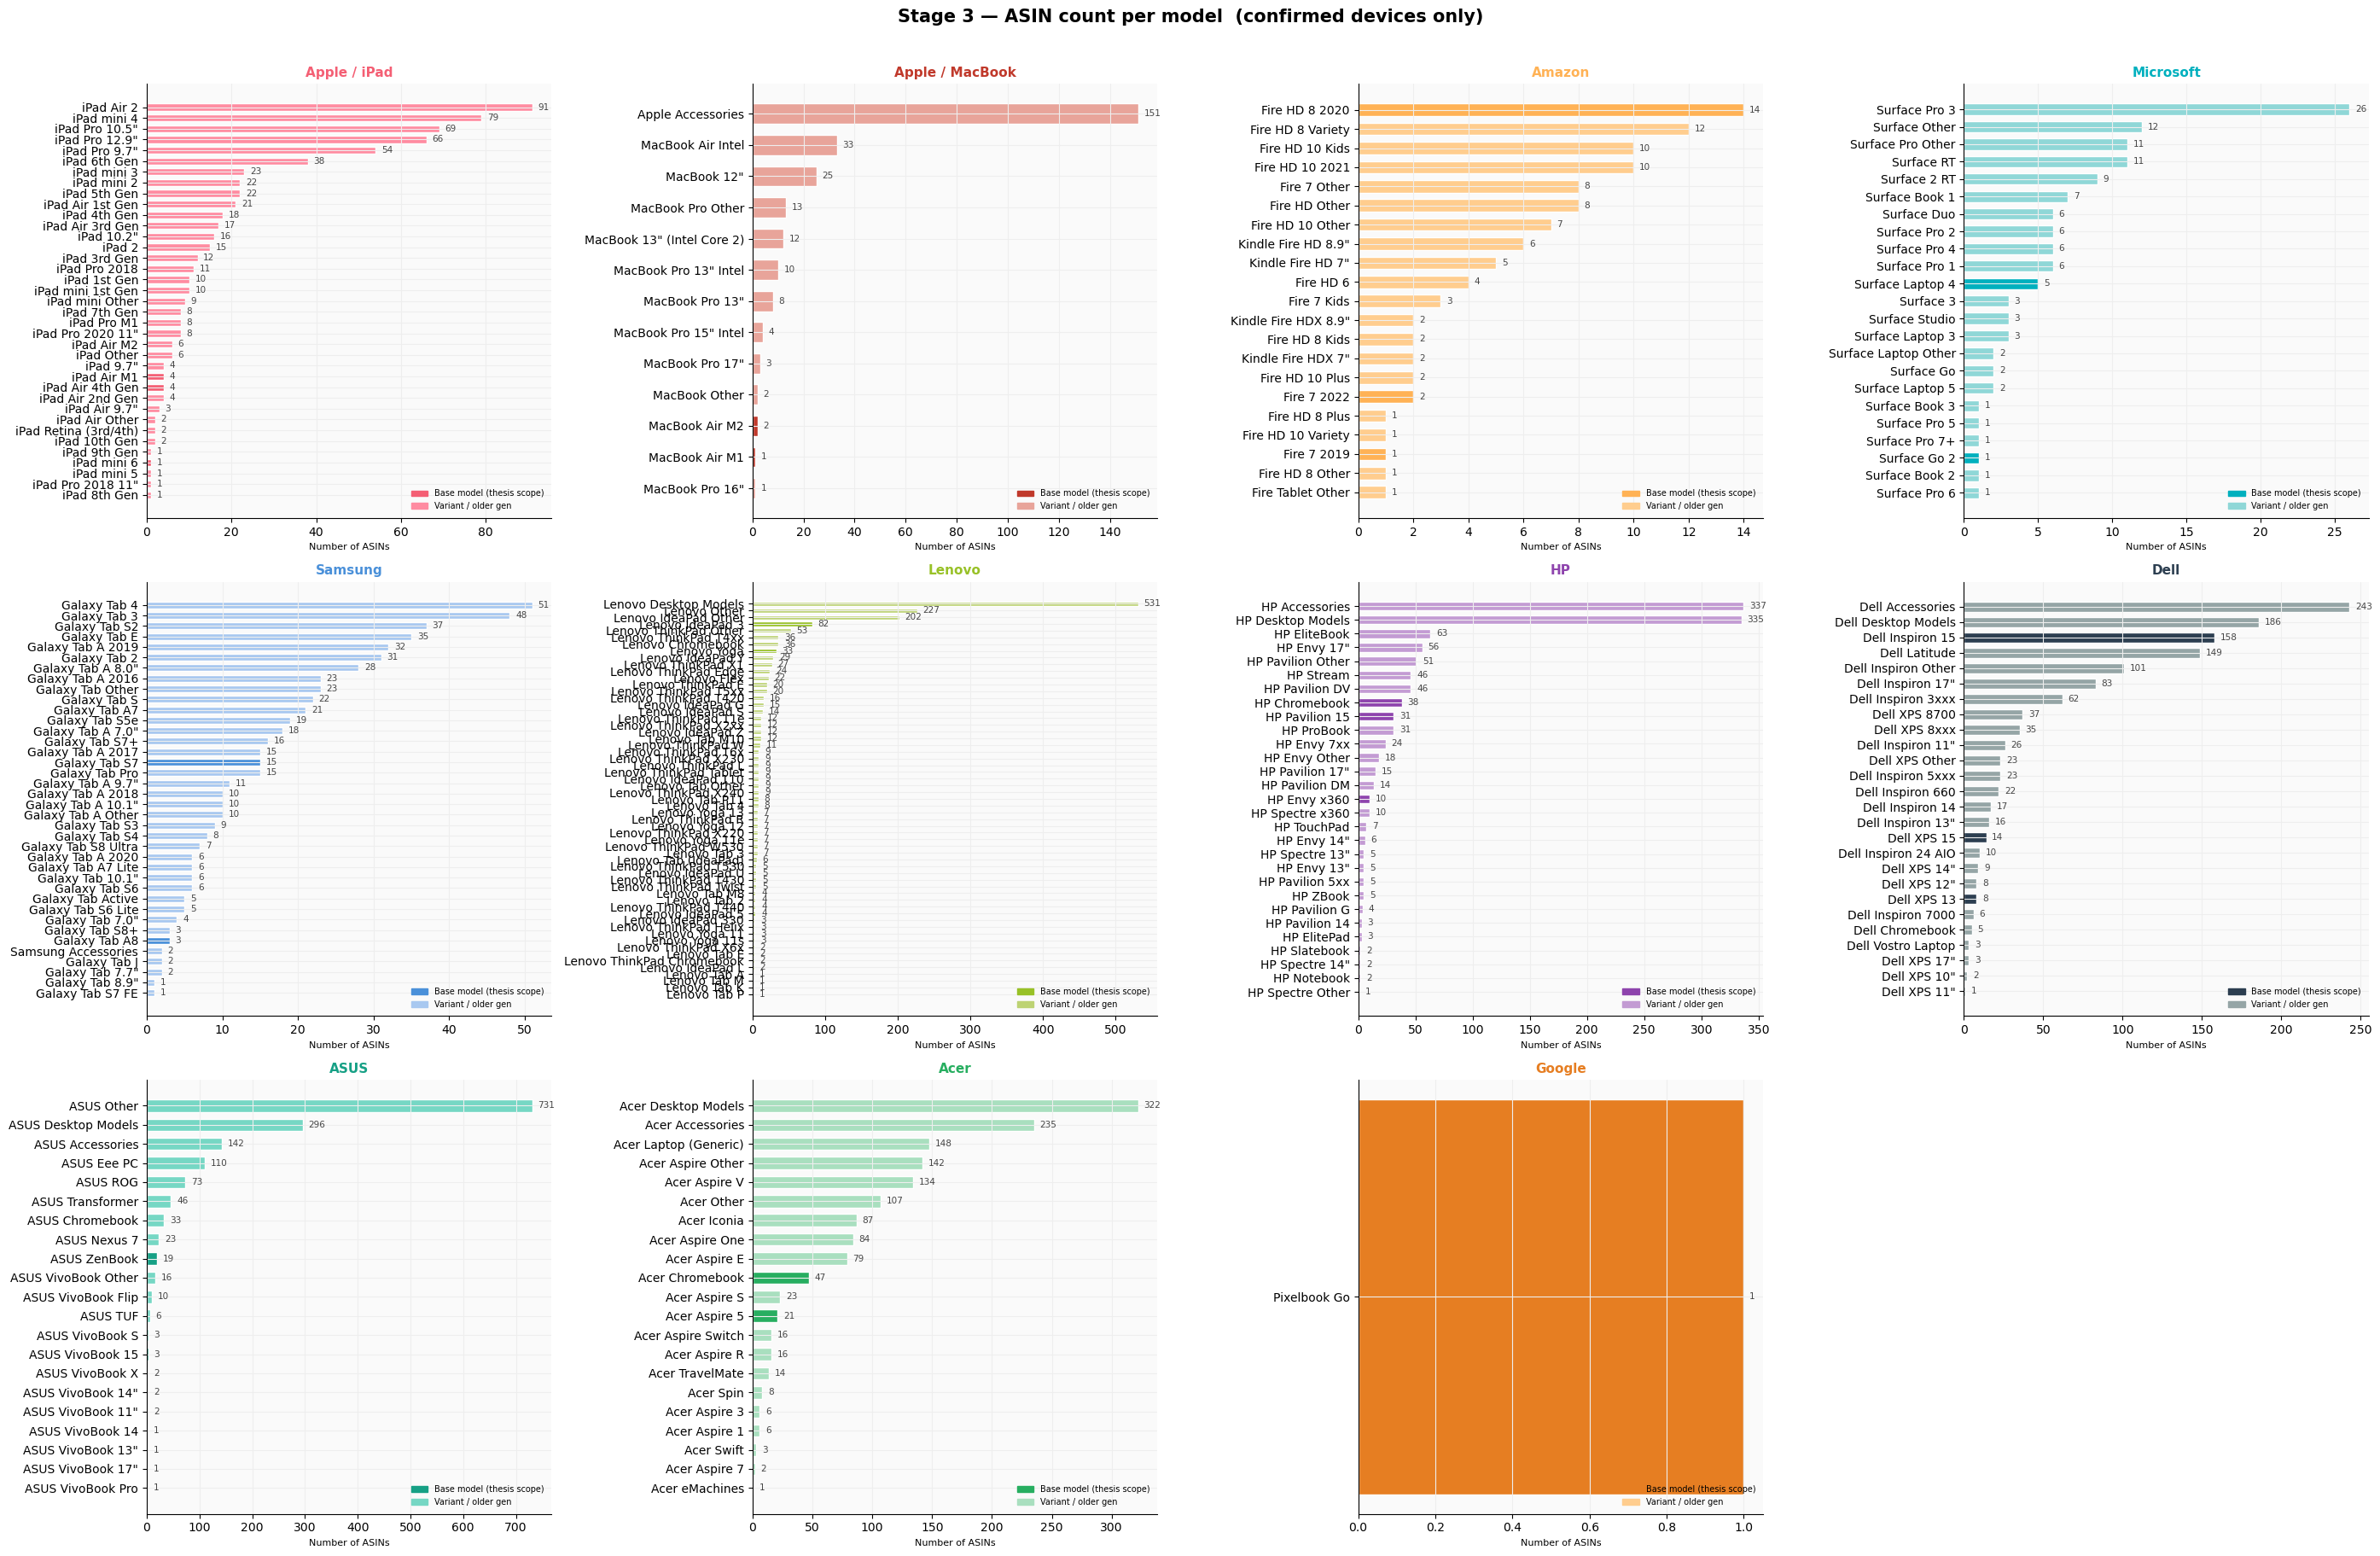

Saved: stage3_electronics_landscape.png


In [97]:
# Stage 3 landscape — 4x3 grid (11 classifier groups)
BASE_SCOPE = {
    'Apple_iPad':    {'iPad Pro 2020','iPad Pro M2','iPad mini 6','iPad Air 4th Gen','iPad Air M1'},
    'Apple_MacBook': {'MacBook Air M1','MacBook Air M2','MacBook Pro M1 16"','MacBook Pro M1 14"'},
    'Amazon':        {'Fire HD 10 2019','Fire HD 8 2020','Fire 7 2019','Fire 7 2022'},
    'Microsoft':     {'Surface Pro 7','Surface Pro 8','Surface Go 2','Surface Go 3','Surface Laptop 4'},
    'Samsung':       {'Galaxy Tab S7','Galaxy Tab S8','Galaxy Tab A8'},
    'Lenovo':        {'Lenovo IdeaPad 5','Lenovo IdeaPad 3','Lenovo Yoga'},
    'HP':            {'HP Pavilion 15','HP Envy x360','HP Chromebook'},
    'Dell':          {'Dell Inspiron 15','Dell XPS 13','Dell XPS 15'},
    'ASUS':          {'ASUS VivoBook 15','ASUS ZenBook'},
    'Acer':          {'Acer Aspire 5','Acer Chromebook'},
    'Google':        {'Pixelbook Go'},
}

CL_DISPLAY_COLOR = {
    'Apple_iPad':    MED_PINK,    'Apple_MacBook': '#c0392b',
    'Amazon':        MED_ORANGE,  'Microsoft':     MED_BLUE,
    'Samsung':       '#4a90d9',   'Lenovo':        MED_GREEN,
    'HP':            '#8e44ad',   'Dell':          '#2c3e50',
    'ASUS':          '#16a085',   'Acer':          '#27ae60',
    'Google':        '#e67e22',
}
CL_DISPLAY_LIGHT = {
    'Apple_iPad':    LIGHT_PINK,  'Apple_MacBook': '#e8a49a',
    'Amazon':        LIGHT_ORANGE,'Microsoft':     LIGHT_BLUE,
    'Samsung':       '#a8c8f0',   'Lenovo':        LIGHT_GREEN,
    'HP':            '#c39bd3',   'Dell':          '#95a5a6',
    'ASUS':          '#76d7c4',   'Acer':          '#a9dfbf',
    'Google':        LIGHT_ORANGE,
}

CL_ORDER = list(ALL_CL.keys())
ncols, nrows = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(28, 18))
fig.suptitle('Stage 3 — ASIN count per model  (confirmed devices only)',
             fontsize=15, fontweight='bold', y=1.01)

for idx, cl_key in enumerate(CL_ORDER):
    ax    = axes.flatten()[idx]
    color = CL_DISPLAY_COLOR[cl_key]
    light = CL_DISPLAY_LIGHT[cl_key]
    rows  = sorted([(k, len(v)) for k, v in model_asins.items()
                    if model_brand.get(k) == cl_key], key=lambda x: x[1])
    if not rows:
        ax.set_visible(False)
        continue
    labels = [m for m, _ in rows]
    values = [n for _, n in rows]
    colors = [color if lbl in BASE_SCOPE.get(cl_key, set())
              else light for lbl in labels]
    bars   = ax.barh(labels, values, color=colors, edgecolor='white', height=0.65)
    for bar, v in zip(bars, values):
        ax.text(v + max(values)*0.015, bar.get_y()+bar.get_height()/2,
                str(v), va='center', fontsize=7.5, color='#444')
    title  = cl_key.replace('_', ' / ') if '_' in cl_key else cl_key
    ax.set_title(title, fontweight='bold', fontsize=11, color=color)
    ax.set_xlabel('Number of ASINs', fontsize=8)
    ax.legend(handles=[
        mpatches.Patch(color=color, label='Base model (thesis scope)'),
        mpatches.Patch(color=light, label='Variant / older gen'),
    ], frameon=False, fontsize=7, loc='lower right')

# Hide unused panels
for i in range(len(CL_ORDER), nrows*ncols):
    axes.flatten()[i].set_visible(False)

plt.tight_layout()
plt.savefig('stage3_electronics_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stage3_electronics_landscape.png')


## Stage 4 - Thesis event selection

`candidate_asins` auto-populated from Stage 3 via `MODEL_KEY_MAP`.

**Product type rationale:**
- `iPad` -> **hedonic** (design premium, Apple ecosystem, status, lifestyle marketing)
- `Fire HD / Fire 7` -> **utilitarian** (Amazon's value/function positioning, no aspiration)
- `MacBook` -> **utilitarian** (productivity tool, task completion; classified utilitarian
  despite Apple brand — the laptop category is defined by functional use, not aspiration)
- `Surface / Galaxy Tab / Lenovo / HP / Dell` -> **utilitarian** across the board


In [98]:
# ── Stage 4 event table + classifier map (complete — Stages 3b–3e) ────────────
# All new model buckets added across Stages 3b–3e are mapped here.
# Desktop / AIO buckets and Accessories buckets are intentionally excluded.
# Proxying convention: old / obscure models point to their nearest launch event.

ELECTRONICS_EVENTS = {
    # ── Hedonic — Apple iPad ──────────────────────────────────────────────────
    'iPad 1st Gen':         {'launch': '2010-04-03', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 2':               {'launch': '2011-03-11', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 3rd Gen':         {'launch': '2012-03-16', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 4th Gen':         {'launch': '2012-11-02', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 5th Gen':         {'launch': '2017-03-24', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 6th Gen':         {'launch': '2018-03-27', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 7th Gen':         {'launch': '2019-09-25', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 8th Gen':         {'launch': '2020-09-18', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 9th Gen':         {'launch': '2021-09-24', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad 10th Gen':        {'launch': '2022-10-26', 'type': 'hedonic',     'brand': 'Apple'},
    # iPad Air
    'iPad Air 1st Gen':     {'launch': '2013-10-22', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad Air 2':           {'launch': '2014-10-16', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad Air M1':          {'launch': '2022-03-18', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad Air M2':          {'launch': '2024-05-15', 'type': 'hedonic',     'brand': 'Apple'},
    # iPad Pro
    'iPad Pro 2018':        {'launch': '2018-11-07', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad Pro 2020':        {'launch': '2020-03-25', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad Pro M1':          {'launch': '2021-05-21', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad Pro M2':          {'launch': '2022-10-26', 'type': 'hedonic',     'brand': 'Apple'},
    # iPad mini
    'iPad mini 1st Gen':    {'launch': '2012-11-02', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad mini 2':          {'launch': '2013-11-12', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad mini 3':          {'launch': '2014-10-22', 'type': 'hedonic',     'brand': 'Apple'},
    'iPad mini 6':          {'launch': '2021-09-24', 'type': 'hedonic',     'brand': 'Apple'},

    # ── Utilitarian — Apple MacBook ───────────────────────────────────────────
    'MacBook 12"':          {'launch': '2017-06-05', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Air Intel':    {'launch': '2018-11-07', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Air M1':       {'launch': '2020-11-17', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Air M2':       {'launch': '2022-07-15', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Air M3':       {'launch': '2024-03-08', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro 15" Intel':{'launch': '2019-05-21', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro 16" Intel':{'launch': '2019-11-13', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro 13" Intel':{'launch': '2020-05-04', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro 2017':     {'launch': '2017-06-05', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro 2018':     {'launch': '2018-07-12', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro 2019':     {'launch': '2019-05-21', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M1':       {'launch': '2020-11-17', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M1 14"':   {'launch': '2021-10-26', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M1 16"':   {'launch': '2021-10-26', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M2':       {'launch': '2022-06-24', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M2 14"':   {'launch': '2023-01-24', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M2 16"':   {'launch': '2023-01-24', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M3':       {'launch': '2023-11-07', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M3 14"':   {'launch': '2023-11-07', 'type': 'utilitarian', 'brand': 'Apple'},
    'MacBook Pro M3 16"':   {'launch': '2023-11-07', 'type': 'utilitarian', 'brand': 'Apple'},

    # ── Utilitarian — Amazon Fire ─────────────────────────────────────────────
    'Kindle Fire HD 7"':    {'launch': '2012-09-14', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Kindle Fire HDX 7"':   {'launch': '2013-11-07', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Kindle Fire HDX 8.9"': {'launch': '2013-11-07', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 6':            {'launch': '2014-10-16', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Kindle Fire HD 8.9"':  {'launch': '2012-09-14', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 8 2018':       {'launch': '2018-10-04', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 8 2020':       {'launch': '2020-06-03', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 8 2022':       {'launch': '2022-10-19', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 8 Plus':       {'launch': '2020-06-03', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 10 2019':      {'launch': '2019-10-30', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 10 2021':      {'launch': '2021-05-26', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 10 2023':      {'launch': '2023-10-18', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire HD 10 Plus':      {'launch': '2021-05-26', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire 7 2019':          {'launch': '2019-06-06', 'type': 'utilitarian', 'brand': 'Amazon'},
    'Fire 7 2022':          {'launch': '2022-06-29', 'type': 'utilitarian', 'brand': 'Amazon'},

    # ── Utilitarian — Microsoft Surface ──────────────────────────────────────
    'Surface RT':           {'launch': '2012-10-26', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface 2':            {'launch': '2013-10-22', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface 3':            {'launch': '2015-05-05', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 1':        {'launch': '2013-02-09', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 2':        {'launch': '2013-10-22', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 3':        {'launch': '2014-06-20', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 4':        {'launch': '2015-10-26', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 5':        {'launch': '2017-06-15', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 6':        {'launch': '2018-10-16', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 7':        {'launch': '2019-10-22', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 7+':       {'launch': '2021-01-15', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro X':        {'launch': '2019-11-05', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 8':        {'launch': '2021-10-05', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Pro 9':        {'launch': '2022-10-25', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Go':           {'launch': '2018-08-02', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Go 2':         {'launch': '2020-05-12', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Go 3':         {'launch': '2021-10-05', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Book 1':       {'launch': '2015-10-26', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Book 2':       {'launch': '2017-11-16', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Book 3':       {'launch': '2020-05-21', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Laptop 3':     {'launch': '2019-10-22', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Laptop 4':     {'launch': '2021-04-15', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Laptop 5':     {'launch': '2022-10-25', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Laptop Go':    {'launch': '2020-10-13', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Laptop Go 2':  {'launch': '2022-06-07', 'type': 'utilitarian', 'brand': 'Microsoft'},
    'Surface Duo':          {'launch': '2020-09-10', 'type': 'utilitarian', 'brand': 'Microsoft'},

    # ── Utilitarian — Samsung Galaxy Tab ─────────────────────────────────────
    'Galaxy Tab S2':        {'launch': '2015-09-25', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S3':        {'launch': '2017-02-26', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S4':        {'launch': '2018-08-01', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S5e':       {'launch': '2019-03-08', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S6':        {'launch': '2019-09-06', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S6 Lite':   {'launch': '2020-05-16', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S7':        {'launch': '2020-08-21', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S7+':       {'launch': '2020-08-21', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S7 FE':     {'launch': '2021-06-18', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S8':        {'launch': '2022-02-25', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S8+':       {'launch': '2022-02-25', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S8 Ultra':  {'launch': '2022-02-25', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S9':        {'launch': '2023-08-11', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S9+':       {'launch': '2023-08-11', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab S9 Ultra':  {'launch': '2023-08-11', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab A 2016':    {'launch': '2016-03-18', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab A 2017':    {'launch': '2017-06-09', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab A 2018':    {'launch': '2018-09-27', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab A 2019':    {'launch': '2019-09-27', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab A7':        {'launch': '2020-09-11', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab A7 Lite':   {'launch': '2021-06-18', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Galaxy Tab A8':        {'launch': '2022-01-07', 'type': 'utilitarian', 'brand': 'Samsung'},

    # ── Utilitarian — Lenovo ─────────────────────────────────────────────────
    'Lenovo Tab M8':        {'launch': '2019-10-01', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo Tab M10':       {'launch': '2020-09-08', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo Tab P11':       {'launch': '2021-01-21', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo Tab P12':       {'launch': '2023-07-26', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo IdeaPad 3':     {'launch': '2021-01-01', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo IdeaPad 5':     {'launch': '2020-09-01', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo ThinkPad E':    {'launch': '2020-06-15', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo ThinkPad X1':   {'launch': '2021-03-01', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo Yoga':          {'launch': '2020-10-20', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo Chromebook':    {'launch': '2020-06-01', 'type': 'utilitarian', 'brand': 'Lenovo'},
    'Lenovo Flex':          {'launch': '2020-10-20', 'type': 'utilitarian', 'brand': 'Lenovo'},

    # ── Utilitarian — HP ──────────────────────────────────────────────────────
    'HP Stream':            {'launch': '2019-09-15', 'type': 'utilitarian', 'brand': 'HP'},
    'HP Chromebook':        {'launch': '2020-04-01', 'type': 'utilitarian', 'brand': 'HP'},
    'HP ProBook':           {'launch': '2020-06-01', 'type': 'utilitarian', 'brand': 'HP'},
    'HP EliteBook':         {'launch': '2020-06-01', 'type': 'utilitarian', 'brand': 'HP'},
    'HP ZBook':             {'launch': '2020-06-01', 'type': 'utilitarian', 'brand': 'HP'},
    'HP Pavilion 14':       {'launch': '2020-10-15', 'type': 'utilitarian', 'brand': 'HP'},
    'HP Pavilion 15':       {'launch': '2020-10-15', 'type': 'utilitarian', 'brand': 'HP'},
    'HP Pavilion 17"':      {'launch': '2020-10-15', 'type': 'utilitarian', 'brand': 'HP'},
    'HP Envy x360':         {'launch': '2020-05-15', 'type': 'utilitarian', 'brand': 'HP'},
    'HP Envy 17"':          {'launch': '2020-05-15', 'type': 'utilitarian', 'brand': 'HP'},
    'HP Spectre x360':      {'launch': '2019-10-15', 'type': 'utilitarian', 'brand': 'HP'},

    # ── Utilitarian — Dell ────────────────────────────────────────────────────
    'Dell Chromebook':      {'launch': '2019-08-22', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell Latitude':        {'launch': '2020-05-19', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell Vostro Laptop':   {'launch': '2020-05-19', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell Inspiron 11"':    {'launch': '2019-04-15', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell Inspiron 13"':    {'launch': '2020-04-15', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell Inspiron 14':     {'launch': '2020-04-15', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell Inspiron 15':     {'launch': '2020-04-15', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell Inspiron 17"':    {'launch': '2020-04-15', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell Inspiron 7000':   {'launch': '2020-05-13', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell XPS 13':          {'launch': '2020-01-07', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell XPS 14"':         {'launch': '2019-01-07', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell XPS 15':          {'launch': '2020-05-13', 'type': 'utilitarian', 'brand': 'Dell'},
    'Dell XPS 17"':         {'launch': '2020-05-13', 'type': 'utilitarian', 'brand': 'Dell'},

    # ── Utilitarian — ASUS ────────────────────────────────────────────────────
    'ASUS Chromebook':      {'launch': '2020-05-01', 'type': 'utilitarian', 'brand': 'ASUS'},
    'ASUS ROG':             {'launch': '2020-04-02', 'type': 'utilitarian', 'brand': 'ASUS'},
    'ASUS TUF':             {'launch': '2020-04-02', 'type': 'utilitarian', 'brand': 'ASUS'},
    'ASUS Transformer':     {'launch': '2020-03-01', 'type': 'utilitarian', 'brand': 'ASUS'},
    'ASUS VivoBook 14':     {'launch': '2020-04-20', 'type': 'utilitarian', 'brand': 'ASUS'},
    'ASUS VivoBook 15':     {'launch': '2020-04-20', 'type': 'utilitarian', 'brand': 'ASUS'},
    'ASUS ZenBook':         {'launch': '2020-06-02', 'type': 'utilitarian', 'brand': 'ASUS'},

    # ── Utilitarian — Acer ────────────────────────────────────────────────────
    'Acer Aspire 3':        {'launch': '2020-05-10', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Aspire 5':        {'launch': '2020-05-10', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Aspire 7':        {'launch': '2020-05-10', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Aspire E':        {'launch': '2020-05-10', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Aspire V':        {'launch': '2020-05-10', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Aspire One':      {'launch': '2019-05-10', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Aspire Nitro':    {'launch': '2020-09-03', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Iconia':          {'launch': '2020-06-01', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Spin':            {'launch': '2020-09-03', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Swift':           {'launch': '2020-09-03', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer Chromebook':      {'launch': '2020-03-15', 'type': 'utilitarian', 'brand': 'Acer'},
    'Acer TravelMate':      {'launch': '2020-06-01', 'type': 'utilitarian', 'brand': 'Acer'},

    # ── Utilitarian — Google ──────────────────────────────────────────────────
    'Pixelbook':            {'launch': '2017-10-31', 'type': 'utilitarian', 'brand': 'Google'},
    'Pixelbook Go':         {'launch': '2019-10-28', 'type': 'utilitarian', 'brand': 'Google'},
}

WINDOW_DAYS = 90

MODEL_KEY_MAP = {
    # ── Apple / iPad Pro ──────────────────────────────────────────────────────
    'iPad Pro M2 12.9"':             'iPad Pro M2',
    'iPad Pro M2 11"':               'iPad Pro M2',
    'iPad Pro M2':                   'iPad Pro M2',
    'iPad Pro M1 12.9"':             'iPad Pro M1',
    'iPad Pro M1 11"':               'iPad Pro M1',
    'iPad Pro M1':                   'iPad Pro M1',
    'iPad Pro 2020 12.9"':           'iPad Pro 2020',
    'iPad Pro 2020 11"':             'iPad Pro 2020',
    'iPad Pro 2020':                 'iPad Pro 2020',
    'iPad Pro 2018 12.9"':           'iPad Pro 2018',
    'iPad Pro 2018 11"':             'iPad Pro 2018',
    'iPad Pro 2018':                 'iPad Pro 2018',
    'iPad Pro 12.9"':                'iPad Pro 2018',
    'iPad Pro 10.5"':                'iPad Pro 2018',
    'iPad Pro 9.7"':                 'iPad Pro 2018',
    'iPad Pro Other':                'iPad Pro 2020',

    # ── Apple / iPad Air ─────────────────────────────────────────────────────
    'iPad Air M2':                   'iPad Air M2',
    'iPad Air M1':                   'iPad Air M1',
    'iPad Air 4th Gen':              'iPad Air M1',
    'iPad Air 3rd Gen':              'iPad Air 2',
    'iPad Air 2nd Gen':              'iPad Air 2',
    'iPad Air 2':                    'iPad Air 2',
    'iPad Air 1st Gen':              'iPad Air 1st Gen',
    'iPad Air 9.7"':                 'iPad Air 2',
    'iPad Air Other':                'iPad Air M1',

    # ── Apple / iPad mini ────────────────────────────────────────────────────
    'iPad mini 6':                   'iPad mini 6',
    'iPad mini 5':                   'iPad mini 6',
    'iPad mini 4':                   'iPad mini 6',
    'iPad mini 3':                   'iPad mini 3',
    'iPad mini 2':                   'iPad mini 2',
    'iPad mini 1st Gen':             'iPad mini 1st Gen',
    'iPad mini Other':               'iPad mini 6',

    # ── Apple / iPad standard ────────────────────────────────────────────────
    'iPad 10th Gen':                 'iPad 10th Gen',
    'iPad 9th Gen':                  'iPad 9th Gen',
    'iPad 8th Gen':                  'iPad 8th Gen',
    'iPad 7th Gen':                  'iPad 7th Gen',
    'iPad 6th Gen':                  'iPad 6th Gen',
    'iPad 5th Gen':                  'iPad 5th Gen',
    'iPad 4th Gen':                  'iPad 4th Gen',
    'iPad 3rd Gen':                  'iPad 3rd Gen',
    'iPad 2':                        'iPad 2',
    'iPad 1st Gen':                  'iPad 1st Gen',
    'iPad 10.2"':                    'iPad 7th Gen',
    'iPad 9.7"':                     'iPad 6th Gen',
    'iPad Retina (3rd/4th)':         'iPad 4th Gen',
    'iPad Other':                    'iPad 9th Gen',

    # ── Apple / MacBook Air ──────────────────────────────────────────────────
    'MacBook Air M3':                'MacBook Air M3',
    'MacBook Air M2':                'MacBook Air M2',
    'MacBook Air M1':                'MacBook Air M1',
    'MacBook Air Intel':             'MacBook Air Intel',
    'MacBook Air Other':             'MacBook Air Intel',

    # ── Apple / MacBook Pro ──────────────────────────────────────────────────
    'MacBook Pro M3 16"':            'MacBook Pro M3 16"',
    'MacBook Pro M3 14"':            'MacBook Pro M3 14"',
    'MacBook Pro M3':                'MacBook Pro M3',
    'MacBook Pro M2 16"':            'MacBook Pro M2 16"',
    'MacBook Pro M2 14"':            'MacBook Pro M2 14"',
    'MacBook Pro M2':                'MacBook Pro M2',
    'MacBook Pro M1 16"':            'MacBook Pro M1 16"',
    'MacBook Pro M1 14"':            'MacBook Pro M1 14"',
    'MacBook Pro M1':                'MacBook Pro M1',
    'MacBook Pro 16" Intel':         'MacBook Pro 16" Intel',
    'MacBook Pro 16"':               'MacBook Pro 16" Intel',
    'MacBook Pro 15" Intel':         'MacBook Pro 15" Intel',
    'MacBook Pro 13" Intel':         'MacBook Pro 13" Intel',
    'MacBook Pro 13"':               'MacBook Pro 13" Intel',
    'MacBook Pro 2019':              'MacBook Pro 2019',
    'MacBook Pro 2018':              'MacBook Pro 2018',
    'MacBook Pro 2017':              'MacBook Pro 2017',
    'MacBook Pro Other':             'MacBook Pro 16" Intel',

    # ── Apple / MacBook (12") ─────────────────────────────────────────────────
    'MacBook 12"':                   'MacBook 12"',
    'MacBook 13" (Intel Core 2)':    'MacBook Air Intel',
    'MacBook M3':                    'MacBook Air M3',
    'MacBook Other':                 'MacBook Air M2',

    # ── Amazon / Fire HD 10 ───────────────────────────────────────────────────
    'Fire HD 10 Plus':               'Fire HD 10 Plus',
    'Fire HD 10 2023':               'Fire HD 10 2023',
    'Fire HD 10 2021':               'Fire HD 10 2021',
    'Fire HD 10 2019':               'Fire HD 10 2019',
    'Fire HD 10 Kids':               'Fire HD 10 2021',
    'Fire HD 10 Variety':            'Fire HD 10 2021',
    'Fire HD 10 Other':              'Fire HD 10 2019',

    # ── Amazon / Fire HD 8 ───────────────────────────────────────────────────
    'Fire HD 8 Plus':                'Fire HD 8 Plus',
    'Fire HD 8 2022':                'Fire HD 8 2022',
    'Fire HD 8 2020':                'Fire HD 8 2020',
    'Fire HD 8 2018':                'Fire HD 8 2018',
    'Fire HD 8 Kids':                'Fire HD 8 2020',
    'Kindle Fire HD 8.9"':           'Kindle Fire HD 8.9"',
    'Fire HD 8 Variety':             'Fire HD 8 2020',
    'Fire HD 8 Other':               'Fire HD 8 2020',

    # ── Amazon / Fire 7 ──────────────────────────────────────────────────────
    'Fire 7 2022':                   'Fire 7 2022',
    'Fire 7 2019':                   'Fire 7 2019',
    'Fire 7 Kids':                   'Fire 7 2022',
    'Fire 7 Family Pack':            'Fire 7 2019',
    'Fire 7 Other':                  'Fire 7 2019',

    # ── Amazon / Fire HD legacy ───────────────────────────────────────────────
    'Kindle Fire HD 7"':             'Kindle Fire HD 7"',
    'Kindle Fire HDX 7"':            'Kindle Fire HDX 7"',
    'Kindle Fire HDX 8.9"':          'Kindle Fire HDX 8.9"',
    'Fire HD 6':                     'Fire HD 6',
    'Fire HD Other':                 'Fire HD 8 2020',
    'Fire Tablet Other':             'Fire HD 10 2021',

    # ── Microsoft / Surface Pro ───────────────────────────────────────────────
    'Surface Pro 9':                 'Surface Pro 9',
    'Surface Pro 8':                 'Surface Pro 8',
    'Surface Pro 7+':                'Surface Pro 7+',
    'Surface Pro 7':                 'Surface Pro 7',
    'Surface Pro X':                 'Surface Pro X',
    'Surface Pro 6':                 'Surface Pro 6',
    'Surface Pro 5':                 'Surface Pro 5',
    'Surface Pro 4':                 'Surface Pro 4',
    'Surface Pro 3':                 'Surface Pro 3',
    'Surface Pro 2':                 'Surface Pro 2',
    'Surface Pro 1':                 'Surface Pro 1',
    'Surface Pro Other':             'Surface Pro 8',

    # ── Microsoft / Surface Go & Laptop ──────────────────────────────────────
    'Surface Go 3':                  'Surface Go 3',
    'Surface Go 2':                  'Surface Go 2',
    'Surface Go':                    'Surface Go',
    'Surface Laptop 5':              'Surface Laptop 5',
    'Surface Laptop 4':              'Surface Laptop 4',
    'Surface Laptop 3':              'Surface Laptop 3',
    'Surface Laptop Go 2':           'Surface Laptop Go 2',
    'Surface Laptop Go':             'Surface Laptop Go',
    'Surface Laptop Other':          'Surface Laptop 4',

    # ── Microsoft / Surface Book & Other ─────────────────────────────────────
    'Surface Book 3':                'Surface Book 3',
    'Surface Book 2':                'Surface Book 2',
    'Surface Book 1':                'Surface Book 1',
    'Surface Book Other':            'Surface Book 2',
    'Surface RT':                    'Surface RT',
    'Surface 2 RT':                  'Surface 2',
    'Surface 3':                     'Surface 3',
    'Surface Duo':                   'Surface Duo',
    'Surface Other':                 'Surface Pro 8',

    # ── Samsung / Galaxy Tab S ────────────────────────────────────────────────
    'Galaxy Tab S9 Ultra':           'Galaxy Tab S9 Ultra',
    'Galaxy Tab S9+':                'Galaxy Tab S9+',
    'Galaxy Tab S9':                 'Galaxy Tab S9',
    'Galaxy Tab S8 Ultra':           'Galaxy Tab S8 Ultra',
    'Galaxy Tab S8+':                'Galaxy Tab S8+',
    'Galaxy Tab S8':                 'Galaxy Tab S8',
    'Galaxy Tab S7+':                'Galaxy Tab S7+',
    'Galaxy Tab S7 FE':              'Galaxy Tab S7 FE',
    'Galaxy Tab S7':                 'Galaxy Tab S7',
    'Galaxy Tab S6 Lite':            'Galaxy Tab S6 Lite',
    'Galaxy Tab S6':                 'Galaxy Tab S6',
    'Galaxy Tab S5e':                'Galaxy Tab S5e',
    'Galaxy Tab S4':                 'Galaxy Tab S4',
    'Galaxy Tab S3':                 'Galaxy Tab S3',
    'Galaxy Tab S2':                 'Galaxy Tab S2',
    'Galaxy Tab S 2014':             'Galaxy Tab S2',

    # ── Samsung / Galaxy Tab A ────────────────────────────────────────────────
    'Galaxy Tab A8':                 'Galaxy Tab A8',
    'Galaxy Tab A7 Lite':            'Galaxy Tab A7 Lite',
    'Galaxy Tab A7':                 'Galaxy Tab A7',
    'Galaxy Tab A 2020':             'Galaxy Tab A7',
    'Galaxy Tab A 2019':             'Galaxy Tab A 2019',
    'Galaxy Tab A 2018':             'Galaxy Tab A 2018',
    'Galaxy Tab A 2017':             'Galaxy Tab A 2017',
    'Galaxy Tab A 2016':             'Galaxy Tab A 2016',
    'Galaxy Tab A 10.1"':            'Galaxy Tab A 2019',
    'Galaxy Tab A 9.7"':             'Galaxy Tab A 2016',
    'Galaxy Tab A 8.0"':             'Galaxy Tab A8',
    'Galaxy Tab A 7.0"':             'Galaxy Tab A 2016',
    'Galaxy Tab A Other':            'Galaxy Tab A8',

    # ── Samsung / Galaxy Tab legacy ───────────────────────────────────────────
    'Galaxy Tab 4':                  'Galaxy Tab S2',
    'Galaxy Tab 3':                  'Galaxy Tab S2',
    'Galaxy Tab 2':                  'Galaxy Tab S2',
    'Galaxy Tab E':                  'Galaxy Tab A7',
    'Galaxy Tab Pro':                'Galaxy Tab S6',
    'Galaxy Tab Active':             'Galaxy Tab A7',
    'Galaxy Tab J':                  'Galaxy Tab A7',
    'Galaxy Tab 10.1"':              'Galaxy Tab S2',
    'Galaxy Tab 8.9"':               'Galaxy Tab S2',
    'Galaxy Tab 7.7"':               'Galaxy Tab S2',
    'Galaxy Tab 7.0"':               'Galaxy Tab S2',
    'Galaxy Tab Other':              'Galaxy Tab S8',

    # ── Lenovo / Tablets ─────────────────────────────────────────────────────
    'Lenovo Tab P12':                'Lenovo Tab P12',
    'Lenovo Tab P11':                'Lenovo Tab P11',
    'Lenovo Tab M10':                'Lenovo Tab M10',
    'Lenovo Tab M8':                 'Lenovo Tab M8',
    'Lenovo Tab 4':                  'Lenovo Tab M8',
    'Lenovo Tab 3':                  'Lenovo Tab M8',
    'Lenovo Tab 2':                  'Lenovo Tab M8',
    'Lenovo Tab E':                  'Lenovo Tab M8',
    'Lenovo Tab P':                  'Lenovo Tab P11',
    'Lenovo Tab M':                  'Lenovo Tab M10',
    'Lenovo Tab K':                  'Lenovo Tab M8',
    'Lenovo Tab A':                  'Lenovo Tab M8',
    'Lenovo Tab (IdeaPad)':          'Lenovo Tab M8',
    'Lenovo Tab Other':              'Lenovo Tab M10',

    # ── Lenovo / Laptops ──────────────────────────────────────────────────────
    'Lenovo IdeaPad 5':              'Lenovo IdeaPad 5',
    'Lenovo IdeaPad 3':              'Lenovo IdeaPad 3',
    'Lenovo IdeaPad 330':            'Lenovo IdeaPad 3',
    'Lenovo IdeaPad 110':            'Lenovo IdeaPad 3',
    'Lenovo IdeaPad 100':            'Lenovo IdeaPad 3',
    'Lenovo IdeaPad Y':              'Lenovo IdeaPad 5',
    'Lenovo IdeaPad Z':              'Lenovo IdeaPad 5',
    'Lenovo IdeaPad G':              'Lenovo IdeaPad 3',
    'Lenovo IdeaPad S':              'Lenovo IdeaPad 3',
    'Lenovo IdeaPad L':              'Lenovo IdeaPad 3',
    'Lenovo IdeaPad U':              'Lenovo IdeaPad 5',
    'Lenovo IdeaPad Other':          'Lenovo IdeaPad 5',
    'Lenovo ThinkPad X1':            'Lenovo ThinkPad X1',
    'Lenovo ThinkPad E':             'Lenovo ThinkPad E',
    'Lenovo ThinkPad T420':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad T430':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad T440':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad T530':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad T540':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad X220':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad X230':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad X240':          'Lenovo ThinkPad X1',
    'Lenovo ThinkPad W530':          'Lenovo ThinkPad X1',
    'Lenovo ThinkPad T4xx':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad T5xx':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad T6x':           'Lenovo ThinkPad E',
    'Lenovo ThinkPad X2xx':          'Lenovo ThinkPad X1',
    'Lenovo ThinkPad X6x':           'Lenovo ThinkPad E',
    'Lenovo ThinkPad W':             'Lenovo ThinkPad X1',
    'Lenovo ThinkPad L':             'Lenovo ThinkPad E',
    'Lenovo ThinkPad Edge':          'Lenovo ThinkPad E',
    'Lenovo ThinkPad 11e':           'Lenovo ThinkPad E',
    'Lenovo ThinkPad R':             'Lenovo ThinkPad E',
    'Lenovo ThinkPad Helix':         'Lenovo ThinkPad X1',
    'Lenovo ThinkPad Twist':         'Lenovo ThinkPad X1',
    'Lenovo ThinkPad Tablet':        'Lenovo Tab M10',
    'Lenovo ThinkPad Chromebook':    'Lenovo Chromebook',
    'Lenovo ThinkPad Other':         'Lenovo ThinkPad X1',
    'Lenovo Yoga':                   'Lenovo Yoga',
    'Lenovo Yoga 13':                'Lenovo Yoga',
    'Lenovo Yoga 11e':               'Lenovo Yoga',
    'Lenovo Yoga 12':                'Lenovo Yoga',
    'Lenovo Yoga 11s':               'Lenovo Yoga',
    'Lenovo Yoga 11':                'Lenovo Yoga',
    'Lenovo Flex':                   'Lenovo Flex',
    'Lenovo Chromebook':             'Lenovo Chromebook',
    'Lenovo Other':                  'Lenovo IdeaPad 5',

    # ── HP ────────────────────────────────────────────────────────────────────
    'HP Spectre x360':               'HP Spectre x360',
    'HP Spectre 13"':                'HP Spectre x360',
    'HP Spectre 14"':                'HP Spectre x360',
    'HP Spectre Other':              'HP Spectre x360',
    'HP Envy x360':                  'HP Envy x360',
    'HP Envy 17"':                   'HP Envy 17"',
    'HP Envy 14"':                   'HP Envy x360',
    'HP Envy 13"':                   'HP Envy x360',
    'HP Envy Other':                 'HP Envy x360',
    'HP Pavilion 15':                'HP Pavilion 15',
    'HP Pavilion 14':                'HP Pavilion 14',
    'HP Pavilion 17"':               'HP Pavilion 17"',
    'HP Pavilion DV':                'HP Pavilion 15',
    'HP Pavilion G':                 'HP Pavilion 15',
    'HP Pavilion DM':                'HP Pavilion 14',
    'HP Pavilion Other':             'HP Pavilion 15',
    'HP Chromebook':                 'HP Chromebook',
    'HP EliteBook':                  'HP EliteBook',
    'HP ProBook':                    'HP ProBook',
    'HP ZBook':                      'HP ZBook',
    'HP Stream':                     'HP Stream',
    'HP ElitePad':                   'HP EliteBook',
    'HP Slatebook':                  'HP Pavilion 14',
    'HP Notebook':                   'HP Pavilion 15',
    'HP Other':                      'HP Pavilion 15',

    # ── Dell ──────────────────────────────────────────────────────────────────
    'Dell XPS 15':                   'Dell XPS 15',
    'Dell XPS 13':                   'Dell XPS 13',
    'Dell XPS 17"':                  'Dell XPS 17"',
    'Dell XPS 14"':                  'Dell XPS 14"',
    'Dell XPS 12"':                  'Dell XPS 13',
    'Dell XPS 11"':                  'Dell XPS 13',
    'Dell XPS 10"':                  'Dell XPS 13',
    'Dell XPS Other':                'Dell XPS 13',
    'Dell Inspiron 15':              'Dell Inspiron 15',
    'Dell Inspiron 14':              'Dell Inspiron 14',
    'Dell Inspiron 17"':             'Dell Inspiron 17"',
    'Dell Inspiron 13"':             'Dell Inspiron 13"',
    'Dell Inspiron 11"':             'Dell Inspiron 11"',
    'Dell Inspiron 7000':            'Dell Inspiron 7000',
    'Dell Inspiron 3xxx':            'Dell Inspiron 15',
    'Dell Inspiron 5xxx':            'Dell Inspiron 15',
    'Dell Inspiron Other':           'Dell Inspiron 15',
    'Dell Latitude':                 'Dell Latitude',
    'Dell Chromebook':               'Dell Chromebook',
    'Dell Vostro Laptop':            'Dell Vostro Laptop',
    'Dell Other':                    'Dell Inspiron 15',

    # ── ASUS ──────────────────────────────────────────────────────────────────
    'ASUS ZenBook':                  'ASUS ZenBook',
    'ASUS VivoBook 15':              'ASUS VivoBook 15',
    'ASUS VivoBook 14':              'ASUS VivoBook 14',
    'ASUS VivoBook Flip':            'ASUS VivoBook 15',
    'ASUS VivoBook S':               'ASUS VivoBook 15',
    'ASUS VivoBook X':               'ASUS VivoBook 15',
    'ASUS VivoBook Pro':             'ASUS VivoBook 15',
    'ASUS VivoBook 17"':             'ASUS VivoBook 15',
    'ASUS VivoBook 13"':             'ASUS VivoBook 14',
    'ASUS VivoBook 11"':             'ASUS VivoBook 14',
    'ASUS VivoBook Other':           'ASUS VivoBook 15',
    'ASUS ROG':                      'ASUS ROG',
    'ASUS TUF':                      'ASUS TUF',
    'ASUS Transformer':              'ASUS Transformer',
    'ASUS Eee PC':                   'ASUS VivoBook 14',
    'ASUS Nexus 7':                  'ASUS VivoBook 14',
    'ASUS Chromebook':               'ASUS Chromebook',
    'ASUS Other':                    'ASUS VivoBook 15',

    # ── Acer ──────────────────────────────────────────────────────────────────
    'Acer Aspire 5':                 'Acer Aspire 5',
    'Acer Aspire 3':                 'Acer Aspire 3',
    'Acer Aspire 7':                 'Acer Aspire 7',
    'Acer Aspire E':                 'Acer Aspire E',
    'Acer Aspire V':                 'Acer Aspire V',
    'Acer Aspire S':                 'Acer Aspire 5',
    'Acer Aspire R':                 'Acer Aspire 5',
    'Acer Aspire One':               'Acer Aspire One',
    'Acer Aspire Switch':            'Acer Aspire 3',
    'Acer Aspire Nitro':             'Acer Aspire Nitro',
    'Acer Aspire 1':                 'Acer Aspire 3',
    'Acer Aspire Other':             'Acer Aspire 5',
    'Acer Swift':                    'Acer Swift',
    'Acer Spin':                     'Acer Spin',
    'Acer Chromebook':               'Acer Chromebook',
    'Acer TravelMate':               'Acer TravelMate',
    'Acer Iconia':                   'Acer Iconia',
    'Acer eMachines':                'Acer Aspire 3',
    'Acer Laptop (Generic)':         'Acer Aspire 5',
    'Acer Other':                    'Acer Aspire 5',

    # ── Google ────────────────────────────────────────────────────────────────
    'Pixelbook Go':                  'Pixelbook Go',
    'Pixelbook':                     'Pixelbook',
    'Chromebook Other':              'Pixelbook Go',
}

candidate_asins = {}
for s3_key, ev_key in MODEL_KEY_MAP.items():
    asins = list(model_asins.get(s3_key, {}).keys())
    if ev_key in candidate_asins:
        # Multiple Stage 3 keys map to same event (e.g. Fire 7 2019 + Fire 7 2022
        # both mapping to 'Fire 7 Other') — merge ASIN lists, deduplicate
        candidate_asins[ev_key] = list(set(candidate_asins[ev_key] + asins))
    else:
        candidate_asins[ev_key] = asins

asin_to_model  = {}
asin_to_launch = {}
asin_to_type   = {}
asin_to_brand  = {}
for ev_key, asins in candidate_asins.items():
    meta = ELECTRONICS_EVENTS[ev_key]
    for asin in asins:
        asin_to_model[asin]  = ev_key
        asin_to_launch[asin] = pd.Timestamp(meta['launch'])
        asin_to_type[asin]   = meta['type']
        asin_to_brand[asin]  = meta['brand']
valid_asins = set(asin_to_model)

print(f'{"Event":<30} {"Stage 3 key":<30} {"ASINs":>7}')
print('-' * 70)
for s3_key, ev_key in MODEL_KEY_MAP.items():
    n    = len(candidate_asins[ev_key])
    flag = '  <- 0 ASINs: check Stage 3' if n == 0 else ''
    print(f'  {ev_key:<28} {s3_key:<30} {n:>7}{flag}')
print(f'\nTotal valid ASINs: {len(valid_asins):,}')


Event                          Stage 3 key                      ASINs
----------------------------------------------------------------------
  iPad Pro M2                  iPad Pro M2 12.9"                    0  <- 0 ASINs: check Stage 3
  iPad Pro M2                  iPad Pro M2 11"                      0  <- 0 ASINs: check Stage 3
  iPad Pro M2                  iPad Pro M2                          0  <- 0 ASINs: check Stage 3
  iPad Pro M1                  iPad Pro M1 12.9"                    8
  iPad Pro M1                  iPad Pro M1 11"                      8
  iPad Pro M1                  iPad Pro M1                          8
  iPad Pro 2020                iPad Pro 2020 12.9"                  8
  iPad Pro 2020                iPad Pro 2020 11"                    8
  iPad Pro 2020                iPad Pro 2020                        8
  iPad Pro 2018                iPad Pro 2018 12.9"                201
  iPad Pro 2018                iPad Pro 2018 11"                  201
  iPad P

## Stage 5 - Review loading (DuckDB)

In [99]:
import duckdb

if not valid_asins:
    raise RuntimeError('No valid ASINs — check Stages 3/4.')

launch_df = pd.DataFrame([{
    'parent_asin': asin,
    'launch':      asin_to_launch[asin],
    'model':       asin_to_model[asin],
    'type':        asin_to_type[asin],
    'brand':       asin_to_brand[asin],
} for asin in valid_asins])

conn = duckdb.connect()
conn.register('launch_map', launch_df)
reviews_path = REVIEWS_FILE.as_posix()

reviews_all = conn.execute(f"""
    SELECT
        r.rating,
        r.text,
        r.asin,
        r.parent_asin,
        epoch_ms(CAST(r.timestamp AS BIGINT))                       AS timestamp,
        COALESCE(r.helpful_vote,      0)                            AS helpful_vote,
        COALESCE(r.verified_purchase, false)                        AS verified_purchase,
        l.model,
        l.type,
        l.brand,
        l.launch,
        datediff('day', l.launch,
                 epoch_ms(CAST(r.timestamp AS BIGINT)))             AS days_since_launch
    FROM read_ndjson('{reviews_path}', ignore_errors = true) r
    INNER JOIN launch_map l
           ON  r.parent_asin = l.parent_asin
""").df()

reviews_90d = reviews_all.loc[
    (reviews_all['days_since_launch'] >= 0) &
    (reviews_all['days_since_launch'] <= WINDOW_DAYS)
].copy()

conn.close()
print(f'All reviews:    {len(reviews_all):>12,}')
print(f'90-day reviews: {len(reviews_90d):>12,}')
print(f'Memory (all):   {reviews_all.memory_usage(deep=True).sum()/1e6:>10.1f} MB')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

All reviews:         247,622
90-day reviews:        6,495
Memory (all):        194.6 MB


In [100]:
# Correcting the model label for Fire 7 based on launch proximity
fire7_mask = reviews_all['model'] == 'Fire 7 2019'
for df in [reviews_all, reviews_90d]:
    fire7_rows = df['model'] == 'Fire 7 Other'
    launch_2019 = pd.Timestamp('2019-05-29')
    launch_2022 = pd.Timestamp('2022-07-06')
    # Assign each review to whichever launch it's closest to (post-launch only)
    df.loc[fire7_rows & (df['timestamp'] < pd.Timestamp('2021-01-01')),
           'model'] = 'Fire 7 2019'
    df.loc[fire7_rows & (df['timestamp'] >= pd.Timestamp('2021-01-01')),
           'model'] = 'Fire 7 2022'

## Stage 6 — Coverage diagnostic

All-time vs 90-day counts per event.
- `✓ include`  ≥ 200 reviews
- `~ marginal` 100–199
- `✗ exclude`  < 100


In [101]:
THRESHOLD    = 200
asin_alltime = reviews_all.groupby('parent_asin').size()

print(f"  {'Event':<30} {'Type':<13} {'All-time':>9} "
      f"{'90d':>7} {'Avg star':>8} {'%Verified':>10}  Status")
print('-' * 92)
summary_rows = []

for ev_key, meta in ELECTRONICS_EVENTS.items():
    asins   = candidate_asins.get(ev_key, [])
    alltime = sum(asin_alltime.get(a, 0) for a in asins)
    grp     = reviews_90d[reviews_90d['model'] == ev_key]
    n90     = len(grp)
    avg_r   = grp['rating'].mean()               if n90 else float('nan')
    pct_v   = grp['verified_purchase'].mean()*100 if n90 else float('nan')
    status  = ('include'  if n90 >= THRESHOLD else
               'marginal' if n90 >= 100       else 'exclude')
    sym     = chr(10003) if status=='include' else ('~' if status=='marginal' else chr(10007))
    avg_s   = f'{avg_r:.2f}' if avg_r==avg_r else '--'
    pct_s   = f'{pct_v:.1f}%' if pct_v==pct_v else '--'
    print(f"{sym} {ev_key:<30} {meta['type']:<13} {alltime:>9,} "
          f"{n90:>7,} {avg_s:>8} {pct_s:>10}  {status}")
    summary_rows.append({'model': ev_key, **meta,
                         'alltime': alltime, 'n90': n90,
                         'avg_rating': avg_r, 'pct_verified': pct_v,
                         'status': status})

summary_df = pd.DataFrame(summary_rows)
inc = summary_df[summary_df['status'] == 'include']
mar = summary_df[summary_df['status'] == 'marginal']
exc = summary_df[summary_df['status'] == 'exclude']
print(f'\nInclude: {len(inc)}  |  Marginal: {len(mar)}  |  Exclude: {len(exc)}')


  Event                          Type           All-time     90d Avg star  %Verified  Status
--------------------------------------------------------------------------------------------
✗ iPad 1st Gen                   hedonic             426       3     3.67       0.0%  exclude
✗ iPad 2                         hedonic             163       1     1.00       0.0%  exclude
✗ iPad 3rd Gen                   hedonic              20       0       --         --  exclude
✗ iPad 4th Gen                   hedonic             211       0       --         --  exclude
✗ iPad 5th Gen                   hedonic           4,508      45     4.60      80.0%  exclude
✗ iPad 6th Gen                   hedonic           8,166       7     5.00      85.7%  exclude
✓ iPad 7th Gen                   hedonic           6,352     292     4.63      95.9%  include
✗ iPad 8th Gen                   hedonic             277       5     4.80     100.0%  exclude
~ iPad 9th Gen                   hedonic           2,729     1

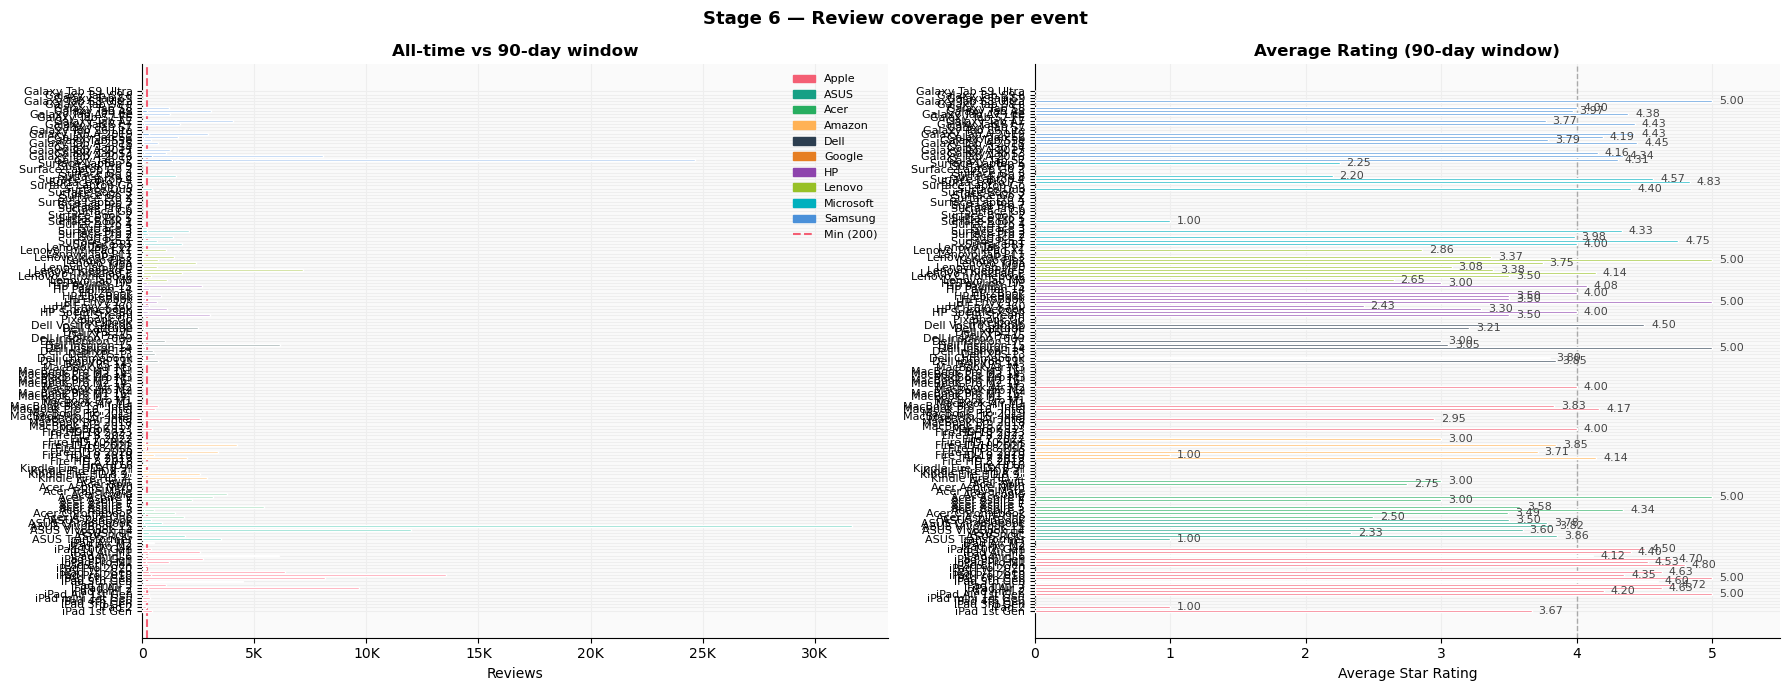

In [102]:
if not summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Stage 6 — Review coverage per event',
                 fontweight='bold', fontsize=13)
    order      = summary_df.sort_values(['type','brand','launch']).reset_index(drop=True)
    bar_colors = [BRAND_COLOR.get(r['brand'], '#888') for _, r in order.iterrows()]
    lt_colors  = [BRAND_LIGHT.get(r['brand'], '#ccc') for _, r in order.iterrows()]
    y          = np.arange(len(order))

    ax = axes[0]
    ax.barh(y, order['alltime'], color=lt_colors,
            edgecolor='white', height=0.6, label='All-time', zorder=3)
    ax.barh(y, order['n90'], color=bar_colors,
            edgecolor='white', height=0.6, label='90-day window', zorder=4)
    ax.axvline(THRESHOLD, color=MED_PINK, linestyle='--', linewidth=1.5)
    ax.set_yticks(y)
    ax.set_yticklabels(order['model'], fontsize=8)
    ax.set_xlabel('Reviews')
    ax.set_title('All-time vs 90-day window', fontweight='bold')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x/1e3)}K' if x>=1000 else int(x)))
    patches = [mpatches.Patch(color=BRAND_COLOR.get(b,'#888'), label=b)
               for b in order['brand'].unique()]
    patches += [plt.Line2D([0],[0], color=MED_PINK, linestyle='--',
                            label=f'Min ({THRESHOLD})')]
    ax.legend(handles=patches, frameon=False, fontsize=8)

    ax = axes[1]
    ax.barh(y, order['avg_rating'].fillna(0), color=bar_colors,
            edgecolor='white', height=0.6, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(order['model'], fontsize=8)
    ax.set_xlabel('Average Star Rating')
    ax.set_title('Average Rating (90-day window)', fontweight='bold')
    ax.set_xlim(0, 5.5)
    ax.axvline(4.0, color='#aaa', linewidth=1, linestyle='--')
    for i, (_, row) in enumerate(order.iterrows()):
        v = row['avg_rating']
        if v == v:
            ax.text(v+0.05, i, f'{v:.2f}', va='center', fontsize=8, color='#444')
    plt.tight_layout()
    plt.savefig('stage6_electronics_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()


## Stage 7 — EDA

In [103]:
INCLUDE_MARGINAL  = True
valid_events      = set(inc['model'])
if INCLUDE_MARGINAL:
    valid_events |= set(mar['model'])
electronics_thesis = reviews_90d[reviews_90d['model'].isin(valid_events)].copy()
electronics_thesis['window_days'] = WINDOW_DAYS
print(f'electronics_thesis: {electronics_thesis.shape}')
print(f'Events: {sorted(electronics_thesis["model"].unique())}')


electronics_thesis: (5007, 13)
Events: ['ASUS VivoBook 15', 'Acer Chromebook', 'Fire 7 2019', 'Fire HD 10 2021', 'Fire HD 8 2020', 'Galaxy Tab A 2016', 'Galaxy Tab A 2019', 'Galaxy Tab A8', 'Galaxy Tab S2', 'Surface Pro 3', 'iPad 10th Gen', 'iPad 7th Gen', 'iPad 9th Gen', 'iPad Air 2', 'iPad Air M1', 'iPad Pro 2018', 'iPad Pro M1', 'iPad mini 6']


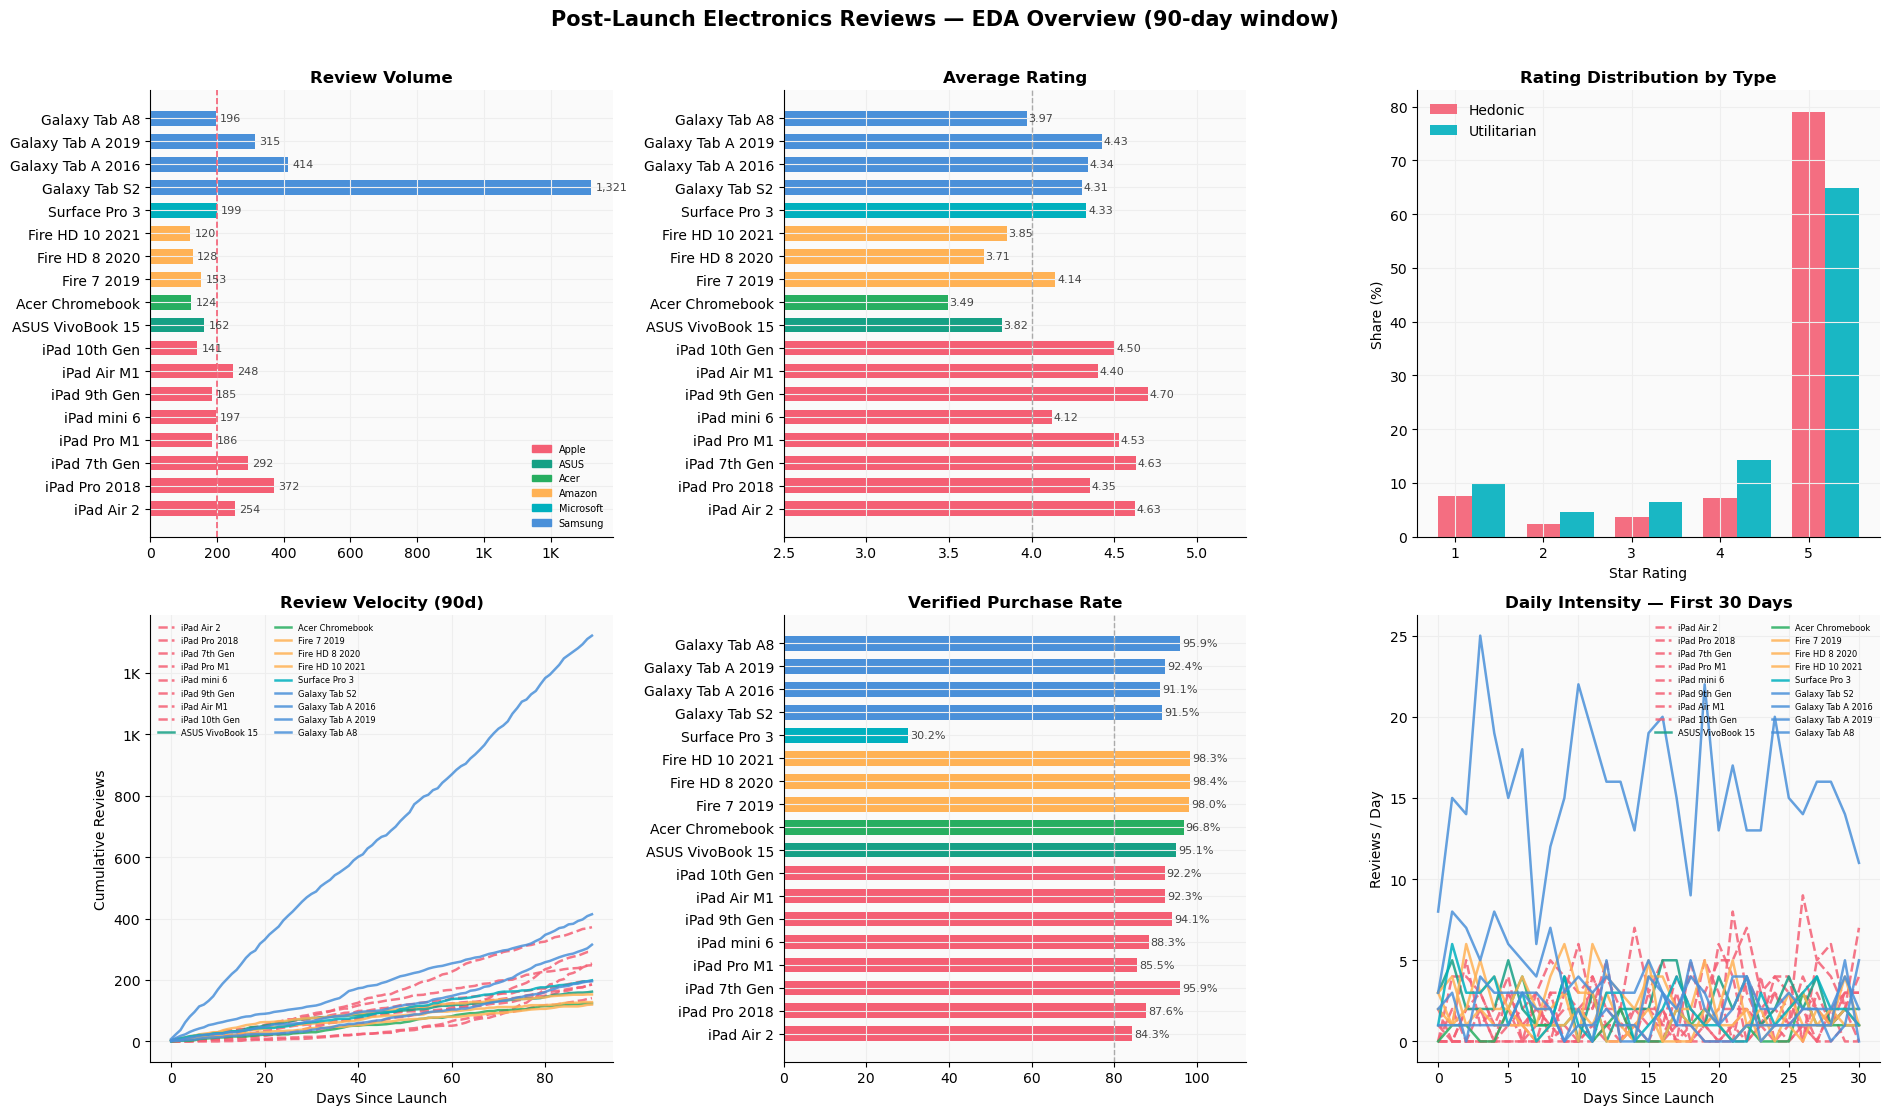

In [104]:
if not electronics_thesis.empty:
    MODEL_ORDER = sorted(
        electronics_thesis['model'].unique(),
        key=lambda m: (ELECTRONICS_EVENTS[m]['type'],
                       ELECTRONICS_EVENTS[m]['brand'],
                       ELECTRONICS_EVENTS[m]['launch'])
    )
    bcols = [BRAND_COLOR.get(ELECTRONICS_EVENTS[m]['brand'], '#888') for m in MODEL_ORDER]

    fig, axes = plt.subplots(2, 3, figsize=(19, 11))
    fig.suptitle('Post-Launch Electronics Reviews — EDA Overview (90-day window)',
                 fontsize=15, fontweight='bold', y=1.01)

    # 1. Volume
    ax  = axes[0,0]
    cnt = [len(electronics_thesis[electronics_thesis['model']==m]) for m in MODEL_ORDER]
    b   = ax.barh(MODEL_ORDER, cnt, color=bcols, edgecolor='none', height=0.65)
    for bar, v in zip(b, cnt):
        ax.text(v+max(cnt)*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8, color='#444')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x/1e3)}K' if x>=1000 else int(x)))
    ax.axvline(THRESHOLD, color=MED_PINK, linestyle='--', linewidth=1.2)
    ax.set_title('Review Volume', fontweight='bold')
    ax.legend(handles=[mpatches.Patch(color=BRAND_COLOR.get(b,'#888'), label=b)
                       for b in dict.fromkeys(ELECTRONICS_EVENTS[m]['brand']
                                              for m in MODEL_ORDER)],
              frameon=False, fontsize=7)

    # 2. Average rating
    ax   = axes[0,1]
    avgs = [electronics_thesis[electronics_thesis['model']==m]['rating'].mean()
            for m in MODEL_ORDER]
    b    = ax.barh(MODEL_ORDER, avgs, color=bcols, edgecolor='none', height=0.65)
    for bar, v in zip(b, avgs):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=8, color='#444')
    ax.set_xlim(2.5, 5.3)
    ax.axvline(4.0, color='#aaa', linewidth=1, linestyle='--')
    ax.set_title('Average Rating', fontweight='bold')

    # 3. Rating distribution by type
    ax = axes[0,2]
    for i, (ptype, color) in enumerate(TYPE_COLOR.items()):
        grp = electronics_thesis[electronics_thesis['type']==ptype]
        if grp.empty: continue
        vc  = grp['rating'].value_counts().sort_index()
        pct = vc / vc.sum() * 100
        ax.bar([r+i*0.38 for r in pct.index], pct.values, width=0.38,
               color=color, edgecolor='none', alpha=0.9, label=ptype.capitalize())
    ax.set_xlabel('Star Rating'); ax.set_ylabel('Share (%)')
    ax.set_title('Rating Distribution by Type', fontweight='bold')
    ax.set_xticks([1,2,3,4,5]); ax.legend(frameon=False)

    # 4. Cumulative velocity
    ax = axes[1,0]
    for model, color in zip(MODEL_ORDER, bcols):
        grp   = electronics_thesis[electronics_thesis['model']==model]
        daily = grp.groupby('days_since_launch').size()
        cumul = daily.reindex(range(WINDOW_DAYS+1), fill_value=0).cumsum()
        ls    = '--' if ELECTRONICS_EVENTS[model]['type']=='hedonic' else '-'
        ax.plot(cumul.index, cumul.values, color=color,
                linewidth=1.8, linestyle=ls, label=model, alpha=0.85)
    ax.set_xlabel('Days Since Launch'); ax.set_ylabel('Cumulative Reviews')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x/1e3)}K' if x>=1000 else int(x)))
    ax.set_title(f'Review Velocity ({WINDOW_DAYS}d)', fontweight='bold')
    ax.legend(frameon=False, fontsize=6, ncol=2)

    # 5. Verified purchase rate
    ax   = axes[1,1]
    vpct = [electronics_thesis[electronics_thesis['model']==m]['verified_purchase'].mean()*100
            for m in MODEL_ORDER]
    b    = ax.barh(MODEL_ORDER, vpct, color=bcols, edgecolor='none', height=0.65)
    for bar, v in zip(b, vpct):
        ax.text(v+0.5, bar.get_y()+bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=8, color='#444')
    ax.axvline(80, color='#aaa', linewidth=1, linestyle='--')
    ax.set_xlim(0, 112)
    ax.set_title('Verified Purchase Rate', fontweight='bold')

    # 6. First 30-day intensity
    ax = axes[1,2]
    for model, color in zip(MODEL_ORDER, bcols):
        grp   = electronics_thesis[electronics_thesis['model']==model]
        daily = (grp[grp['days_since_launch']<=30]
                 .groupby('days_since_launch').size()
                 .reindex(range(31), fill_value=0))
        ls    = '--' if ELECTRONICS_EVENTS[model]['type']=='hedonic' else '-'
        ax.plot(daily.index, daily.values, color=color,
                linewidth=1.8, linestyle=ls, label=model, alpha=0.85)
    ax.set_xlabel('Days Since Launch'); ax.set_ylabel('Reviews / Day')
    ax.set_title('Daily Intensity — First 30 Days', fontweight='bold')
    ax.legend(frameon=False, fontsize=6, ncol=2)

    plt.tight_layout()
    plt.savefig('electronics_eda_overview.png', dpi=150, bbox_inches='tight')
    plt.show()


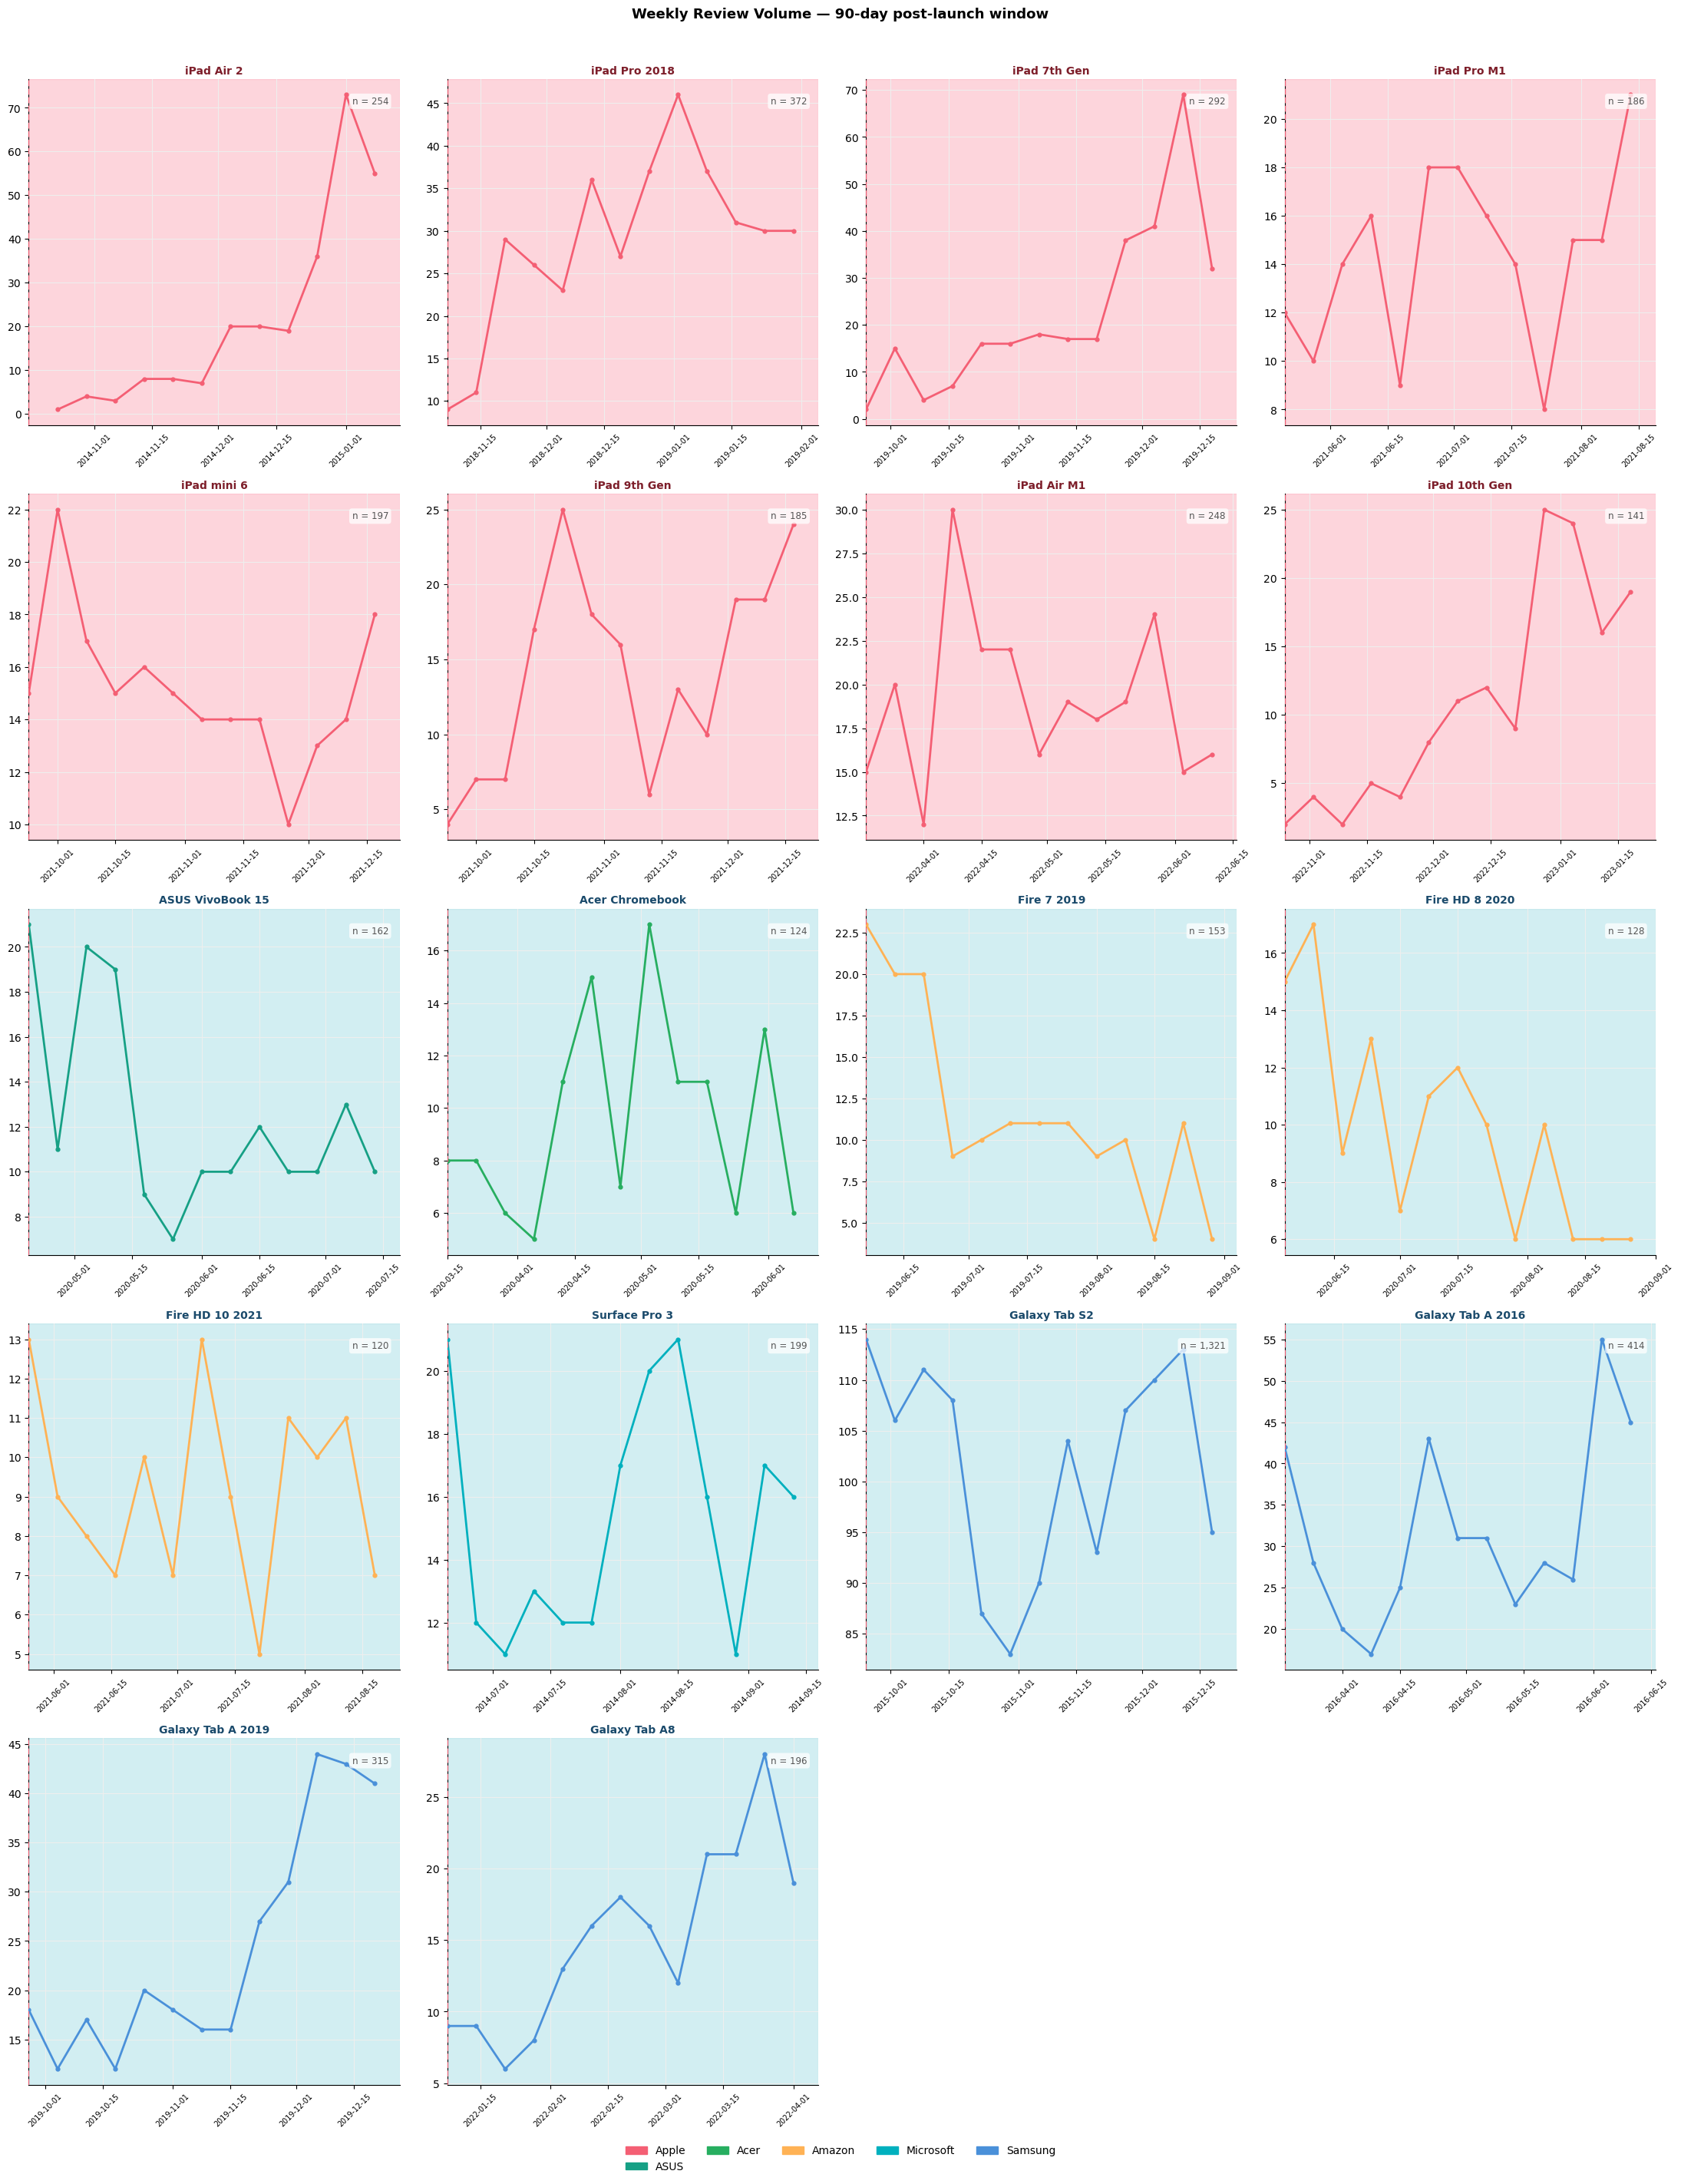

In [105]:
if not electronics_thesis.empty:
    ncols = 4
    nrows = int(np.ceil(len(MODEL_ORDER) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.5*nrows))
    fig.suptitle('Weekly Review Volume — 90-day post-launch window',
                 fontsize=13, fontweight='bold', y=1.01)
    flat = axes.flatten() if len(MODEL_ORDER)>1 else [axes]

    for idx, model in enumerate(MODEL_ORDER):
        ax     = flat[idx]
        meta   = ELECTRONICS_EVENTS[model]
        launch = pd.Timestamp(meta['launch'])
        w_end  = launch + pd.Timedelta(days=WINDOW_DAYS)
        color  = BRAND_COLOR.get(meta['brand'], '#888')
        ptype  = meta['type']
        grp    = electronics_thesis[electronics_thesis['model']==model].copy()
        grp['week']   = grp['days_since_launch'] // 7
        wkly          = grp.groupby('week').size().reset_index(name='reviews')
        wkly['wk_ts'] = launch + pd.to_timedelta(wkly['week']*7, unit='D')
        ax.set_facecolor(TYPE_BG[ptype])
        ax.axvspan(launch, w_end, color=TYPE_LIGHT[ptype], alpha=0.30, zorder=0)
        ax.plot(wkly['wk_ts'], wkly['reviews'], color=color,
                linewidth=2.0, marker='o', markersize=3.5, zorder=3)
        ax.axvline(launch, color=MED_PINK, linewidth=1.5, linestyle='--', zorder=4)
        ax.set_xlim(launch, w_end)
        ax.set_title(model, fontweight='bold', fontsize=10,
                     color=TYPE_TITLE[ptype], pad=5)
        ax.tick_params(axis='x', labelsize=7, rotation=45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.annotate(f'n = {len(grp):,}', xy=(0.97,0.95), xycoords='axes fraction',
                    ha='right', va='top', fontsize=8.5, color='#555',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75, ec='none'))
    for i in range(len(MODEL_ORDER), len(flat)):
        flat[i].set_visible(False)
    fig.legend(
        handles=[mpatches.Patch(color=BRAND_COLOR.get(b,'#888'), label=b)
                 for b in dict.fromkeys(ELECTRONICS_EVENTS[m]['brand']
                                        for m in MODEL_ORDER)],
        loc='lower center', ncol=5, frameon=False,
        fontsize=10, bbox_to_anchor=(0.5, -0.02)
    )
    plt.tight_layout()
    plt.savefig('electronics_weekly_volume.png', dpi=150, bbox_inches='tight')
    plt.show()


## Stage 8 — Export to GCS + BigQuery

In [106]:
import google.auth
from google.cloud import storage, bigquery
import io

PROJECT_ID = 'vuthesis-llm-buzz'
BUCKET     = 'thesis-bucket-vua'
BQ_DATASET = 'thesis_data'
BQ_TABLE   = 'electronics_reviews'
GCS_BLOB   = 'amazon_reviews/electronics_thesis.parquet'

creds, _   = google.auth.default(
    scopes=['https://www.googleapis.com/auth/cloud-platform']
)

expected = {'rating','text','asin','parent_asin','timestamp','helpful_vote',
            'verified_purchase','model','type','brand','launch',
            'days_since_launch','window_days'}
missing  = expected - set(electronics_thesis.columns)
print(f'Missing columns : {missing or "none"}')
print(f'Shape           : {electronics_thesis.shape}')
if not electronics_thesis.empty:
    print(f'Date range      : {electronics_thesis["timestamp"].min().date()} -> '
          f'{electronics_thesis["timestamp"].max().date()}')

# GCS upload
print('\nUploading to GCS...')
buffer = io.BytesIO()
electronics_thesis.to_parquet(buffer, index=False)
buffer.seek(0)
gcs_client = storage.Client(project=PROJECT_ID, credentials=creds)
blob       = gcs_client.bucket(BUCKET).blob(GCS_BLOB)
blob.upload_from_file(buffer, content_type='application/octet-stream')
gcs_uri    = f'gs://{BUCKET}/{GCS_BLOB}'
print(f'Uploaded  : {gcs_uri}')
print(f'Size      : {blob.size/1e6:.1f} MB')

# BigQuery load
print('\nLoading into BigQuery...')
bq_client  = bigquery.Client(project=PROJECT_ID, credentials=creds)
table_ref  = f'{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}'
bq_client.create_dataset(
    bigquery.Dataset(f'{PROJECT_ID}.{BQ_DATASET}'),
    exists_ok=True
)
job_config = bigquery.LoadJobConfig(
    source_format     = bigquery.SourceFormat.PARQUET,
    write_disposition = bigquery.WriteDisposition.WRITE_TRUNCATE,
    autodetect        = True,
)
load_job = bq_client.load_table_from_uri(gcs_uri, table_ref, job_config=job_config)
load_job.result()
table = bq_client.get_table(table_ref)
print(f'BigQuery table : {table_ref}')
print(f'Rows loaded    : {table.num_rows:,}')

# Smoke test
result = bq_client.query(f"""
    SELECT model, type, brand, COUNT(*) AS n_reviews, ROUND(AVG(rating),2) AS avg_rating
    FROM `{table_ref}`
    GROUP BY model, type, brand
    ORDER BY n_reviews DESC
""").to_dataframe()
print('\nBigQuery smoke test:')
print(result.to_string(index=False))


Missing columns : none
Shape           : (5007, 13)
Date range      : 2014-06-20 -> 2023-01-24

Uploading to GCS...
Uploaded  : gs://thesis-bucket-vua/amazon_reviews/electronics_thesis.parquet
Size      : 0.9 MB

Loading into BigQuery...
BigQuery table : vuthesis-llm-buzz.thesis_data.electronics_reviews
Rows loaded    : 5,007

BigQuery smoke test:
            model        type     brand  n_reviews  avg_rating
    Galaxy Tab S2 utilitarian   Samsung       1321        4.31
Galaxy Tab A 2016 utilitarian   Samsung        414        4.34
    iPad Pro 2018     hedonic     Apple        372        4.35
Galaxy Tab A 2019 utilitarian   Samsung        315        4.43
     iPad 7th Gen     hedonic     Apple        292        4.63
       iPad Air 2     hedonic     Apple        254        4.63
      iPad Air M1     hedonic     Apple        248        4.40
    Surface Pro 3 utilitarian Microsoft        199        4.33
      iPad mini 6     hedonic     Apple        197        4.12
    Galaxy Tab A8 ut

c:\Users\User\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [107]:
import pandas as pd
from google.cloud import bigquery
import google.auth

creds, _ = google.auth.default(scopes=['https://www.googleapis.com/auth/cloud-platform'])
bq = bigquery.Client(project='vuthesis-llm-buzz', credentials=creds)

result = bq.query("""
    SELECT model, type, brand, COUNT(*) AS n_reviews
    FROM `vuthesis-llm-buzz.thesis_data.electronics_reviews`
    GROUP BY model, type, brand
    UNION ALL
    SELECT model, type, brand, COUNT(*) AS n_reviews
    FROM `vuthesis-llm-buzz.thesis_data.phones_reviews`
    GROUP BY model, type, brand
    ORDER BY n_reviews DESC
""").to_dataframe()

print(result.to_string(index=False))

                   model        type     brand  n_reviews
           Galaxy Tab S2 utilitarian   Samsung       1321
       Galaxy Tab A 2016 utilitarian   Samsung        414
          Moto G 4th Gen utilitarian  Motorola        402
           iPad Pro 2018     hedonic     Apple        372
          Moto G 3rd Gen utilitarian  Motorola        366
         Google Pixel 4a utilitarian    Google        337
       Galaxy Tab A 2019 utilitarian   Samsung        315
            iPad 7th Gen     hedonic     Apple        292
Samsung Galaxy S22 Ultra     hedonic   Samsung        283
         Google Pixel 3a utilitarian    Google        264
              iPad Air 2     hedonic     Apple        254
             iPad Air M1     hedonic     Apple        248
   Samsung Galaxy S20 FE     hedonic   Samsung        240
       Samsung Galaxy S6     hedonic   Samsung        236
                   LG G3     hedonic        LG        224
             Moto G Fast utilitarian  Motorola        223
Samsung Galaxy

c:\Users\User\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [108]:
result = bq.query("""
    WITH combined AS (
        SELECT model, type, brand, days_since_launch
        FROM `vuthesis-llm-buzz.thesis_data.electronics_reviews`
        UNION ALL
        SELECT model, type, brand, days_since_launch
        FROM `vuthesis-llm-buzz.thesis_data.phones_reviews`
    )
    SELECT
        model,
        brand,
        type,
        COUNT(*) AS total_reviews,
        COUNTIF(days_since_launch BETWEEN 1 AND 90) AS reviews_90d_window,
        ROUND(100 * COUNTIF(days_since_launch BETWEEN 1 AND 90) / COUNT(*), 1)
            AS pct_in_window
    FROM combined
    GROUP BY model, brand, type
    ORDER BY reviews_90d_window DESC
""").to_dataframe()

print(result.to_string(index=False))

                   model     brand        type  total_reviews  reviews_90d_window  pct_in_window
           Galaxy Tab S2   Samsung utilitarian           1321                1313           99.4
       Galaxy Tab A 2016   Samsung utilitarian            414                 411           99.3
          Moto G 4th Gen  Motorola utilitarian            402                 402          100.0
           iPad Pro 2018     Apple     hedonic            372                 371           99.7
          Moto G 3rd Gen  Motorola utilitarian            366                 365           99.7
         Google Pixel 4a    Google utilitarian            337                 334           99.1
       Galaxy Tab A 2019   Samsung utilitarian            315                 313           99.4
            iPad 7th Gen     Apple     hedonic            292                 292          100.0
Samsung Galaxy S22 Ultra   Samsung     hedonic            283                 280           98.9
         Google Pixel 3a    Go

c:\Users\User\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
